In [1]:
# CELL 1: Install packages + verify internet
import importlib, subprocess, sys, urllib.request

try:
    urllib.request.urlopen("https://pypi.org", timeout=5)
    print("✅ Internet ON")
except:
    raise RuntimeError("❌ Internet OFF — Settings → Internet → ON → restart")

PKGS = {
    "torch":"torch","torchvision":"torchvision","timm":"timm","thop":"thop",
    "sklearn":"scikit-learn","pandas":"pandas","matplotlib":"matplotlib",
    "seaborn":"seaborn","scipy":"scipy","PIL":"Pillow","numpy":"numpy",
}
missing = []
for imp,pkg in PKGS.items():
    try: importlib.import_module(imp); print(f"  ✔  {pkg}")
    except ImportError: missing.append(pkg); print(f"  ✘  {pkg}")

if missing:
    for pkg in missing:
        r = subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"],
                           capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(f"Failed: {pkg}\n{r.stderr[:200]}")
        print(f"  ✔  {pkg} installed")
print("\n✅ All packages ready")


✅ Internet ON
  ✔  torch
  ✔  torchvision
  ✔  timm
  ✘  thop
  ✔  scikit-learn
  ✔  pandas
  ✔  matplotlib
  ✔  seaborn
  ✔  scipy
  ✔  Pillow
  ✔  numpy
  ✔  thop installed

✅ All packages ready


In [2]:
# CELL 2: GPU + Dataset check
import torch, os
print("="*55)
print(f"  PyTorch : {torch.__version__}")
print(f"  CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  ⚠️  No GPU — Settings → Accelerator → P100 or T4")

DATA_ROOT = "/kaggle/input/datasets/rishabhsinghego/dataset/train_data"
if os.path.exists(DATA_ROOT):
    contents = [x for x in os.listdir(DATA_ROOT)
                if os.path.isdir(os.path.join(DATA_ROOT,x))]
    print(f"\n  Dataset : {DATA_ROOT}")
    print(f"  Classes : {len(contents)} folders — {sorted(contents)[:5]}")
else:
    print(f"\n  ❌ NOT FOUND: {DATA_ROOT}")
    raise RuntimeError("Dataset not found")
print("="*55)


  PyTorch : 2.9.0+cu126
  CUDA    : True
  GPU     : Tesla P100-PCIE-16GB
  VRAM    : 17.1 GB

  Dataset : /kaggle/input/datasets/rishabhsinghego/dataset/train_data
  Classes : 30 folders — ['Airport', 'BareLand', 'BaseballField', 'Beach', 'Bridge']


In [3]:
# CELL 3: CONFIG
import os

EXTRACT_DIR = "/kaggle/input/datasets/rishabhsinghego/dataset/train_data"
OUTPUT_DIR  = "/kaggle/working/results"

SEED            = 42
BATCH_SIZE      = 64
FULL_EPOCHS     = 30   # early stopping will cut this short automatically
FEW_SHOT_EPOCHS = 20   # early stopping will cut this short automatically
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
IMG_SIZE        = 224
NUM_CLASSES     = 30
TRAIN_VAL_SPLIT = 0.8
NUM_WORKERS     = 0
PIN_MEM         = False

MODELS = ["resnet50", "efficientnet_b0", "densenet121"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Config ready")
print(f"   EXTRACT_DIR = {EXTRACT_DIR}")
print(f"   OUTPUT_DIR  = {OUTPUT_DIR}")
print(f"   MODELS      = {MODELS}")
print(f"   EPOCHS      = full={FULL_EPOCHS} few-shot={FEW_SHOT_EPOCHS}")
print(f"   Early stopping: patience=5, min_delta=0.001")


✅ Config ready
   EXTRACT_DIR = /kaggle/input/datasets/rishabhsinghego/dataset/train_data
   OUTPUT_DIR  = /kaggle/working/results
   MODELS      = ['resnet50', 'efficientnet_b0', 'densenet121']
   EPOCHS      = full=30 few-shot=20
   Early stopping: patience=5, min_delta=0.001


In [4]:
# CELL 4: Imports + Device + Logger
import zipfile, random, warnings, time, logging, sys
from pathlib import Path
from copy import deepcopy
from collections import defaultdict, OrderedDict

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import timm
from thop import profile as thop_profile

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from scipy.ndimage import uniform_filter1d
from IPython.display import Image, display, HTML

warnings.filterwarnings("ignore")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda"); PIN_MEM = False
    print(f"✅ CUDA — {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps"); PIN_MEM = False
    print("✅ Apple MPS")
else:
    DEVICE = torch.device("cpu"); PIN_MEM = False
    print("⚠️  CPU only")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
_log = logging.getLogger("GNR638")
_log.setLevel(logging.DEBUG); _log.handlers.clear()
_ch = logging.StreamHandler(sys.stdout)
_ch.setFormatter(logging.Formatter("%(message)s"))
_fh = logging.FileHandler(str(Path(OUTPUT_DIR)/"run_log.txt"),
                          mode="w", encoding="utf-8")
_fh.setFormatter(logging.Formatter("[%(asctime)s] %(message)s",
                                    datefmt="%H:%M:%S"))
_log.addHandler(_ch); _log.addHandler(_fh)

def L(msg=""): _log.info(str(msg))
def section(t): L(f"\n{'='*65}\n  {t}\n{'='*65}")
def done(lbl,t): L(f"  ✔  {lbl} — {t/60:.1f} min")

def show_table(df, title=""):
    if title: L(f"\n  {title}")
    L(df.to_string(index=False))
    display(HTML(f"<h4>{title}</h4>" + df.to_html(index=False)))

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    display(Image(path))

print(f"✅ Logger → {Path(OUTPUT_DIR)/'run_log.txt'}")


✅ CUDA — Tesla P100-PCIE-16GB
✅ Logger → /kaggle/working/results/run_log.txt


In [5]:
# CELL 5: All Utilities (with Early Stopping)
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(SEED)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2),
    T.ToTensor(), T.Normalize(MEAN,STD),
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(), T.Normalize(MEAN,STD),
])

class GaussianNoiseTF:
    def __init__(self,s): self.s=s
    def __call__(self,x):
        return torch.clamp(x+torch.randn_like(x)*self.s,0.,1.)

class MotionBlurTF:
    def __init__(self,sz=15): self.sz=sz
    def __call__(self,x):
        return torch.from_numpy(
            uniform_filter1d(x.numpy(),size=self.sz,axis=2).copy())

def corruption_tf(kind, sev=None):
    base=[T.Resize((IMG_SIZE,IMG_SIZE)),T.ToTensor()]
    norm=[T.Normalize(MEAN,STD)]
    if kind=="gaussian_noise": return T.Compose(base+[GaussianNoiseTF(sev)]+norm)
    if kind=="motion_blur":    return T.Compose(base+[MotionBlurTF(15)]+norm)
    if kind=="brightness":
        return T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)),
                          T.ColorJitter(brightness=(sev,sev)),
                          T.ToTensor()]+norm)
    raise ValueError(kind)

def find_data_root(base):
    for p in sorted([Path(base)]+list(Path(base).rglob("*")),
                    key=lambda x:len(x.parts)):
        if p.is_dir():
            sd=[x for x in p.iterdir() if x.is_dir()]
            if len(sd)>=25:
                L(f"  Data root: {p}  ({len(sd)} classes)")
                return str(p)
    raise RuntimeError(f"Cannot find 30 class folders under {base}")

def make_splits(data_root):
    ds=ImageFolder(data_root); idx=list(range(len(ds)))
    random.Random(SEED).shuffle(idx); sp=int(TRAIN_VAL_SPLIT*len(idx))
    L(f"  Split: {len(ds)} total → {sp} train / {len(idx)-sp} val")
    return idx[:sp], idx[sp:]

def get_loaders(data_root, train_idx, val_idx,
                subset_frac=1.0, val_transform=None):
    vt=val_transform or val_tf
    tds=ImageFolder(data_root,transform=train_tf)
    vds=ImageFolder(data_root,transform=vt)
    tidx=train_idx
    if subset_frac<1.0:
        tidx=train_idx[:max(NUM_CLASSES,int(len(train_idx)*subset_frac))]
    tl=DataLoader(Subset(tds,tidx),batch_size=BATCH_SIZE,shuffle=True,
                  num_workers=NUM_WORKERS,pin_memory=PIN_MEM)
    vl=DataLoader(Subset(vds,val_idx),batch_size=BATCH_SIZE,shuffle=False,
                  num_workers=NUM_WORKERS,pin_memory=PIN_MEM)
    return tl,vl

HEAD_KW=("classifier","fc","head")
COLORS =["steelblue","darkorange","forestgreen"]
def is_head(n): return any(k in n for k in HEAD_KW)

def build_model(mname, strategy):
    model=timm.create_model(mname,pretrained=True,num_classes=NUM_CLASSES)
    if strategy=="linear_probe":
        for n,p in model.named_parameters(): p.requires_grad=is_head(n)
    elif strategy=="last_block":
        for p in model.parameters(): p.requires_grad=False
        if hasattr(model,"layer4"):
            for p in model.layer4.parameters(): p.requires_grad=True
        elif hasattr(model,"features") and hasattr(model.features,"denseblock4"):
            for p in model.features.denseblock4.parameters(): p.requires_grad=True
            for p in model.features.norm5.parameters(): p.requires_grad=True
        elif hasattr(model,"blocks"):
            for p in model.blocks[-1].parameters(): p.requires_grad=True
        for n,p in model.named_parameters():
            if is_head(n): p.requires_grad=True
    elif strategy=="full":
        for p in model.parameters(): p.requires_grad=True
    elif strategy=="selective":
        for p in model.parameters(): p.requires_grad=False
        backbone=[(n,p) for n,p in model.named_parameters() if not is_head(n)]
        target=int(0.20*sum(p.numel() for _,p in backbone))
        unfrozen=0
        for n,p in reversed(backbone):
            if unfrozen>=target: break
            p.requires_grad=True; unfrozen+=p.numel()
        for n,p in model.named_parameters():
            if is_head(n): p.requires_grad=True
    return model.to(DEVICE)

def param_stats(model):
    total=sum(p.numel() for p in model.parameters())
    train=sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total,train

def compute_macs(model):
    try:
        macs,_=thop_profile(deepcopy(model).cpu(),
                             inputs=(torch.randn(1,3,IMG_SIZE,IMG_SIZE),),
                             verbose=False)
        return int(macs)
    except: return 0

def print_efficiency(label, model):
    total,trainable=param_stats(model)
    macs=compute_macs(model)
    L(f"     Efficiency [{label}]")
    L(f"       Total params    : {total:,}")
    L(f"       Trainable params: {trainable:,} ({trainable/total*100:.1f}%)")
    L(f"       MACs            : {macs/1e9:.3f} G")
    L(f"       FLOPs (2xMACs)  : {macs*2/1e9:.3f} G")
    return total,trainable,macs

def train_epoch(model, loader, optimizer, criterion):
    model.train(); ls=correct=n=0
    for imgs,lbls in loader:
        imgs,lbls=imgs.to(DEVICE),lbls.to(DEVICE)
        optimizer.zero_grad(); out=model(imgs); loss=criterion(out,lbls)
        loss.backward(); optimizer.step()
        ls+=loss.item()*imgs.size(0)
        correct+=out.argmax(1).eq(lbls).sum().item(); n+=imgs.size(0)
    return ls/n, correct/n

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval(); ls=correct=n=0; pa,la=[],[]
    for imgs,lbls in loader:
        imgs,lbls=imgs.to(DEVICE),lbls.to(DEVICE)
        out=model(imgs); loss=criterion(out,lbls)
        ls+=loss.item()*imgs.size(0); p=out.argmax(1)
        correct+=p.eq(lbls).sum().item(); n+=imgs.size(0)
        pa.extend(p.cpu().tolist()); la.extend(lbls.cpu().tolist())
    return ls/n, correct/n, pa, la

# ── Early Stopping ────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience  = patience
        self.min_delta = min_delta
        self.best_val  = 0.0
        self.counter   = 0
        self.stop      = False

    def step(self, val_acc):
        if val_acc > self.best_val + self.min_delta:
            self.best_val = val_acc
            self.counter  = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def train_full(model, tl, vl, epochs, lr=LR, label=""):
    criterion=nn.CrossEntropyLoss()
    optimizer=optim.AdamW(
        filter(lambda p:p.requires_grad,model.parameters()),
        lr=lr,weight_decay=WEIGHT_DECAY)
    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs)
    history=dict(train_loss=[],val_loss=[],train_acc=[],val_acc=[])
    gnorms=[]; es=EarlyStopping(patience=5,min_delta=0.001)

    for ep in range(1,epochs+1):
        tl_l,ta=train_epoch(model,tl,optimizer,criterion)
        norms=[p.grad.norm().item() for p in model.parameters()
               if p.requires_grad and p.grad is not None]
        gnorms.append(float(np.mean(norms)) if norms else 0.)
        vl_l,va,_,_=eval_epoch(model,vl,criterion)
        scheduler.step()
        history["train_loss"].append(tl_l); history["val_loss"].append(vl_l)
        history["train_acc"].append(ta);    history["val_acc"].append(va)
        L(f"    {label:38s} ep{ep:02d}/{epochs} train={ta:.3f} val={va:.3f}")
        es.step(va)
        if es.stop:
            L(f"    ⚡ Early stop at ep{ep} (patience={es.patience})")
            break

    return history, gnorms

# ── Plot helpers ──────────────────────────────────────────
def plot_curves(histories, title, path):
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    for i,(name,h) in enumerate(histories.items()):
        c=COLORS[i%len(COLORS)]
        axes[0].plot(h["train_acc"],c=c,ls="-", label=f"{name} train")
        axes[0].plot(h["val_acc"],  c=c,ls="--",label=f"{name} val")
        axes[1].plot(h["train_loss"],c=c,ls="-", label=f"{name} train")
        axes[1].plot(h["val_loss"],  c=c,ls="--",label=f"{name} val")
    for ax,yl in zip(axes,["Accuracy","Loss"]):
        ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
        ax.set_title(f"{title} — {yl}"); ax.legend(fontsize=7); ax.grid(True)
    savefig(path)

def plot_confusion(labels, preds, classes, title, path):
    cm=confusion_matrix(labels,preds)
    plt.figure(figsize=(16,13))
    sns.heatmap(cm,annot=False,cmap="Blues",xticklabels=classes,
                yticklabels=classes,linewidths=0.3)
    plt.title(title,fontsize=11); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.xticks(fontsize=6,rotation=90); plt.yticks(fontsize=6)
    savefig(path)

def plot_tsne(feats, labels, title, path):
    n=min(50,feats.shape[1])
    f=PCA(n_components=n,random_state=SEED).fit_transform(feats)
    f=TSNE(n_components=2,random_state=SEED,
           perplexity=min(30,max(5,len(feats)//4)),
           n_iter=1000).fit_transform(f)
    plt.figure(figsize=(10,8))
    sc=plt.scatter(f[:,0],f[:,1],c=labels,cmap="tab20",alpha=0.6,s=8)
    plt.colorbar(sc,label="Class"); plt.title(title); savefig(path)

def plot_pca2d(feats, labels, title, path):
    f=PCA(n_components=2,random_state=SEED).fit_transform(feats)
    plt.figure(figsize=(8,6))
    sc=plt.scatter(f[:,0],f[:,1],c=labels,cmap="tab20",alpha=0.7,s=12)
    plt.colorbar(sc,label="Class"); plt.title(title); savefig(path)

def extract_penultimate(model, loader):
    store={}
    def _hook(mod,inp,out):
        f=out.detach().cpu()
        store["f"]=f.flatten(1) if f.dim()>2 else f
    h=model.global_pool.register_forward_hook(_hook)
    fs,ls=[],[]
    model.eval()
    with torch.no_grad():
        for imgs,lbls in loader:
            model(imgs.to(DEVICE)); fs.append(store["f"].numpy())
            ls.extend(lbls.tolist())
    h.remove()
    return np.vstack(fs), np.array(ls)

def get_layer_map(model, mname):
    if "resnet" in mname:
        return OrderedDict([("L1_early",model.layer1),("L2_mid",model.layer2),
                             ("L3_deep",model.layer3),("L4_final",model.layer4)])
    if "densenet" in mname:
        return OrderedDict([("DB1_early",model.features.denseblock1),
                             ("DB2_mid",  model.features.denseblock2),
                             ("DB3_deep", model.features.denseblock3),
                             ("DB4_final",model.features.denseblock4)])
    if "efficientnet" in mname:
        return OrderedDict([("B1_early",model.blocks[1]),("B3_mid",model.blocks[3]),
                             ("B5_deep",model.blocks[5]),("B6_final",model.blocks[6])])
    raise ValueError(mname)

CORRUPTIONS=[
    ("gaussian_noise",0.05,"GaussNoise_s0.05"),
    ("gaussian_noise",0.10,"GaussNoise_s0.10"),
    ("gaussian_noise",0.20,"GaussNoise_s0.20"),
    ("motion_blur",   None,"MotionBlur"),
    ("brightness",    2.0, "Brightness_x2"),
]

all_s1,all_s2,all_s3,all_s4,all_s5,all_bonus=[],[],[],[],[],[]
timings={}

print("✅ All utilities defined")
print("   ✔ Early stopping: patience=5, min_delta=0.001")
print("   ✔ selective: exact 20% backbone numel")
print("   ✔ pin_memory=False, NUM_WORKERS=0")


✅ All utilities defined
   ✔ Early stopping: patience=5, min_delta=0.001
   ✔ selective: exact 20% backbone numel
   ✔ pin_memory=False, NUM_WORKERS=0


In [6]:
# CELL 6: Data setup — run ONCE
data_root  = find_data_root(EXTRACT_DIR)
train_idx, val_idx = make_splits(data_root)
classes = ImageFolder(data_root).classes

full_ds=ImageFolder(data_root,transform=val_tf)
by_cls=defaultdict(list)
for i,(_,lbl) in enumerate(full_ds.samples): by_cls[lbl].append(i)
probe_idx    = [idx for c in range(NUM_CLASSES) for idx in by_cls[c][:30]]
probe_labels = np.array([full_ds.samples[i][1] for i in probe_idx])
probe_loader = DataLoader(Subset(full_ds,probe_idx),batch_size=32,
                           shuffle=False,num_workers=NUM_WORKERS)

print(f"✅ Data ready — {len(classes)} classes | "
      f"train={len(train_idx)} val={len(val_idx)} | "
      f"probe={len(probe_idx)}")


  Data root: /kaggle/input/datasets/rishabhsinghego/dataset/train_data  (30 classes)
  Split: 6993 total → 5594 train / 1399 val
✅ Data ready — 30 classes | train=5594 val=1399 | probe=900



  🔵  RESNET50 — starting

  S1 Linear Probe — resnet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

     Efficiency [resnet50/linear_probe]
       Total params    : 23,569,502
       Trainable params: 61,470 (0.3%)
       MACs            : 4.132 G
       FLOPs (2xMACs)  : 8.264 G
    resnet50/linear_probe                  ep01/30 train=0.445 val=0.661
    resnet50/linear_probe                  ep02/30 train=0.718 val=0.739
    resnet50/linear_probe                  ep03/30 train=0.759 val=0.795
    resnet50/linear_probe                  ep04/30 train=0.801 val=0.801
    resnet50/linear_probe                  ep05/30 train=0.817 val=0.806
    resnet50/linear_probe                  ep06/30 train=0.832 val=0.820
    resnet50/linear_probe                  ep07/30 train=0.834 val=0.817
    resnet50/linear_probe                  ep08/30 train=0.845 val=0.829
    resnet50/linear_probe                  ep09/30 train=0.853 val=0.827
    resnet50/linear_probe                  ep10/30 train=0.863 val=0.833
    resnet50/linear_probe                  ep11/30 train=0.864 val=0.847
    resnet50/lin

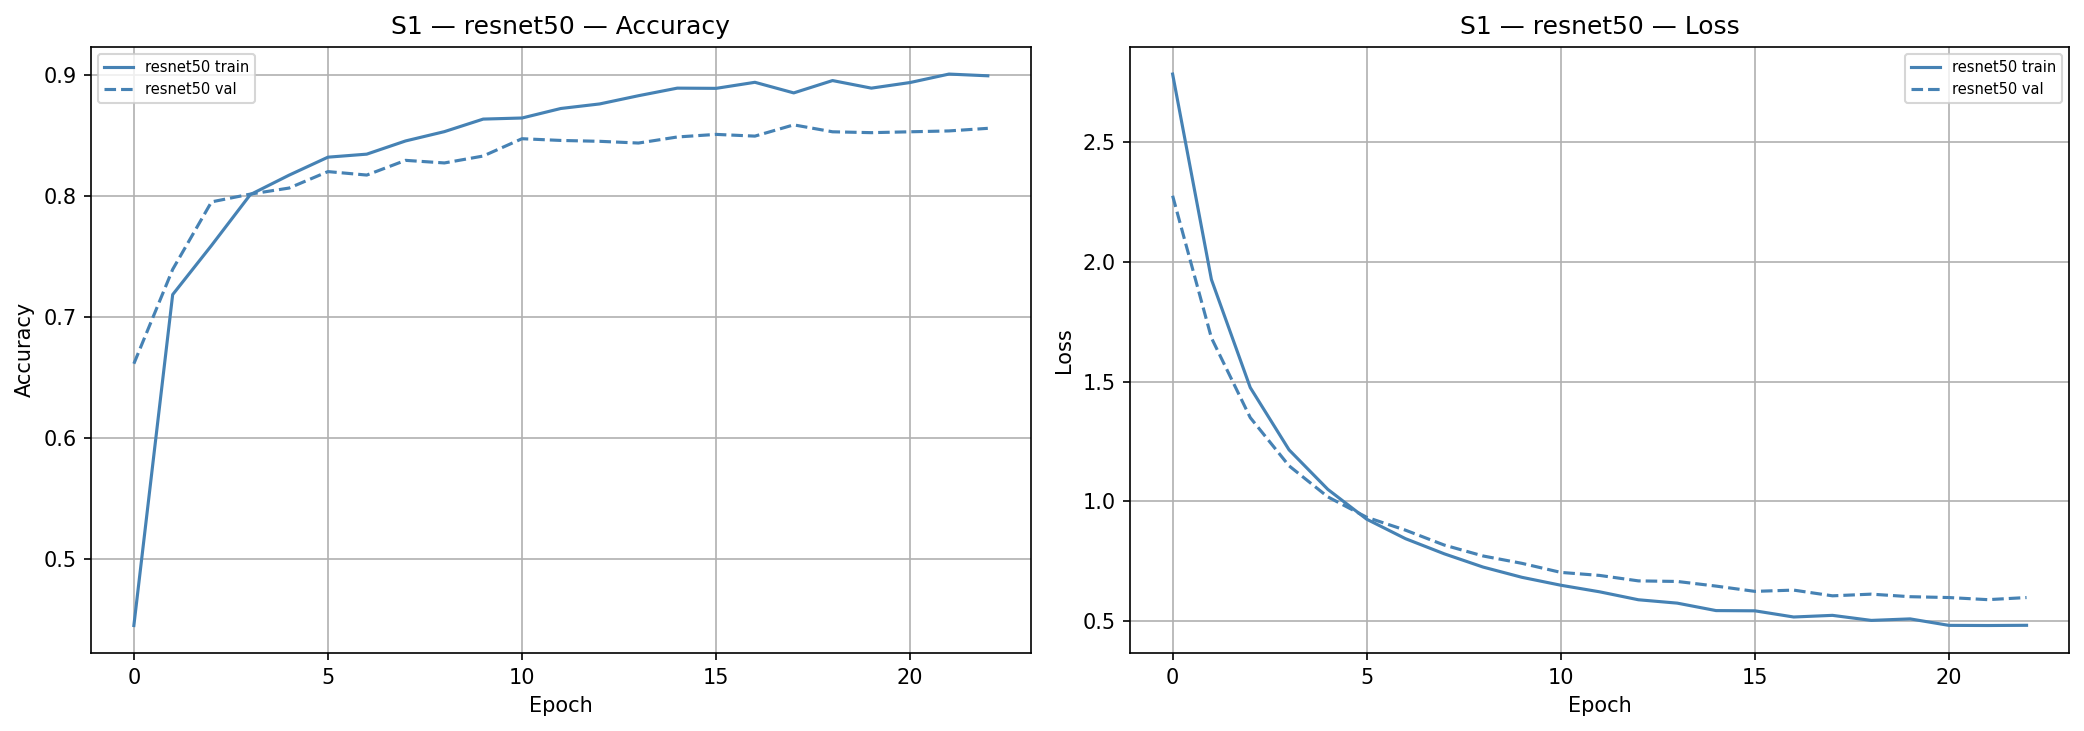

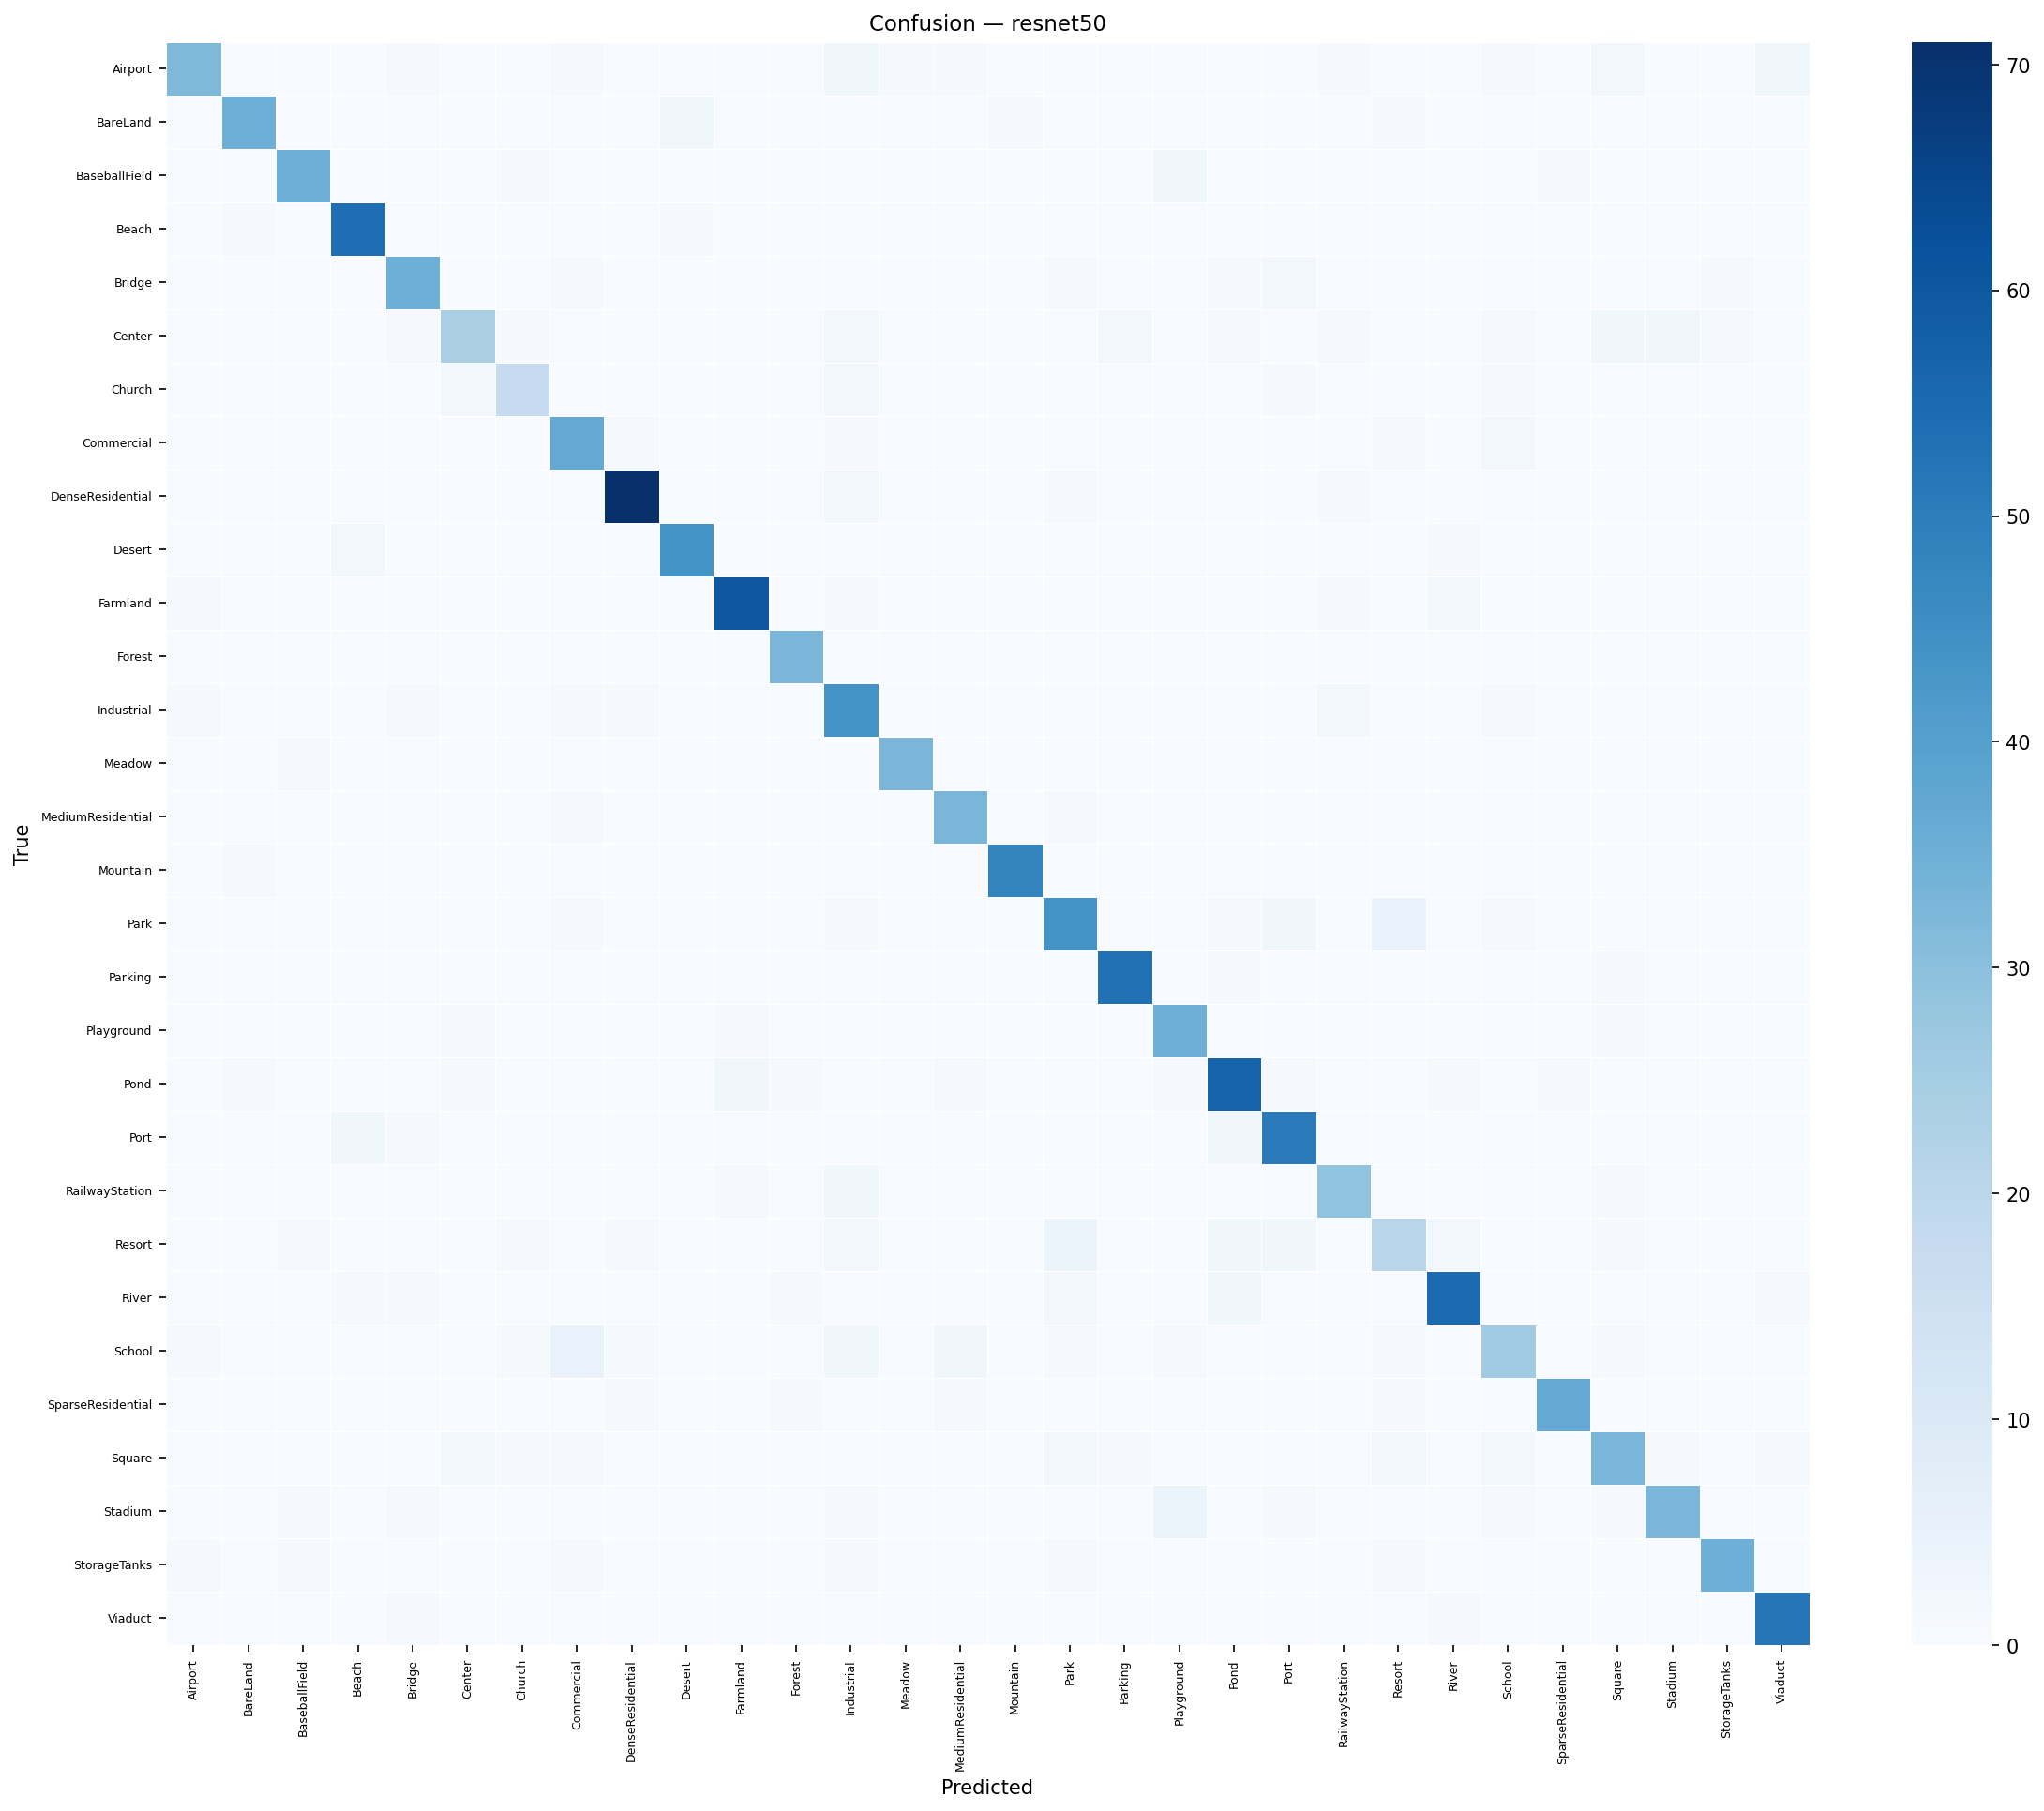

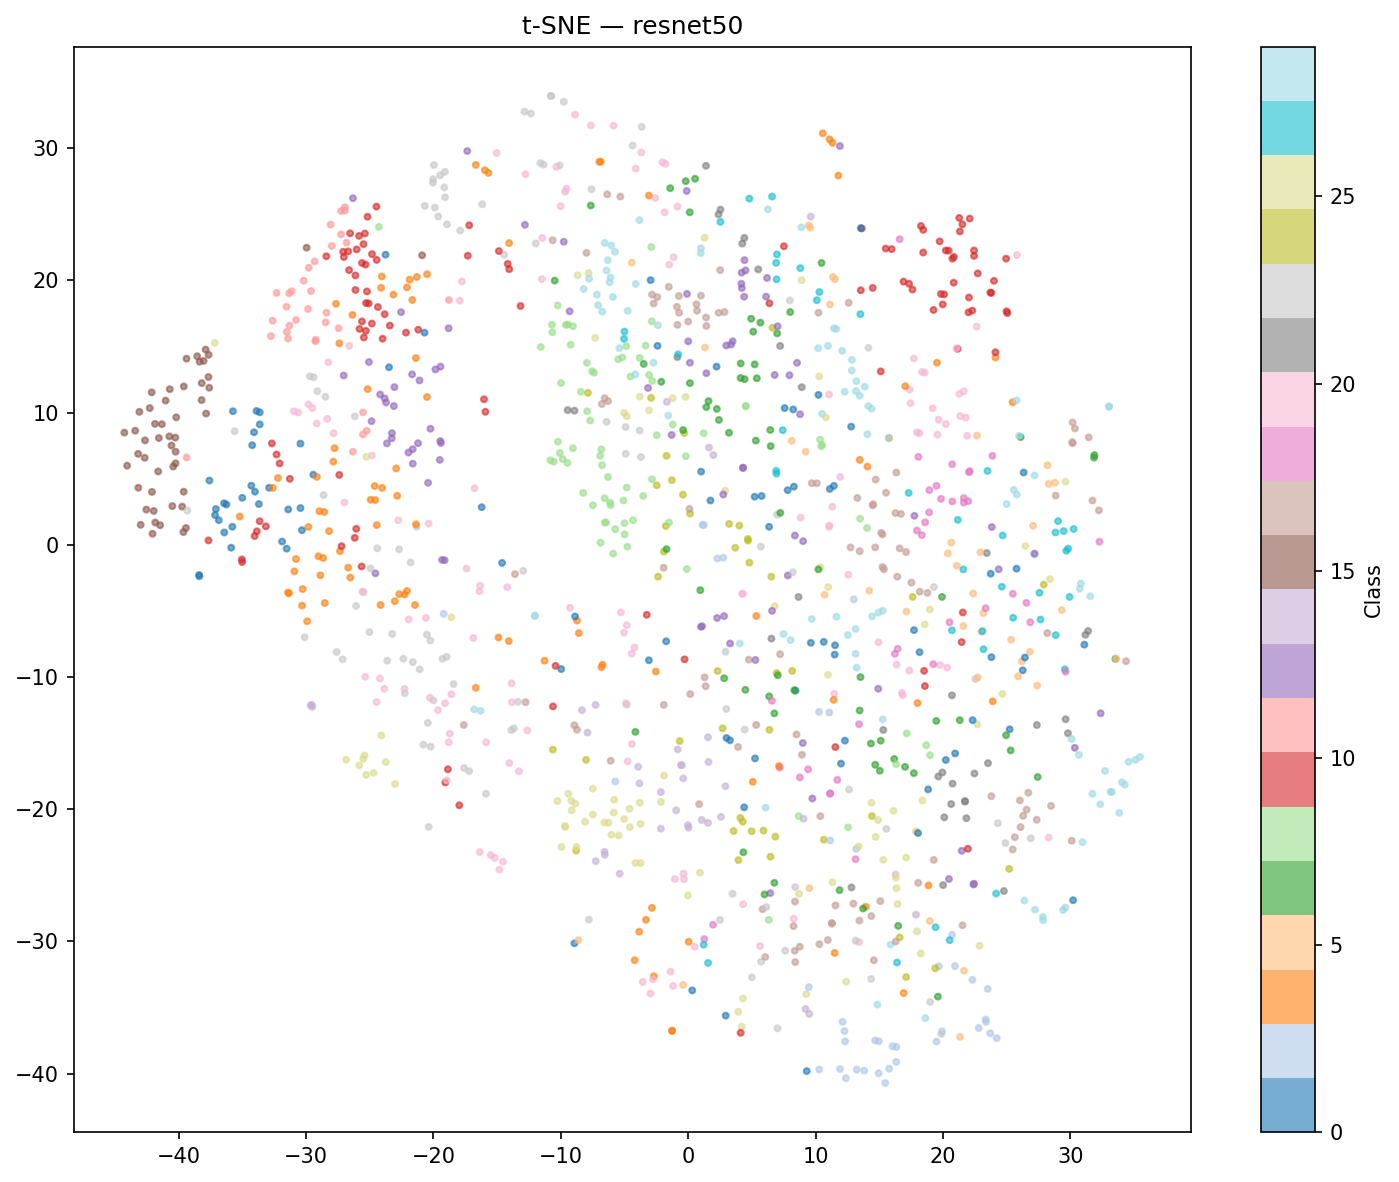

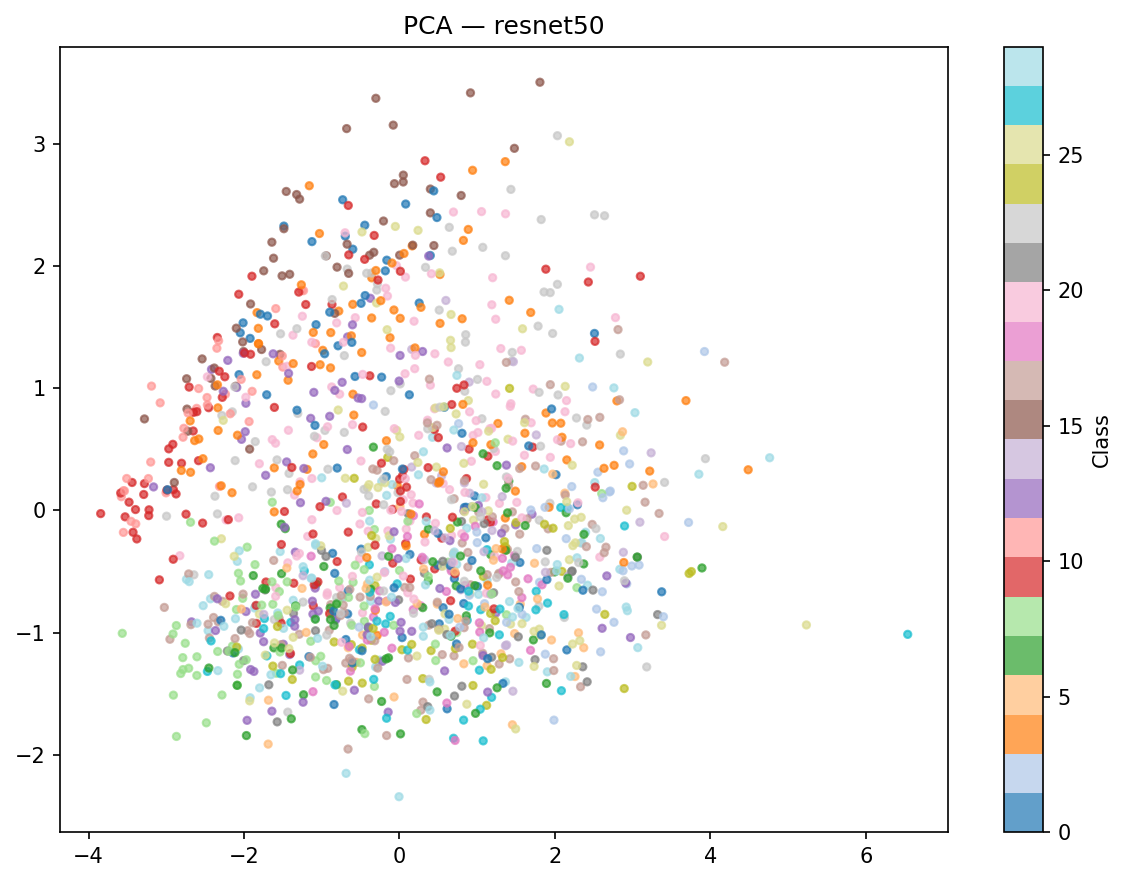


  S1 — resnet50
   model  val_acc  total_params  trainable_params  MACs_G  FLOPs_G
resnet50   0.8556      23569502             61470   4.132    8.264


model,val_acc,total_params,trainable_params,MACs_G,FLOPs_G
resnet50,0.8556,23569502,61470,4.132,8.264


  ✔  S1/resnet50 — 33.8 min

  S2 Fine-Tuning — resnet50
  linear_probe reused from S1 val=0.8556

  strategy=last_block
     Efficiency [resnet50/last_block]
       Total params    : 23,569,502
       Trainable params: 15,026,206 (63.8%)
       MACs            : 4.132 G
       FLOPs (2xMACs)  : 8.264 G
    resnet50/last_block                    ep01/30 train=0.614 val=0.880
    resnet50/last_block                    ep02/30 train=0.919 val=0.916
    resnet50/last_block                    ep03/30 train=0.954 val=0.933
    resnet50/last_block                    ep04/30 train=0.976 val=0.938
    resnet50/last_block                    ep05/30 train=0.984 val=0.942
    resnet50/last_block                    ep06/30 train=0.986 val=0.947
    resnet50/last_block                    ep07/30 train=0.990 val=0.939
    resnet50/last_block                    ep08/30 train=0.991 val=0.951
    resnet50/last_block                    ep09/30 train=0.992 val=0.948
    resnet50/last_block               

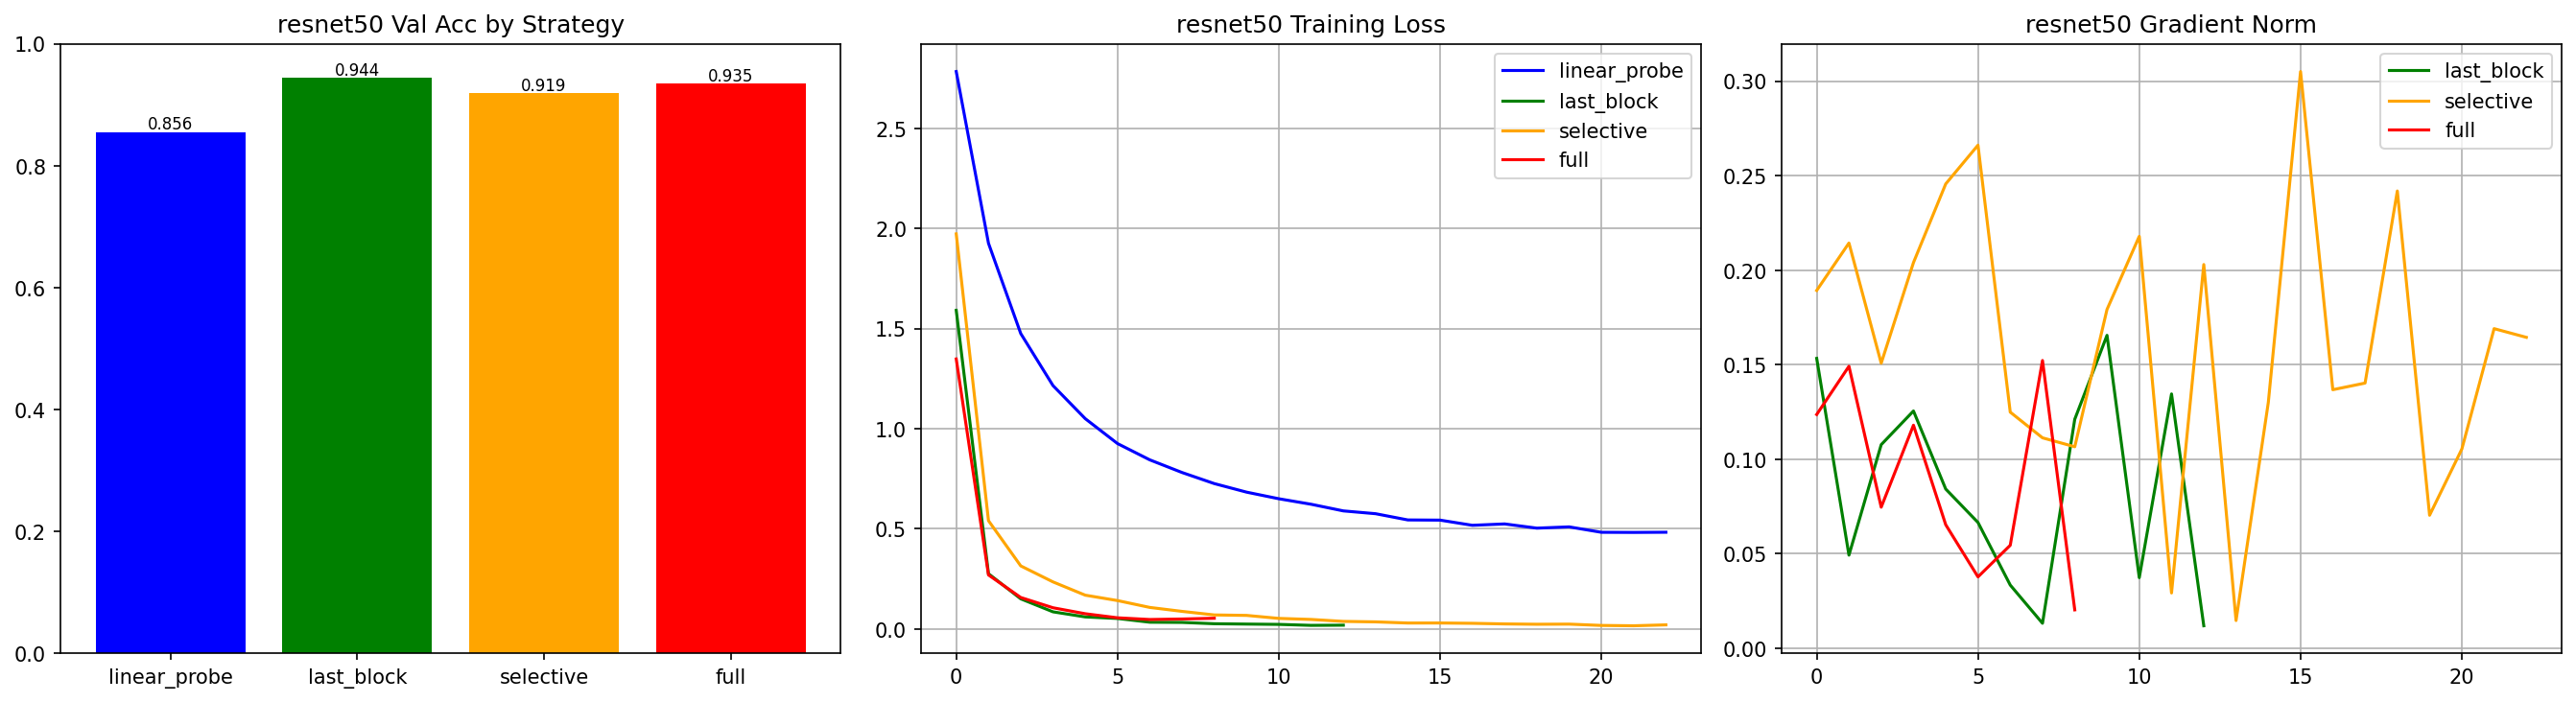

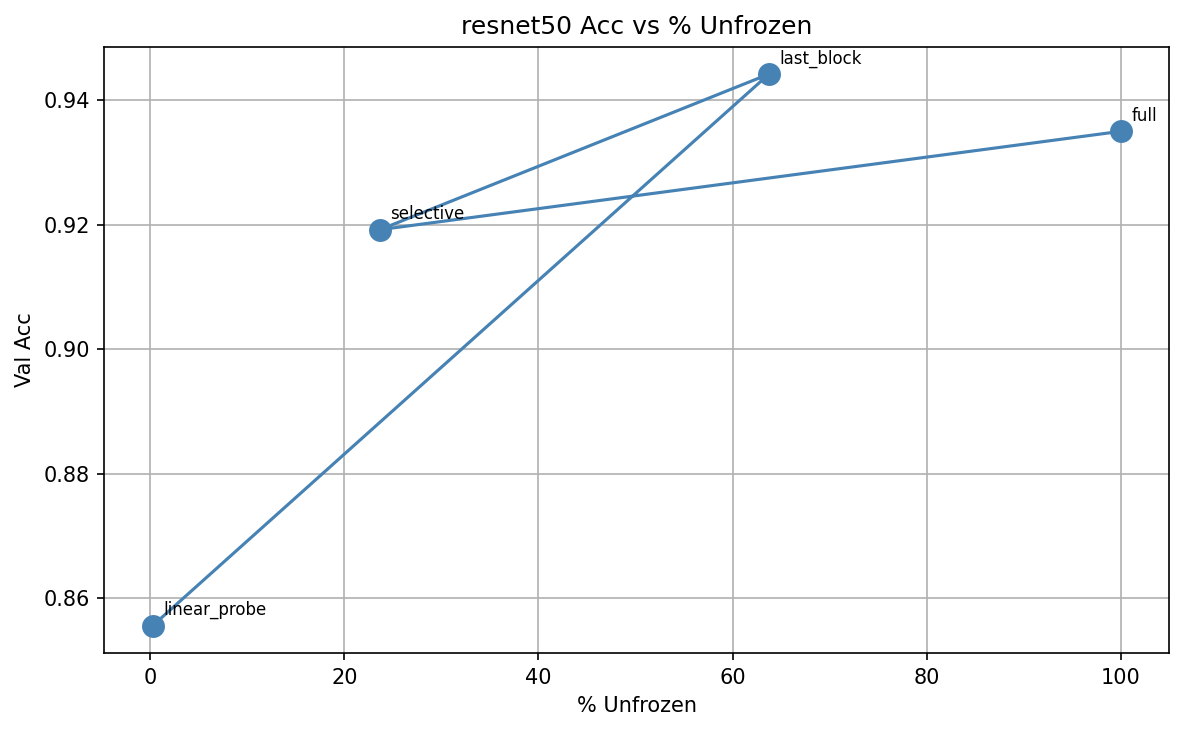


  S2 — resnet50
   model     strategy  val_acc  pct_unfrozen  trainable_params  MACs_G
resnet50 linear_probe   0.8556          0.26             61470   4.132
resnet50   last_block   0.9442         63.75          15026206   4.132
resnet50    selective   0.9192         23.66           5576734   4.132
resnet50         full   0.9350        100.00          23569502   4.132


model,strategy,val_acc,pct_unfrozen,trainable_params,MACs_G
resnet50,linear_probe,0.8556,0.26,61470,4.132
resnet50,last_block,0.9442,63.75,15026206,4.132
resnet50,selective,0.9192,23.66,5576734,4.132
resnet50,full,0.9350,100.00,23569502,4.132


  ✔  S2/resnet50 — 69.3 min

  S3 Few-Shot — resnet50
  100% reused from S2-full val=0.9350

  fraction=20%
    resnet50/20%                           ep01/20 train=0.215 val=0.265
    resnet50/20%                           ep02/20 train=0.623 val=0.655
    resnet50/20%                           ep03/20 train=0.851 val=0.826
    resnet50/20%                           ep04/20 train=0.928 val=0.810
    resnet50/20%                           ep05/20 train=0.970 val=0.856
    resnet50/20%                           ep06/20 train=0.969 val=0.863
    resnet50/20%                           ep07/20 train=0.977 val=0.871
    resnet50/20%                           ep08/20 train=0.987 val=0.866
    resnet50/20%                           ep09/20 train=0.991 val=0.882
    resnet50/20%                           ep10/20 train=0.990 val=0.883
    resnet50/20%                           ep11/20 train=0.996 val=0.904
    resnet50/20%                           ep12/20 train=0.994 val=0.906
    resnet50/20%

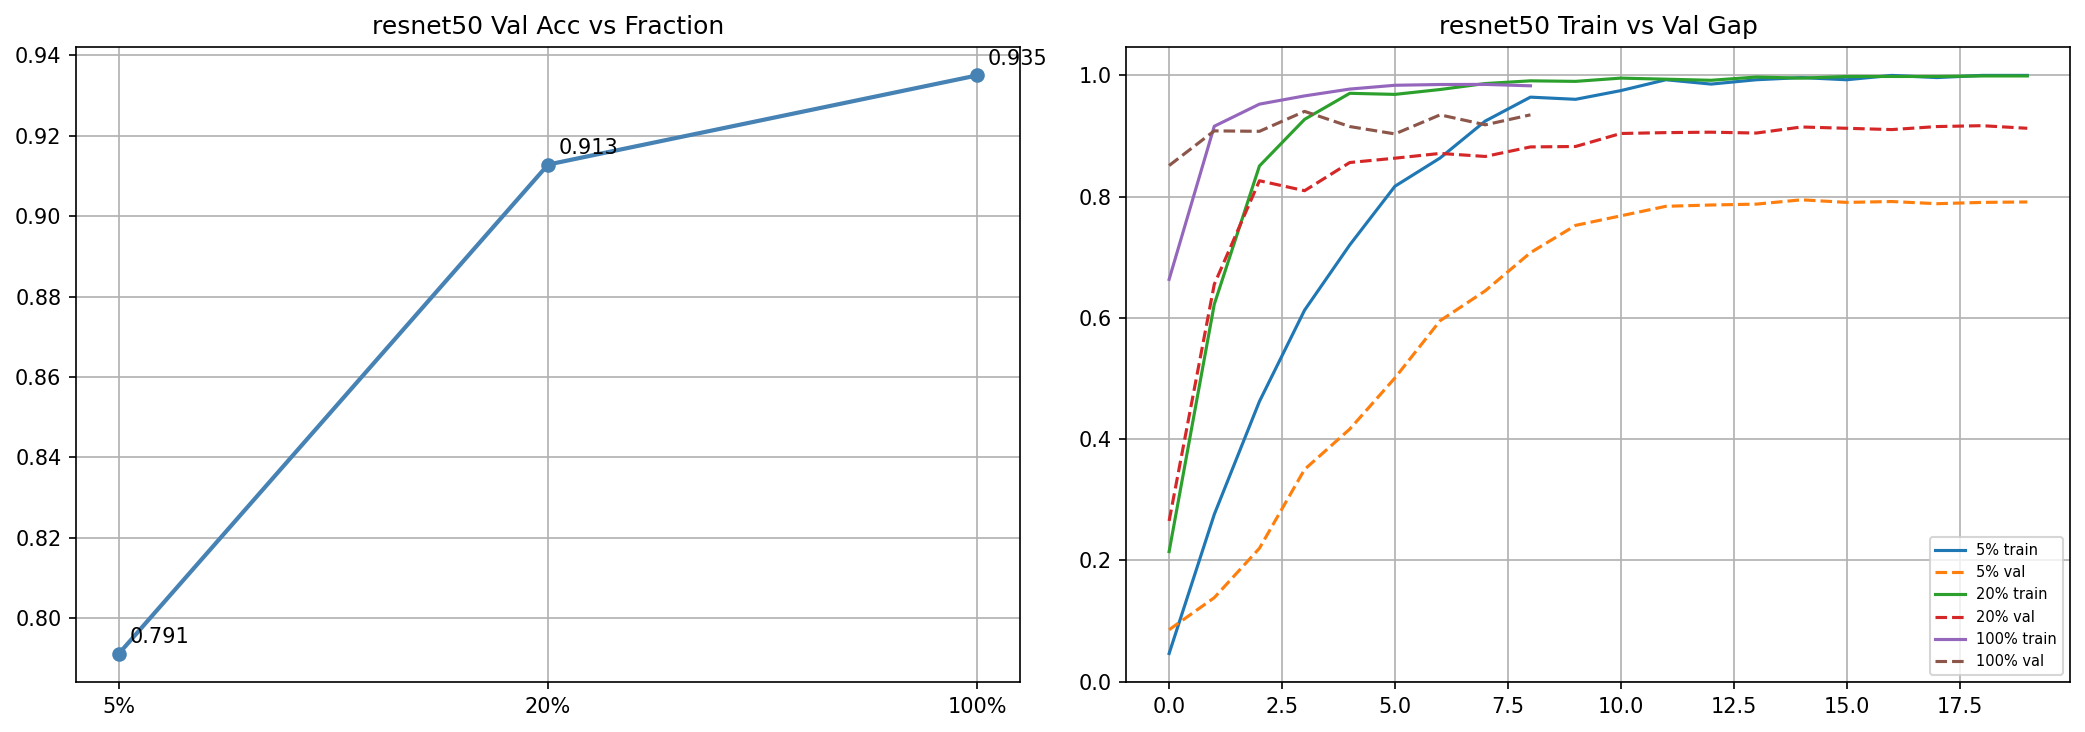


  S3 — resnet50
   model  fraction_pct  val_acc  train_acc  train_val_gap  relative_drop
resnet50           100   0.9350     0.9828         0.0479         0.1537
resnet50            20   0.9128     0.9991         0.0863         0.1537
resnet50             5   0.7913     1.0000         0.2087         0.1537


model,fraction_pct,val_acc,train_acc,train_val_gap,relative_drop
resnet50,100,0.9350,0.9828,0.0479,0.1537
resnet50,20,0.9128,0.9991,0.0863,0.1537
resnet50,5,0.7913,1.0000,0.2087,0.1537


  ✔  S3/resnet50 — 18.1 min

  S4 Corruption — resnet50
  Loaded S1 weights — no retraining
  Clean acc=0.8556
  GaussNoise_s0.05       acc=0.1937 err=0.8063 rr=0.2264
  GaussNoise_s0.10       acc=0.0543 err=0.9457 rr=0.0635
  GaussNoise_s0.20       acc=0.0536 err=0.9464 rr=0.0627
  MotionBlur             acc=0.3438 err=0.6562 rr=0.4018
  Brightness_x2          acc=0.7341 err=0.2659 rr=0.8580


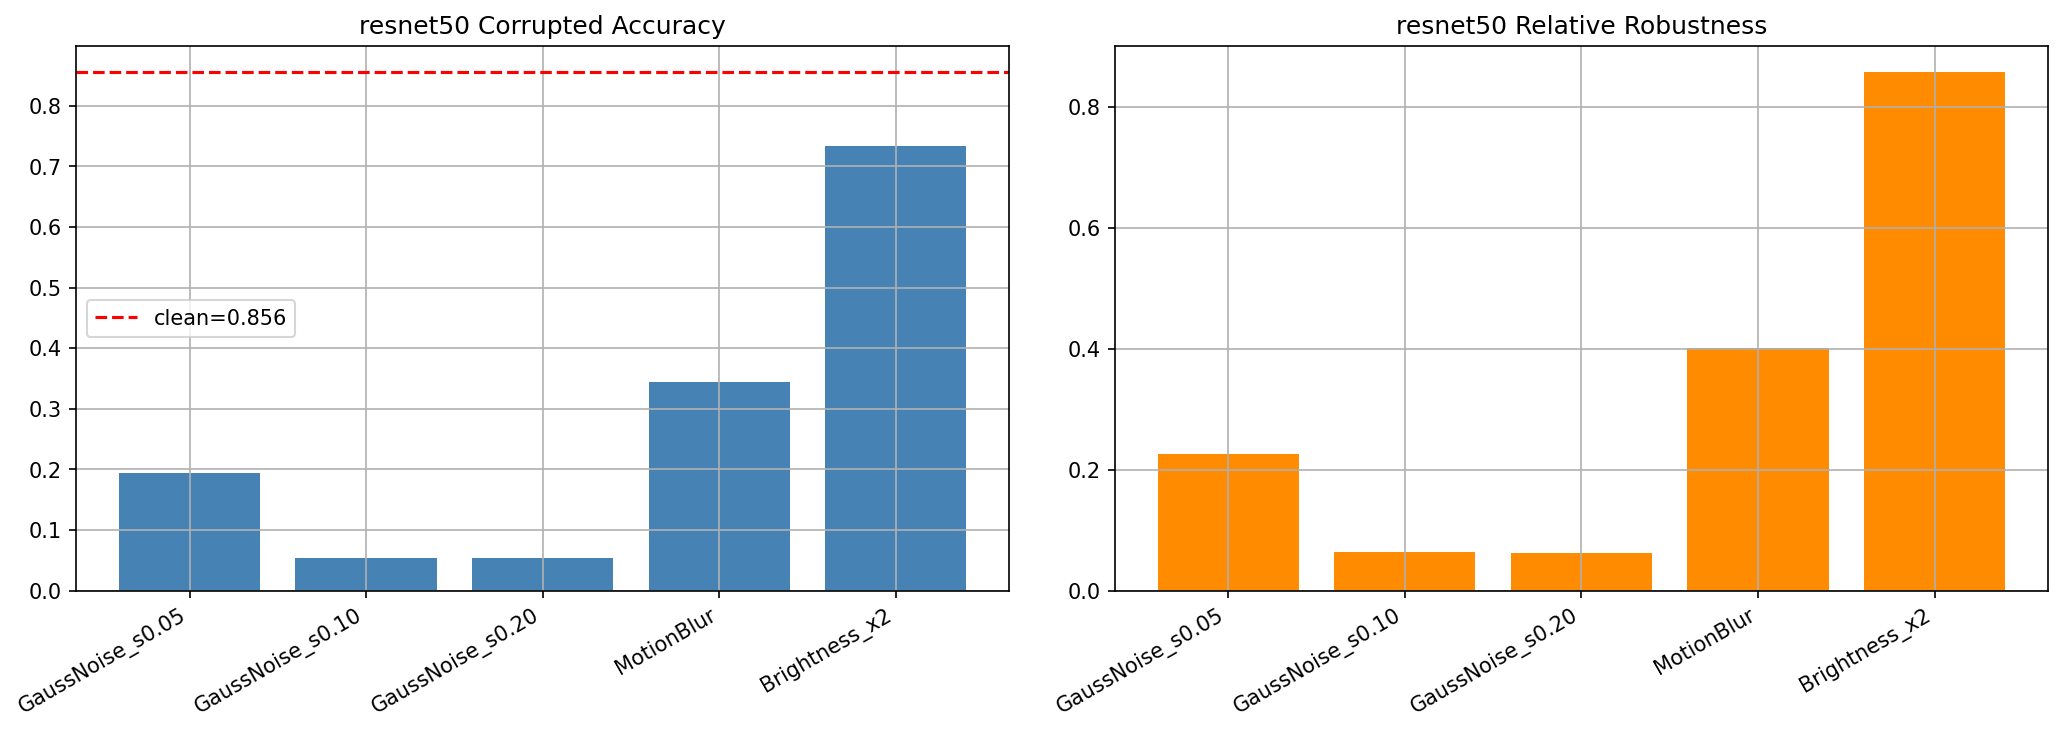


  S4 — resnet50
   model       corruption  clean_acc  corrupted_acc  corruption_error  relative_robustness
resnet50 GaussNoise_s0.05     0.8556         0.1937            0.8063               0.2264
resnet50 GaussNoise_s0.10     0.8556         0.0543            0.9457               0.0635
resnet50 GaussNoise_s0.20     0.8556         0.0536            0.9464               0.0627
resnet50       MotionBlur     0.8556         0.3438            0.6562               0.4018
resnet50    Brightness_x2     0.8556         0.7341            0.2659               0.8580


model,corruption,clean_acc,corrupted_acc,corruption_error,relative_robustness
resnet50,GaussNoise_s0.05,0.8556,0.1937,0.8063,0.2264
resnet50,GaussNoise_s0.10,0.8556,0.0543,0.9457,0.0635
resnet50,GaussNoise_s0.20,0.8556,0.0536,0.9464,0.0627
resnet50,MotionBlur,0.8556,0.3438,0.6562,0.4018
resnet50,Brightness_x2,0.8556,0.7341,0.2659,0.8580


  ✔  S4/resnet50 — 1.8 min

  S5 Layer Probing — resnet50
  Reusing S1 model — no retraining
  L1_early     probe_acc=0.0000 norm=18.8


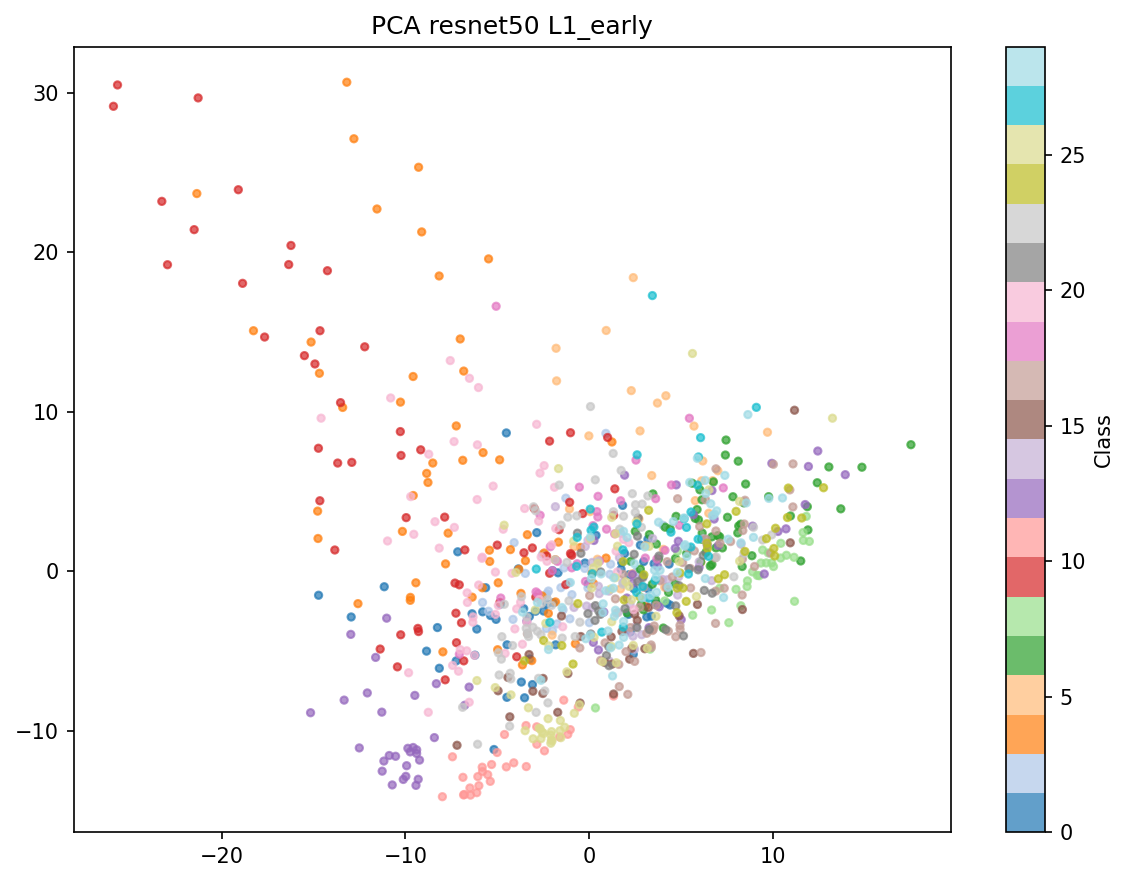

  L2_mid       probe_acc=0.0000 norm=50.5


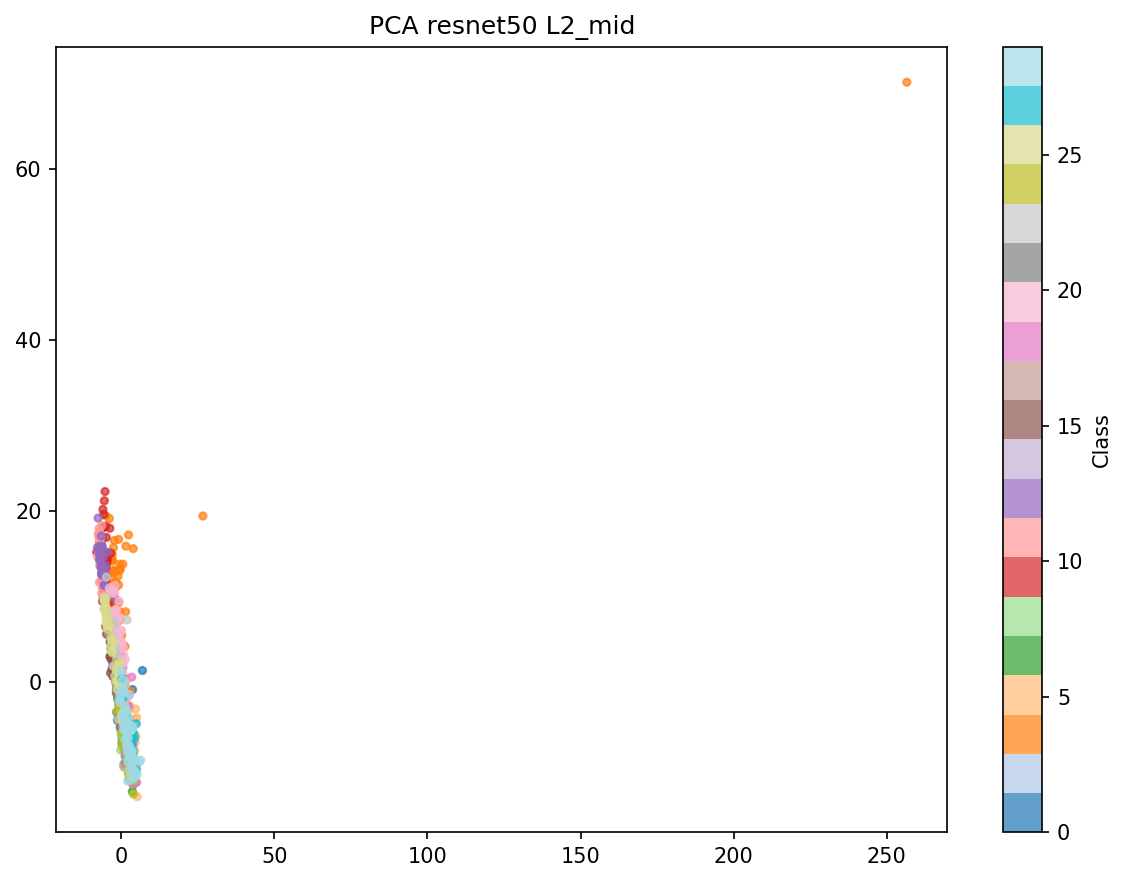

  L3_deep      probe_acc=0.0000 norm=45.2


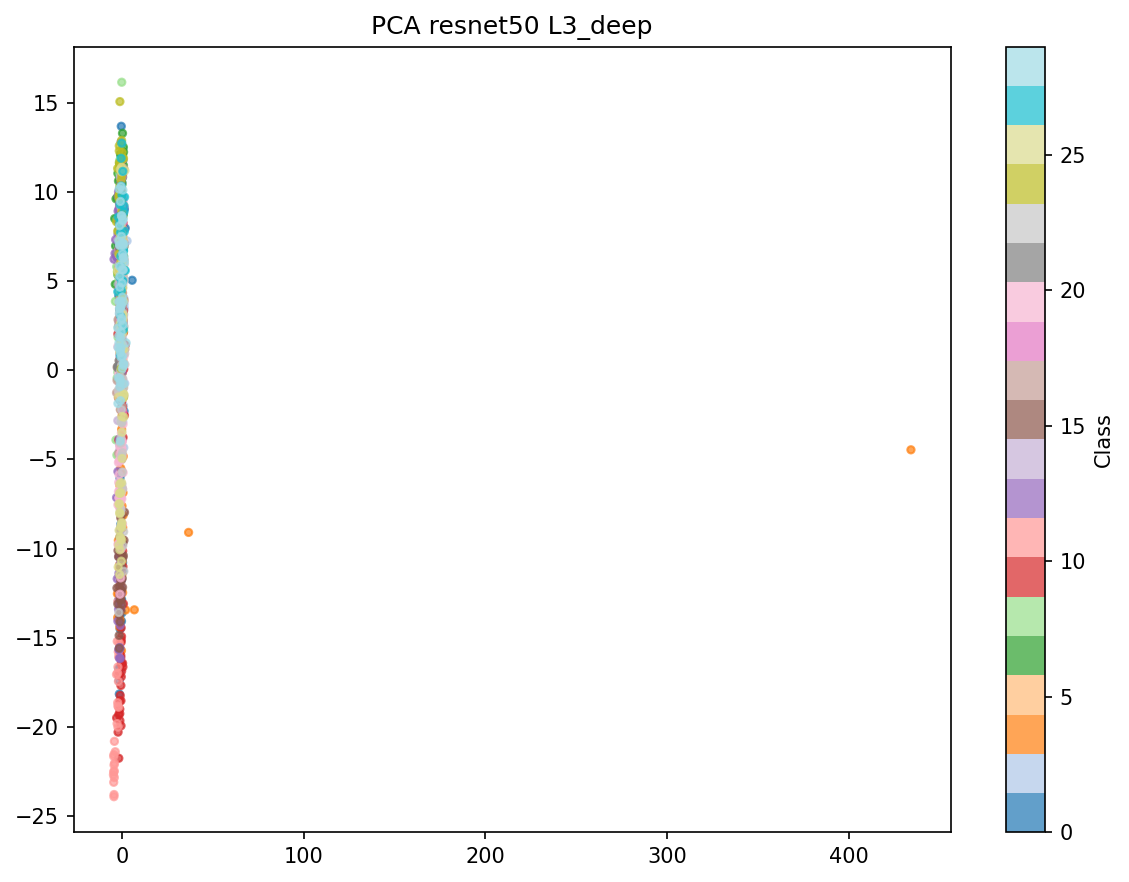

  L4_final     probe_acc=0.0000 norm=6.1


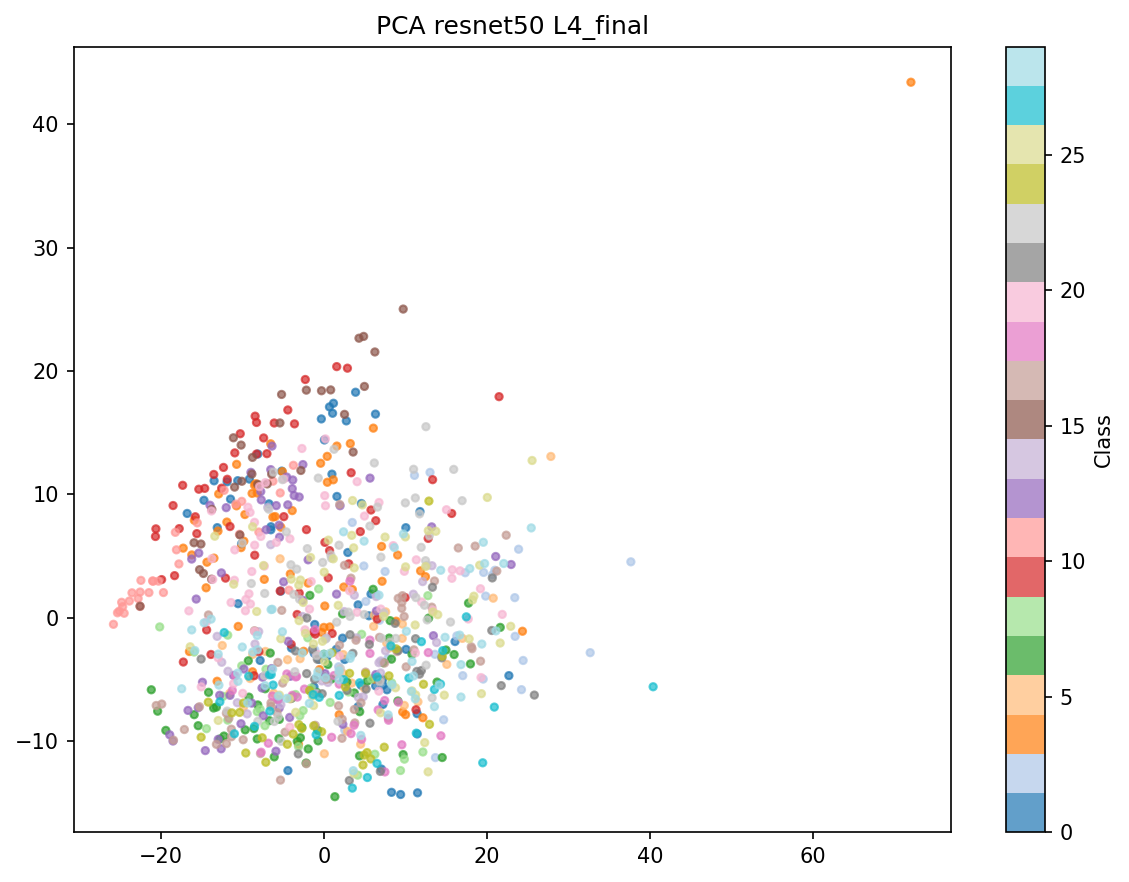

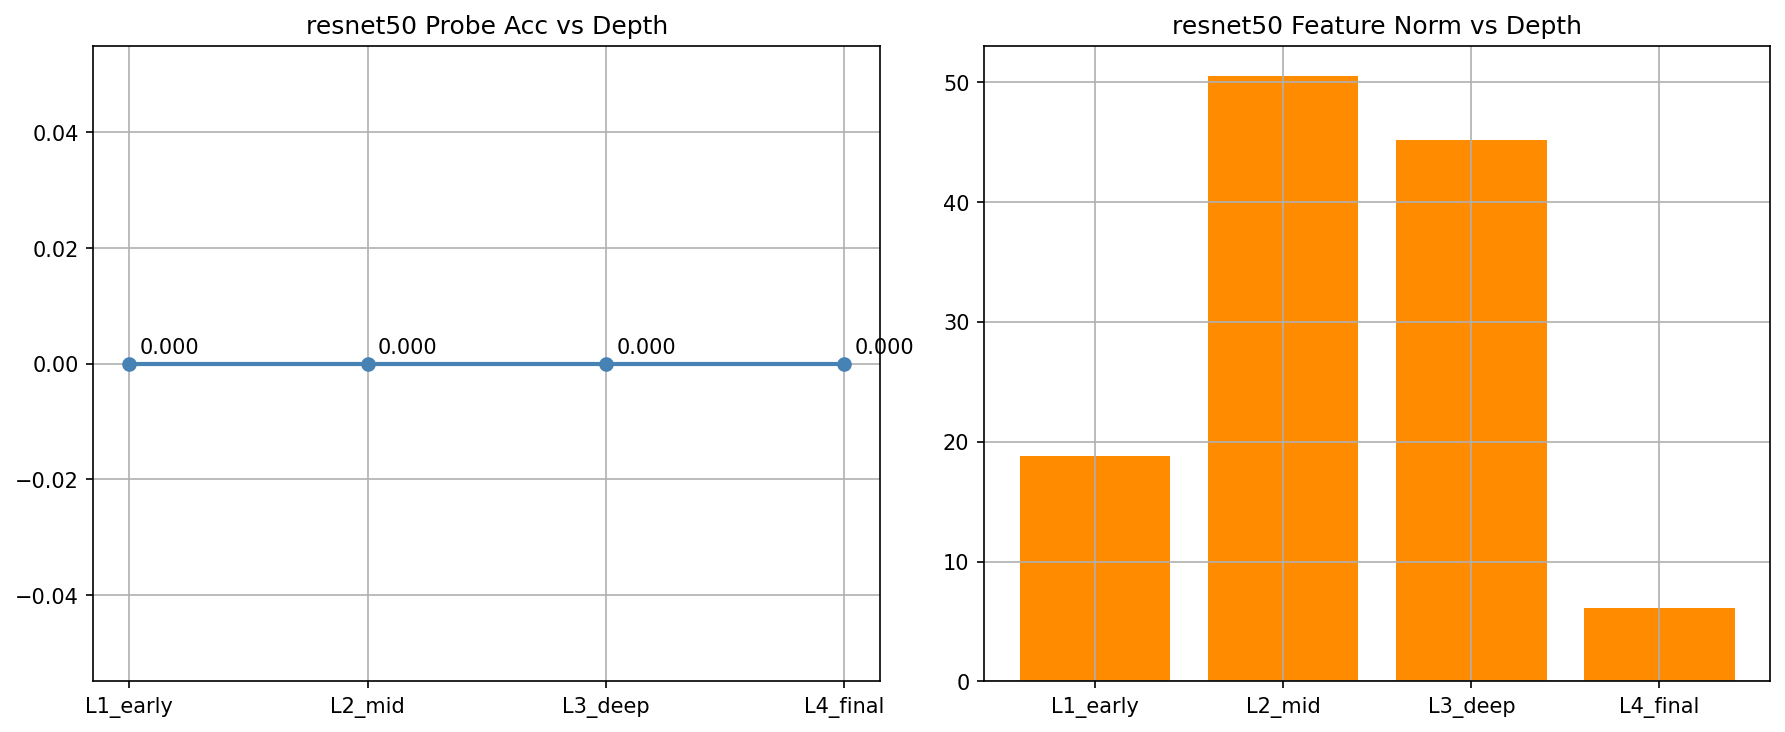


  S5 — resnet50
   model    layer  probe_acc  feat_norm  feat_dim
resnet50 L1_early        0.0    18.8258       256
resnet50   L2_mid        0.0    50.4889       512
resnet50  L3_deep        0.0    45.1804      1024
resnet50 L4_final        0.0     6.1147      2048


model,layer,probe_acc,feat_norm,feat_dim
resnet50,L1_early,0.0,18.8258,256
resnet50,L2_mid,0.0,50.4889,512
resnet50,L3_deep,0.0,45.1804,1024
resnet50,L4_final,0.0,6.1147,2048


  ✔  S5/resnet50 — 0.8 min

  BONUS Auto Layer Selection — resnet50


     Efficiency [resnet50/auto]
       Total params    : 23,569,502
       Trainable params: 4,629,598 (19.6%)
       MACs            : 4.132 G
       FLOPs (2xMACs)  : 8.264 G
    resnet50/auto                          ep01/20 train=0.050 val=0.102
    resnet50/auto                          ep02/20 train=0.215 val=0.186
    resnet50/auto                          ep03/20 train=0.308 val=0.212
    resnet50/auto                          ep04/20 train=0.358 val=0.254
    resnet50/auto                          ep05/20 train=0.470 val=0.279
    resnet50/auto                          ep06/20 train=0.591 val=0.326
    resnet50/auto                          ep07/20 train=0.656 val=0.378
    resnet50/auto                          ep08/20 train=0.717 val=0.435
    resnet50/auto                          ep09/20 train=0.785 val=0.482
    resnet50/auto                          ep10/20 train=0.839 val=0.523
    resnet50/auto                          ep11/20 train=0.871 val=0.558
    resnet50/auto   

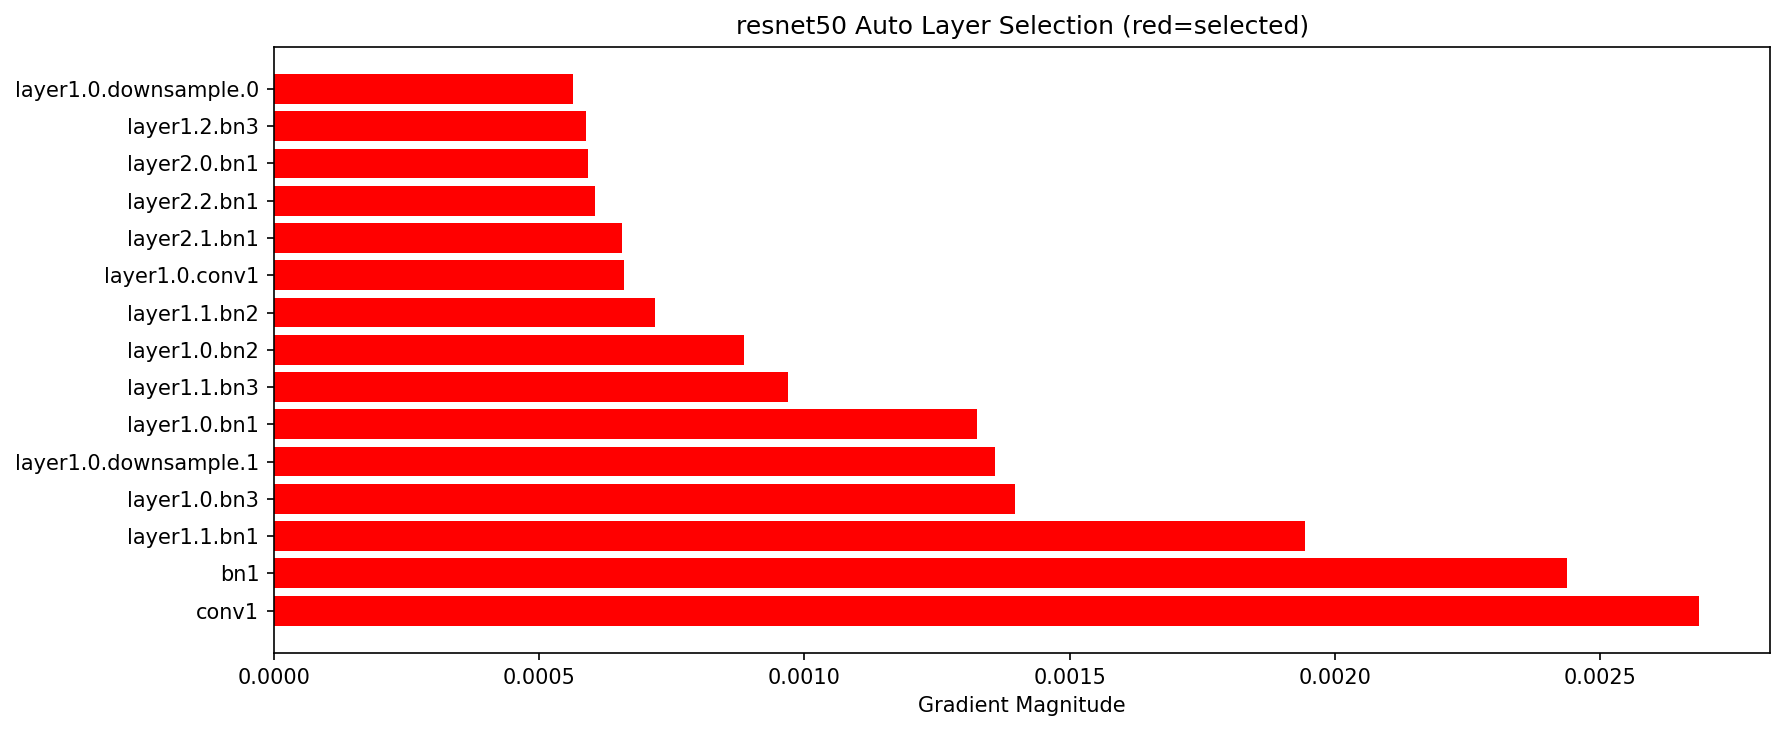

  88 layers=19.6% val=0.6455
  ✔  BONUS/resnet50 — 6.8 min

  🔵 RESNET50 COMPLETE — 130.7 min
  S1=33.8m S2=69.3m S3=18.1m S4=1.8m S5=0.8m BONUS=6.8m


In [9]:
# CELL 7: 🔵 RESNET50 — S1 S2 S3 S4 S5 BONUS
# Optimised: S1 reused in S2+S5 | S2-full reused in S3 | S4 eval only
# Early stopping cuts each run short when val acc plateaus

_mn   = "resnet50"
_tstart = time.time()
_outm = Path(OUTPUT_DIR)/"resnet50"; _outm.mkdir(exist_ok=True)
_crit = nn.CrossEntropyLoss()
_tl,_vl = get_loaders(data_root,train_idx,val_idx)

print(f"\n=================================================================")
print(f"  🔵  {_mn.upper()} — starting")
print(f"=================================================================")

# S1: Linear Probe ════════════════════════════════════════
section(f"S1 Linear Probe — {_mn}")
_t0=time.time()
_os1=_outm/"S1_LinearProbe"; _os1.mkdir(exist_ok=True)
_m1=build_model(_mn,"linear_probe")
_tot1,_trn1,_mac1=print_efficiency(f"{_mn}/linear_probe",_m1)
_h1,_=train_full(_m1,_tl,_vl,FULL_EPOCHS,label=f"{_mn}/linear_probe")
_,_va1,_pr1,_lb1=eval_epoch(_m1,_vl,_crit)
plot_curves({_mn:_h1},f"S1 — {_mn}",str(_os1/"curves.png"))
plot_confusion(_lb1,_pr1,classes,f"Confusion — {_mn}",str(_os1/"cm.png"))
_feats1,_flbls1=extract_penultimate(_m1,_vl)
plot_tsne(_feats1,_flbls1,f"t-SNE — {_mn}",str(_os1/"tsne.png"))
plot_pca2d(_feats1,_flbls1,f"PCA — {_mn}",str(_os1/"pca.png"))
torch.save(_m1.state_dict(),str(_os1/"weights.pt"))
_r1=dict(model=_mn,val_acc=round(_va1,4),total_params=_tot1,
         trainable_params=_trn1,MACs_G=round(_mac1/1e9,3),
         FLOPs_G=round(_mac1*2/1e9,3))
all_s1.append(_r1)
show_table(pd.DataFrame([_r1]),f"S1 — {_mn}")
pd.DataFrame([_r1]).to_csv(str(_os1/"result.csv"),index=False)
_ts1=time.time()-_t0; done(f"S1/{_mn}",_ts1)

# S2: Fine-Tuning Strategies ══════════════════════════════
section(f"S2 Fine-Tuning — {_mn}")
_t0=time.time()
_os2=_outm/"S2_FineTuning"; _os2.mkdir(exist_ok=True)
_sc=dict(linear_probe="blue",last_block="green",selective="orange",full="red")
_sh={"linear_probe":_h1}; _sg={"linear_probe":[]}
_ss={"linear_probe":dict(val_acc=round(_va1,4),pct=round(_trn1/_tot1*100,2))}
all_s2.append(dict(model=_mn,strategy="linear_probe",val_acc=round(_va1,4),
                   pct_unfrozen=round(_trn1/_tot1*100,2),trainable_params=_trn1,
                   MACs_G=round(_mac1/1e9,3)))
L(f"  linear_probe reused from S1 val={_va1:.4f}")

for _strat in ["last_block","selective","full"]:
    L(f"\n  strategy={_strat}")
    _ms=build_model(_mn,_strat)
    _tot2,_trn2,_mac2=print_efficiency(f"{_mn}/{_strat}",_ms)
    _hs,_gns=train_full(_ms,_tl,_vl,FULL_EPOCHS,label=f"{_mn}/{_strat}")
    _,_va2,_,_=eval_epoch(_ms,_vl,_crit)
    _sh[_strat]=_hs; _sg[_strat]=_gns
    _ss[_strat]=dict(val_acc=round(_va2,4),pct=round(_trn2/_tot2*100,2))
    all_s2.append(dict(model=_mn,strategy=_strat,val_acc=round(_va2,4),
                       pct_unfrozen=round(_trn2/_tot2*100,2),trainable_params=_trn2,
                       MACs_G=round(_mac2/1e9,3)))
    if _strat=="full": _m_full=_ms; _va_full=_va2; _h_full=_hs
    L(f"  val={_va2:.4f} unfrozen={_trn2/_tot2*100:.1f}%")

_stords=["linear_probe","last_block","selective","full"]
_accs=[_ss[s]["val_acc"] for s in _stords]
_pcts=[_ss[s]["pct"] for s in _stords]
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].bar(_stords,_accs,color=[_sc[s] for s in _stords])
[axes[0].text(i,a+0.005,f"{a:.3f}",ha="center",fontsize=8)
 for i,(s,a) in enumerate(zip(_stords,_accs))]
axes[0].set_title(f"{_mn} Val Acc by Strategy"); axes[0].set_ylim(0,1)
[axes[1].plot(h["train_loss"],label=s,color=_sc[s]) for s,h in _sh.items() if h]
axes[1].set_title(f"{_mn} Training Loss"); axes[1].legend(); axes[1].grid(True)
[axes[2].plot(gn,label=s,color=_sc[s]) for s,gn in _sg.items() if gn]
axes[2].set_title(f"{_mn} Gradient Norm"); axes[2].legend(); axes[2].grid(True)
savefig(str(_os2/"strategies.png"))
plt.figure(figsize=(8,5))
plt.plot(_pcts,_accs,"o-",color="steelblue",markersize=10)
[plt.annotate(s,(p,a),textcoords="offset points",xytext=(5,5),fontsize=8)
 for s,p,a in zip(_stords,_pcts,_accs)]
plt.xlabel("% Unfrozen"); plt.ylabel("Val Acc")
plt.title(f"{_mn} Acc vs % Unfrozen"); plt.grid(True)
savefig(str(_os2/"acc_vs_unfrozen.png"))
_df2m=pd.DataFrame([r for r in all_s2 if r["model"]==_mn])
show_table(_df2m,f"S2 — {_mn}")
_df2m.to_csv(str(_os2/"result.csv"),index=False)
_ts2=time.time()-_t0; done(f"S2/{_mn}",_ts2)

# S3: Few-Shot ════════════════════════════════════════════
section(f"S3 Few-Shot — {_mn}")
_t0=time.time()
_os3=_outm/"S3_FewShot"; _os3.mkdir(exist_ok=True)
_at={1.0:_va_full}; _hfs={1.0:_h_full}
all_s3.append(dict(model=_mn,fraction_pct=100,val_acc=round(_va_full,4),
                   train_acc=round(_h_full["train_acc"][-1],4),
                   train_val_gap=round(_h_full["train_acc"][-1]-_va_full,4)))
L(f"  100% reused from S2-full val={_va_full:.4f}")
for _fr in [0.20,0.05]:
    L(f"\n  fraction={_fr*100:.0f}%")
    _tlf,_vlf=get_loaders(data_root,train_idx,val_idx,subset_frac=_fr)
    _mf=build_model(_mn,"full")
    _hf,_=train_full(_mf,_tlf,_vlf,FEW_SHOT_EPOCHS,label=f"{_mn}/{_fr*100:.0f}%")
    _,_vaf,_,_=eval_epoch(_mf,_vlf,_crit)
    _taf=_hf["train_acc"][-1]; _gap=_taf-_vaf
    _at[_fr]=_vaf; _hfs[_fr]=_hf
    all_s3.append(dict(model=_mn,fraction_pct=int(_fr*100),val_acc=round(_vaf,4),
                       train_acc=round(_taf,4),train_val_gap=round(_gap,4)))
    L(f"  val={_vaf:.4f} gap={_gap:.4f}")
_rdrop=round((_at[1.0]-_at[0.05])/_at[1.0],4) if _at[1.0]>0 else 0.
for _r in all_s3:
    if _r["model"]==_mn: _r["relative_drop"]=_rdrop
fig,axes=plt.subplots(1,2,figsize=(14,5))
_fls=["5%","20%","100%"]; _fas=[_at[f] for f in [0.05,0.20,1.0]]
axes[0].plot(_fls,_fas,marker="o",color="steelblue",linewidth=2)
[axes[0].annotate(f"{a:.3f}",(i,a),textcoords="offset points",xytext=(5,5))
 for i,(l,a) in enumerate(zip(_fls,_fas))]
axes[0].set_title(f"{_mn} Val Acc vs Fraction"); axes[0].grid(True)
for _fr in [0.05,0.20,1.0]:
    axes[1].plot(_hfs[_fr]["train_acc"],ls="-",label=f"{_fr*100:.0f}% train")
    axes[1].plot(_hfs[_fr]["val_acc"],  ls="--",label=f"{_fr*100:.0f}% val")
axes[1].set_title(f"{_mn} Train vs Val Gap"); axes[1].legend(fontsize=7); axes[1].grid(True)
savefig(str(_os3/"few_shot.png"))
_df3m=pd.DataFrame([r for r in all_s3 if r["model"]==_mn])
show_table(_df3m,f"S3 — {_mn}")
_df3m.to_csv(str(_os3/"result.csv"),index=False)
_ts3=time.time()-_t0; done(f"S3/{_mn}",_ts3)

# S4: Corruption ══════════════════════════════════════════
section(f"S4 Corruption — {_mn}")
_t0=time.time()
_os4=_outm/"S4_Corruption"; _os4.mkdir(exist_ok=True)
_m4=build_model(_mn,"full")
_m4.load_state_dict(torch.load(str(_os1/"weights.pt"),
                               map_location=DEVICE,weights_only=False),strict=False)
L("  Loaded S1 weights — no retraining")
_,_vlc=get_loaders(data_root,train_idx,val_idx)
_,_cacc,_,_=eval_epoch(_m4,_vlc,_crit)
L(f"  Clean acc={_cacc:.4f}")
for _kind,_sev,_lbl in CORRUPTIONS:
    _,_cl=get_loaders(data_root,train_idx,val_idx,
                      val_transform=corruption_tf(_kind,_sev))
    _,_ca,_,_=eval_epoch(_m4,_cl,_crit)
    _err=round(1-_ca,4); _rr=round(_ca/_cacc,4) if _cacc>0 else 0.
    all_s4.append(dict(model=_mn,corruption=_lbl,clean_acc=round(_cacc,4),
                       corrupted_acc=round(_ca,4),corruption_error=_err,
                       relative_robustness=_rr))
    L(f"  {_lbl:22s} acc={_ca:.4f} err={_err:.4f} rr={_rr:.4f}")
_df4m=pd.DataFrame([r for r in all_s4 if r["model"]==_mn])
_clbls=[c[2] for c in CORRUPTIONS]
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(range(len(_clbls)),_df4m["corrupted_acc"],color="steelblue")
axes[0].axhline(_cacc,color="red",ls="--",label=f"clean={_cacc:.3f}")
axes[0].set_xticks(range(len(_clbls))); axes[0].set_xticklabels(_clbls,rotation=30,ha="right")
axes[0].set_title(f"{_mn} Corrupted Accuracy"); axes[0].legend(); axes[0].grid(True)
axes[1].bar(range(len(_clbls)),_df4m["relative_robustness"],color="darkorange")
axes[1].set_xticks(range(len(_clbls))); axes[1].set_xticklabels(_clbls,rotation=30,ha="right")
axes[1].set_title(f"{_mn} Relative Robustness"); axes[1].grid(True)
savefig(str(_os4/"corruption.png"))
show_table(_df4m,f"S4 — {_mn}")
_df4m.to_csv(str(_os4/"result.csv"),index=False)
_ts4=time.time()-_t0; done(f"S4/{_mn}",_ts4)

# S5: Layer Probing ═══════════════════════════════════════
section(f"S5 Layer Probing — {_mn}")
_t0=time.time()
_os5=_outm/"S5_LayerProbing"; _os5.mkdir(exist_ok=True)
_m5=_m1; _m5.eval()
L("  Reusing S1 model — no retraining")
_lmap=get_layer_map(_m5,_mn); _daccs=[]; _dnorms=[]; _llbls=list(_lmap.keys())
for _dl,_mod in _lmap.items():
    _hkst={}
    def _hkfn(mod,inp,out,_st=_hkst):
        f=out.detach().cpu()
        _st["f"]=f.mean(dim=[2,3]) if f.dim()==4 else f.flatten(1)
    _hk=_mod.register_forward_hook(_hkfn); _fl=[]
    with torch.no_grad():
        for _imgs5,_ in probe_loader:
            _m5(_imgs5.to(DEVICE)); _fl.append(_hkst["f"].numpy())
    _hk.remove()
    _fts=np.vstack(_fl); _fn=float(np.linalg.norm(_fts,axis=1).mean())
    _sp=int(0.8*len(_fts)); _X=StandardScaler().fit_transform(_fts)
    _clf=LogisticRegression(max_iter=500,random_state=SEED,C=1.0)
    _clf.fit(_X[:_sp],probe_labels[:_sp])
    _pa=float(_clf.score(_X[_sp:],probe_labels[_sp:]))
    _daccs.append(_pa); _dnorms.append(_fn)
    all_s5.append(dict(model=_mn,layer=_dl,probe_acc=round(_pa,4),
                       feat_norm=round(_fn,4),feat_dim=_fts.shape[1]))
    L(f"  {_dl:12s} probe_acc={_pa:.4f} norm={_fn:.1f}")
    plot_pca2d(_X,probe_labels,f"PCA {_mn} {_dl}",str(_os5/f"pca_{_dl}.png"))
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(_llbls,_daccs,marker="o",color="steelblue",linewidth=2)
[axes[0].annotate(f"{a:.3f}",(i,a),textcoords="offset points",xytext=(5,5))
 for i,(l,a) in enumerate(zip(_llbls,_daccs))]
axes[0].set_title(f"{_mn} Probe Acc vs Depth"); axes[0].grid(True)
axes[1].bar(_llbls,_dnorms,color="darkorange")
axes[1].set_title(f"{_mn} Feature Norm vs Depth"); axes[1].grid(True)
savefig(str(_os5/"depth.png"))
_df5m=pd.DataFrame([r for r in all_s5 if r["model"]==_mn])
show_table(_df5m,f"S5 — {_mn}")
_df5m.to_csv(str(_os5/"result.csv"),index=False)
_ts5=time.time()-_t0; done(f"S5/{_mn}",_ts5)

# BONUS: Auto Gradient Layer Selection ════════════════════
section(f"BONUS Auto Layer Selection — {_mn}")
_t0=time.time()
_osb=_outm/"BONUS"; _osb.mkdir(exist_ok=True)
_mb=build_model(_mn,"full"); _mb.train()
_tlb,_vlb=get_loaders(data_root,train_idx,val_idx,subset_frac=0.05)
_optb=optim.SGD(_mb.parameters(),lr=0.01)
for _ib,_lb2 in _tlb:
    _optb.zero_grad()
    _crit(_mb(_ib.to(DEVICE)),_lb2.to(DEVICE)).backward(); break
_lscores={}
for _bnn,_bp in _mb.named_parameters():
    if _bp.grad is not None and not is_head(_bnn):
        _bg=_bnn.rsplit(".",1)[0]
        _lscores.setdefault(_bg,[]).append(_bp.grad.abs().mean().item())
_lscores={k:float(np.mean(v)) for k,v in _lscores.items()}
_ranked=sorted(_lscores.items(),key=lambda x:x[1],reverse=True)
_totp,_=param_stats(_mb); _tgt=int(0.2*_totp)
_sel=[]; _selp=0
for _bln,_ in _ranked:
    _lp=sum(_bp.numel() for _bnn,_bp in _mb.named_parameters()
            if _bnn.startswith(_bln))
    if _selp+_lp<=_tgt: _sel.append(_bln); _selp+=_lp
for _bp in _mb.parameters(): _bp.requires_grad=False
for _bnn,_bp in _mb.named_parameters():
    if any(_bnn.startswith(l) for l in _sel) or is_head(_bnn):
        _bp.requires_grad=True
_totb,_trnb,_macb=print_efficiency(f"{_mn}/auto",_mb)
_hb,_=train_full(_mb,_tlb,_vlb,FEW_SHOT_EPOCHS,label=f"{_mn}/auto")
_,_vab,_,_=eval_epoch(_mb,_vlb,_crit)
all_bonus.append(dict(model=_mn,strategy="auto_gradient",val_acc=round(_vab,4),
                      pct_unfrozen=round(_trnb/_totb*100,2),n_layers=len(_sel)))
_t15=[r[0] for r in _ranked[:15]]; _s15=[r[1] for r in _ranked[:15]]
plt.figure(figsize=(12,5))
plt.barh(_t15,_s15,color=["red" if l in _sel else "steelblue" for l in _t15])
plt.xlabel("Gradient Magnitude")
plt.title(f"{_mn} Auto Layer Selection (red=selected)")
plt.tight_layout(); savefig(str(_osb/"grad_scores.png"))
L(f"  {len(_sel)} layers={_trnb/_totb*100:.1f}% val={_vab:.4f}")
pd.DataFrame([all_bonus[-1]]).to_csv(str(_osb/"result.csv"),index=False)
_tb=time.time()-_t0; done(f"BONUS/{_mn}",_tb)

# Model complete ══════════════════════════════════════════
_ttot=time.time()-_tstart
timings[_mn]=dict(S1=round(_ts1/60,1),S2=round(_ts2/60,1),
                  S3=round(_ts3/60,1),S4=round(_ts4/60,1),
                  S5=round(_ts5/60,1),BONUS=round(_tb/60,1),
                  TOTAL=round(_ttot/60,1))
print(f"\n=================================================================")
print(f"  🔵 {_mn.upper()} COMPLETE — {_ttot/60:.1f} min")
print(f"  S1={_ts1/60:.1f}m S2={_ts2/60:.1f}m S3={_ts3/60:.1f}m "
      f"S4={_ts4/60:.1f}m S5={_ts5/60:.1f}m BONUS={_tb/60:.1f}m")
print(f"=================================================================")


In [ ]:
# CELL 8: 🟠 EFFICIENTNET_B0 — S1 S2 S3 S4 S5 BONUS
# Optimised: S1 reused in S2+S5 | S2-full reused in S3 | S4 eval only
# Early stopping cuts each run short when val acc plateaus

_mn   = "efficientnet_b0"
_tstart = time.time()
_outm = Path(OUTPUT_DIR)/"efficientnet_b0"; _outm.mkdir(exist_ok=True)
_crit = nn.CrossEntropyLoss()
_tl,_vl = get_loaders(data_root,train_idx,val_idx)

print(f"\n=================================================================")
print(f"  🟠  {_mn.upper()} — starting")
print(f"=================================================================")

# S1: Linear Probe ════════════════════════════════════════
section(f"S1 Linear Probe — {_mn}")
_t0=time.time()
_os1=_outm/"S1_LinearProbe"; _os1.mkdir(exist_ok=True)
_m1=build_model(_mn,"linear_probe")
_tot1,_trn1,_mac1=print_efficiency(f"{_mn}/linear_probe",_m1)
_h1,_=train_full(_m1,_tl,_vl,FULL_EPOCHS,label=f"{_mn}/linear_probe")
_,_va1,_pr1,_lb1=eval_epoch(_m1,_vl,_crit)
plot_curves({_mn:_h1},f"S1 — {_mn}",str(_os1/"curves.png"))
plot_confusion(_lb1,_pr1,classes,f"Confusion — {_mn}",str(_os1/"cm.png"))
_feats1,_flbls1=extract_penultimate(_m1,_vl)
plot_tsne(_feats1,_flbls1,f"t-SNE — {_mn}",str(_os1/"tsne.png"))
plot_pca2d(_feats1,_flbls1,f"PCA — {_mn}",str(_os1/"pca.png"))
torch.save(_m1.state_dict(),str(_os1/"weights.pt"))
_r1=dict(model=_mn,val_acc=round(_va1,4),total_params=_tot1,
         trainable_params=_trn1,MACs_G=round(_mac1/1e9,3),
         FLOPs_G=round(_mac1*2/1e9,3))
all_s1.append(_r1)
show_table(pd.DataFrame([_r1]),f"S1 — {_mn}")
pd.DataFrame([_r1]).to_csv(str(_os1/"result.csv"),index=False)
_ts1=time.time()-_t0; done(f"S1/{_mn}",_ts1)

# S2: Fine-Tuning Strategies ══════════════════════════════
section(f"S2 Fine-Tuning — {_mn}")
_t0=time.time()
_os2=_outm/"S2_FineTuning"; _os2.mkdir(exist_ok=True)
_sc=dict(linear_probe="blue",last_block="green",selective="orange",full="red")
_sh={"linear_probe":_h1}; _sg={"linear_probe":[]}
_ss={"linear_probe":dict(val_acc=round(_va1,4),pct=round(_trn1/_tot1*100,2))}
all_s2.append(dict(model=_mn,strategy="linear_probe",val_acc=round(_va1,4),
                   pct_unfrozen=round(_trn1/_tot1*100,2),trainable_params=_trn1,
                   MACs_G=round(_mac1/1e9,3)))
L(f"  linear_probe reused from S1 val={_va1:.4f}")

for _strat in ["last_block","selective","full"]:
    L(f"\n  strategy={_strat}")
    _ms=build_model(_mn,_strat)
    _tot2,_trn2,_mac2=print_efficiency(f"{_mn}/{_strat}",_ms)
    _hs,_gns=train_full(_ms,_tl,_vl,FULL_EPOCHS,label=f"{_mn}/{_strat}")
    _,_va2,_,_=eval_epoch(_ms,_vl,_crit)
    _sh[_strat]=_hs; _sg[_strat]=_gns
    _ss[_strat]=dict(val_acc=round(_va2,4),pct=round(_trn2/_tot2*100,2))
    all_s2.append(dict(model=_mn,strategy=_strat,val_acc=round(_va2,4),
                       pct_unfrozen=round(_trn2/_tot2*100,2),trainable_params=_trn2,
                       MACs_G=round(_mac2/1e9,3)))
    if _strat=="full": _m_full=_ms; _va_full=_va2; _h_full=_hs
    L(f"  val={_va2:.4f} unfrozen={_trn2/_tot2*100:.1f}%")

_stords=["linear_probe","last_block","selective","full"]
_accs=[_ss[s]["val_acc"] for s in _stords]
_pcts=[_ss[s]["pct"] for s in _stords]
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].bar(_stords,_accs,color=[_sc[s] for s in _stords])
[axes[0].text(i,a+0.005,f"{a:.3f}",ha="center",fontsize=8)
 for i,(s,a) in enumerate(zip(_stords,_accs))]
axes[0].set_title(f"{_mn} Val Acc by Strategy"); axes[0].set_ylim(0,1)
[axes[1].plot(h["train_loss"],label=s,color=_sc[s]) for s,h in _sh.items() if h]
axes[1].set_title(f"{_mn} Training Loss"); axes[1].legend(); axes[1].grid(True)
[axes[2].plot(gn,label=s,color=_sc[s]) for s,gn in _sg.items() if gn]
axes[2].set_title(f"{_mn} Gradient Norm"); axes[2].legend(); axes[2].grid(True)
savefig(str(_os2/"strategies.png"))
plt.figure(figsize=(8,5))
plt.plot(_pcts,_accs,"o-",color="steelblue",markersize=10)
[plt.annotate(s,(p,a),textcoords="offset points",xytext=(5,5),fontsize=8)
 for s,p,a in zip(_stords,_pcts,_accs)]
plt.xlabel("% Unfrozen"); plt.ylabel("Val Acc")
plt.title(f"{_mn} Acc vs % Unfrozen"); plt.grid(True)
savefig(str(_os2/"acc_vs_unfrozen.png"))
_df2m=pd.DataFrame([r for r in all_s2 if r["model"]==_mn])
show_table(_df2m,f"S2 — {_mn}")
_df2m.to_csv(str(_os2/"result.csv"),index=False)
_ts2=time.time()-_t0; done(f"S2/{_mn}",_ts2)

# S3: Few-Shot ════════════════════════════════════════════
section(f"S3 Few-Shot — {_mn}")
_t0=time.time()
_os3=_outm/"S3_FewShot"; _os3.mkdir(exist_ok=True)
_at={1.0:_va_full}; _hfs={1.0:_h_full}
all_s3.append(dict(model=_mn,fraction_pct=100,val_acc=round(_va_full,4),
                   train_acc=round(_h_full["train_acc"][-1],4),
                   train_val_gap=round(_h_full["train_acc"][-1]-_va_full,4)))
L(f"  100% reused from S2-full val={_va_full:.4f}")
for _fr in [0.20,0.05]:
    L(f"\n  fraction={_fr*100:.0f}%")
    _tlf,_vlf=get_loaders(data_root,train_idx,val_idx,subset_frac=_fr)
    _mf=build_model(_mn,"full")
    _hf,_=train_full(_mf,_tlf,_vlf,FEW_SHOT_EPOCHS,label=f"{_mn}/{_fr*100:.0f}%")
    _,_vaf,_,_=eval_epoch(_mf,_vlf,_crit)
    _taf=_hf["train_acc"][-1]; _gap=_taf-_vaf
    _at[_fr]=_vaf; _hfs[_fr]=_hf
    all_s3.append(dict(model=_mn,fraction_pct=int(_fr*100),val_acc=round(_vaf,4),
                       train_acc=round(_taf,4),train_val_gap=round(_gap,4)))
    L(f"  val={_vaf:.4f} gap={_gap:.4f}")
_rdrop=round((_at[1.0]-_at[0.05])/_at[1.0],4) if _at[1.0]>0 else 0.
for _r in all_s3:
    if _r["model"]==_mn: _r["relative_drop"]=_rdrop
fig,axes=plt.subplots(1,2,figsize=(14,5))
_fls=["5%","20%","100%"]; _fas=[_at[f] for f in [0.05,0.20,1.0]]
axes[0].plot(_fls,_fas,marker="o",color="steelblue",linewidth=2)
[axes[0].annotate(f"{a:.3f}",(i,a),textcoords="offset points",xytext=(5,5))
 for i,(l,a) in enumerate(zip(_fls,_fas))]
axes[0].set_title(f"{_mn} Val Acc vs Fraction"); axes[0].grid(True)
for _fr in [0.05,0.20,1.0]:
    axes[1].plot(_hfs[_fr]["train_acc"],ls="-",label=f"{_fr*100:.0f}% train")
    axes[1].plot(_hfs[_fr]["val_acc"],  ls="--",label=f"{_fr*100:.0f}% val")
axes[1].set_title(f"{_mn} Train vs Val Gap"); axes[1].legend(fontsize=7); axes[1].grid(True)
savefig(str(_os3/"few_shot.png"))
_df3m=pd.DataFrame([r for r in all_s3 if r["model"]==_mn])
show_table(_df3m,f"S3 — {_mn}")
_df3m.to_csv(str(_os3/"result.csv"),index=False)
_ts3=time.time()-_t0; done(f"S3/{_mn}",_ts3)

# S4: Corruption ══════════════════════════════════════════
section(f"S4 Corruption — {_mn}")
_t0=time.time()
_os4=_outm/"S4_Corruption"; _os4.mkdir(exist_ok=True)
_m4=build_model(_mn,"full")
_m4.load_state_dict(torch.load(str(_os1/"weights.pt"),
                               map_location=DEVICE,weights_only=False),strict=False)
L("  Loaded S1 weights — no retraining")
_,_vlc=get_loaders(data_root,train_idx,val_idx)
_,_cacc,_,_=eval_epoch(_m4,_vlc,_crit)
L(f"  Clean acc={_cacc:.4f}")
for _kind,_sev,_lbl in CORRUPTIONS:
    _,_cl=get_loaders(data_root,train_idx,val_idx,
                      val_transform=corruption_tf(_kind,_sev))
    _,_ca,_,_=eval_epoch(_m4,_cl,_crit)
    _err=round(1-_ca,4); _rr=round(_ca/_cacc,4) if _cacc>0 else 0.
    all_s4.append(dict(model=_mn,corruption=_lbl,clean_acc=round(_cacc,4),
                       corrupted_acc=round(_ca,4),corruption_error=_err,
                       relative_robustness=_rr))
    L(f"  {_lbl:22s} acc={_ca:.4f} err={_err:.4f} rr={_rr:.4f}")
_df4m=pd.DataFrame([r for r in all_s4 if r["model"]==_mn])
_clbls=[c[2] for c in CORRUPTIONS]
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(range(len(_clbls)),_df4m["corrupted_acc"],color="steelblue")
axes[0].axhline(_cacc,color="red",ls="--",label=f"clean={_cacc:.3f}")
axes[0].set_xticks(range(len(_clbls))); axes[0].set_xticklabels(_clbls,rotation=30,ha="right")
axes[0].set_title(f"{_mn} Corrupted Accuracy"); axes[0].legend(); axes[0].grid(True)
axes[1].bar(range(len(_clbls)),_df4m["relative_robustness"],color="darkorange")
axes[1].set_xticks(range(len(_clbls))); axes[1].set_xticklabels(_clbls,rotation=30,ha="right")
axes[1].set_title(f"{_mn} Relative Robustness"); axes[1].grid(True)
savefig(str(_os4/"corruption.png"))
show_table(_df4m,f"S4 — {_mn}")
_df4m.to_csv(str(_os4/"result.csv"),index=False)
_ts4=time.time()-_t0; done(f"S4/{_mn}",_ts4)

# S5: Layer Probing ═══════════════════════════════════════
section(f"S5 Layer Probing — {_mn}")
_t0=time.time()
_os5=_outm/"S5_LayerProbing"; _os5.mkdir(exist_ok=True)
_m5=_m1; _m5.eval()
L("  Reusing S1 model — no retraining")
_lmap=get_layer_map(_m5,_mn); _daccs=[]; _dnorms=[]; _llbls=list(_lmap.keys())
for _dl,_mod in _lmap.items():
    _hkst={}
    def _hkfn(mod,inp,out,_st=_hkst):
        f=out.detach().cpu()
        _st["f"]=f.mean(dim=[2,3]) if f.dim()==4 else f.flatten(1)
    _hk=_mod.register_forward_hook(_hkfn); _fl=[]
    with torch.no_grad():
        for _imgs5,_ in probe_loader:
            _m5(_imgs5.to(DEVICE)); _fl.append(_hkst["f"].numpy())
    _hk.remove()
    _fts=np.vstack(_fl); _fn=float(np.linalg.norm(_fts,axis=1).mean())
    _sp=int(0.8*len(_fts)); _X=StandardScaler().fit_transform(_fts)
    _clf=LogisticRegression(max_iter=500,random_state=SEED,C=1.0)
    _clf.fit(_X[:_sp],probe_labels[:_sp])
    _pa=float(_clf.score(_X[_sp:],probe_labels[_sp:]))
    _daccs.append(_pa); _dnorms.append(_fn)
    all_s5.append(dict(model=_mn,layer=_dl,probe_acc=round(_pa,4),
                       feat_norm=round(_fn,4),feat_dim=_fts.shape[1]))
    L(f"  {_dl:12s} probe_acc={_pa:.4f} norm={_fn:.1f}")
    plot_pca2d(_X,probe_labels,f"PCA {_mn} {_dl}",str(_os5/f"pca_{_dl}.png"))
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(_llbls,_daccs,marker="o",color="steelblue",linewidth=2)
[axes[0].annotate(f"{a:.3f}",(i,a),textcoords="offset points",xytext=(5,5))
 for i,(l,a) in enumerate(zip(_llbls,_daccs))]
axes[0].set_title(f"{_mn} Probe Acc vs Depth"); axes[0].grid(True)
axes[1].bar(_llbls,_dnorms,color="darkorange")
axes[1].set_title(f"{_mn} Feature Norm vs Depth"); axes[1].grid(True)
savefig(str(_os5/"depth.png"))
_df5m=pd.DataFrame([r for r in all_s5 if r["model"]==_mn])
show_table(_df5m,f"S5 — {_mn}")
_df5m.to_csv(str(_os5/"result.csv"),index=False)
_ts5=time.time()-_t0; done(f"S5/{_mn}",_ts5)

# BONUS: Auto Gradient Layer Selection ════════════════════
section(f"BONUS Auto Layer Selection — {_mn}")
_t0=time.time()
_osb=_outm/"BONUS"; _osb.mkdir(exist_ok=True)
_mb=build_model(_mn,"full"); _mb.train()
_tlb,_vlb=get_loaders(data_root,train_idx,val_idx,subset_frac=0.05)
_optb=optim.SGD(_mb.parameters(),lr=0.01)
for _ib,_lb2 in _tlb:
    _optb.zero_grad()
    _crit(_mb(_ib.to(DEVICE)),_lb2.to(DEVICE)).backward(); break
_lscores={}
for _bnn,_bp in _mb.named_parameters():
    if _bp.grad is not None and not is_head(_bnn):
        _bg=_bnn.rsplit(".",1)[0]
        _lscores.setdefault(_bg,[]).append(_bp.grad.abs().mean().item())
_lscores={k:float(np.mean(v)) for k,v in _lscores.items()}
_ranked=sorted(_lscores.items(),key=lambda x:x[1],reverse=True)
_totp,_=param_stats(_mb); _tgt=int(0.2*_totp)
_sel=[]; _selp=0
for _bln,_ in _ranked:
    _lp=sum(_bp.numel() for _bnn,_bp in _mb.named_parameters()
            if _bnn.startswith(_bln))
    if _selp+_lp<=_tgt: _sel.append(_bln); _selp+=_lp
for _bp in _mb.parameters(): _bp.requires_grad=False
for _bnn,_bp in _mb.named_parameters():
    if any(_bnn.startswith(l) for l in _sel) or is_head(_bnn):
        _bp.requires_grad=True
_totb,_trnb,_macb=print_efficiency(f"{_mn}/auto",_mb)
_hb,_=train_full(_mb,_tlb,_vlb,FEW_SHOT_EPOCHS,label=f"{_mn}/auto")
_,_vab,_,_=eval_epoch(_mb,_vlb,_crit)
all_bonus.append(dict(model=_mn,strategy="auto_gradient",val_acc=round(_vab,4),
                      pct_unfrozen=round(_trnb/_totb*100,2),n_layers=len(_sel)))
_t15=[r[0] for r in _ranked[:15]]; _s15=[r[1] for r in _ranked[:15]]
plt.figure(figsize=(12,5))
plt.barh(_t15,_s15,color=["red" if l in _sel else "steelblue" for l in _t15])
plt.xlabel("Gradient Magnitude")
plt.title(f"{_mn} Auto Layer Selection (red=selected)")
plt.tight_layout(); savefig(str(_osb/"grad_scores.png"))
L(f"  {len(_sel)} layers={_trnb/_totb*100:.1f}% val={_vab:.4f}")
pd.DataFrame([all_bonus[-1]]).to_csv(str(_osb/"result.csv"),index=False)
_tb=time.time()-_t0; done(f"BONUS/{_mn}",_tb)

# Model complete ══════════════════════════════════════════
_ttot=time.time()-_tstart
timings[_mn]=dict(S1=round(_ts1/60,1),S2=round(_ts2/60,1),
                  S3=round(_ts3/60,1),S4=round(_ts4/60,1),
                  S5=round(_ts5/60,1),BONUS=round(_tb/60,1),
                  TOTAL=round(_ttot/60,1))
print(f"\n=================================================================")
print(f"  🟠 {_mn.upper()} COMPLETE — {_ttot/60:.1f} min")
print(f"  S1={_ts1/60:.1f}m S2={_ts2/60:.1f}m S3={_ts3/60:.1f}m "
      f"S4={_ts4/60:.1f}m S5={_ts5/60:.1f}m BONUS={_tb/60:.1f}m")
print(f"=================================================================")



  🟢  DENSENET121 — starting

  S1 Linear Probe — densenet121


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

     Efficiency [densenet121/linear_probe]
       Total params    : 6,984,606
       Trainable params: 30,750 (0.4%)
       MACs            : 2.833 G
       FLOPs (2xMACs)  : 5.667 G
    densenet121/linear_probe               ep01/30 train=0.574 val=0.787
    densenet121/linear_probe               ep02/30 train=0.821 val=0.834
    densenet121/linear_probe               ep03/30 train=0.863 val=0.851
    densenet121/linear_probe               ep04/30 train=0.897 val=0.853
    densenet121/linear_probe               ep05/30 train=0.904 val=0.871
    densenet121/linear_probe               ep06/30 train=0.920 val=0.870
    densenet121/linear_probe               ep07/30 train=0.927 val=0.872
    densenet121/linear_probe               ep08/30 train=0.928 val=0.874
    densenet121/linear_probe               ep09/30 train=0.938 val=0.876
    densenet121/linear_probe               ep10/30 train=0.941 val=0.886
    densenet121/linear_probe               ep11/30 train=0.944 val=0.884
    densenet12

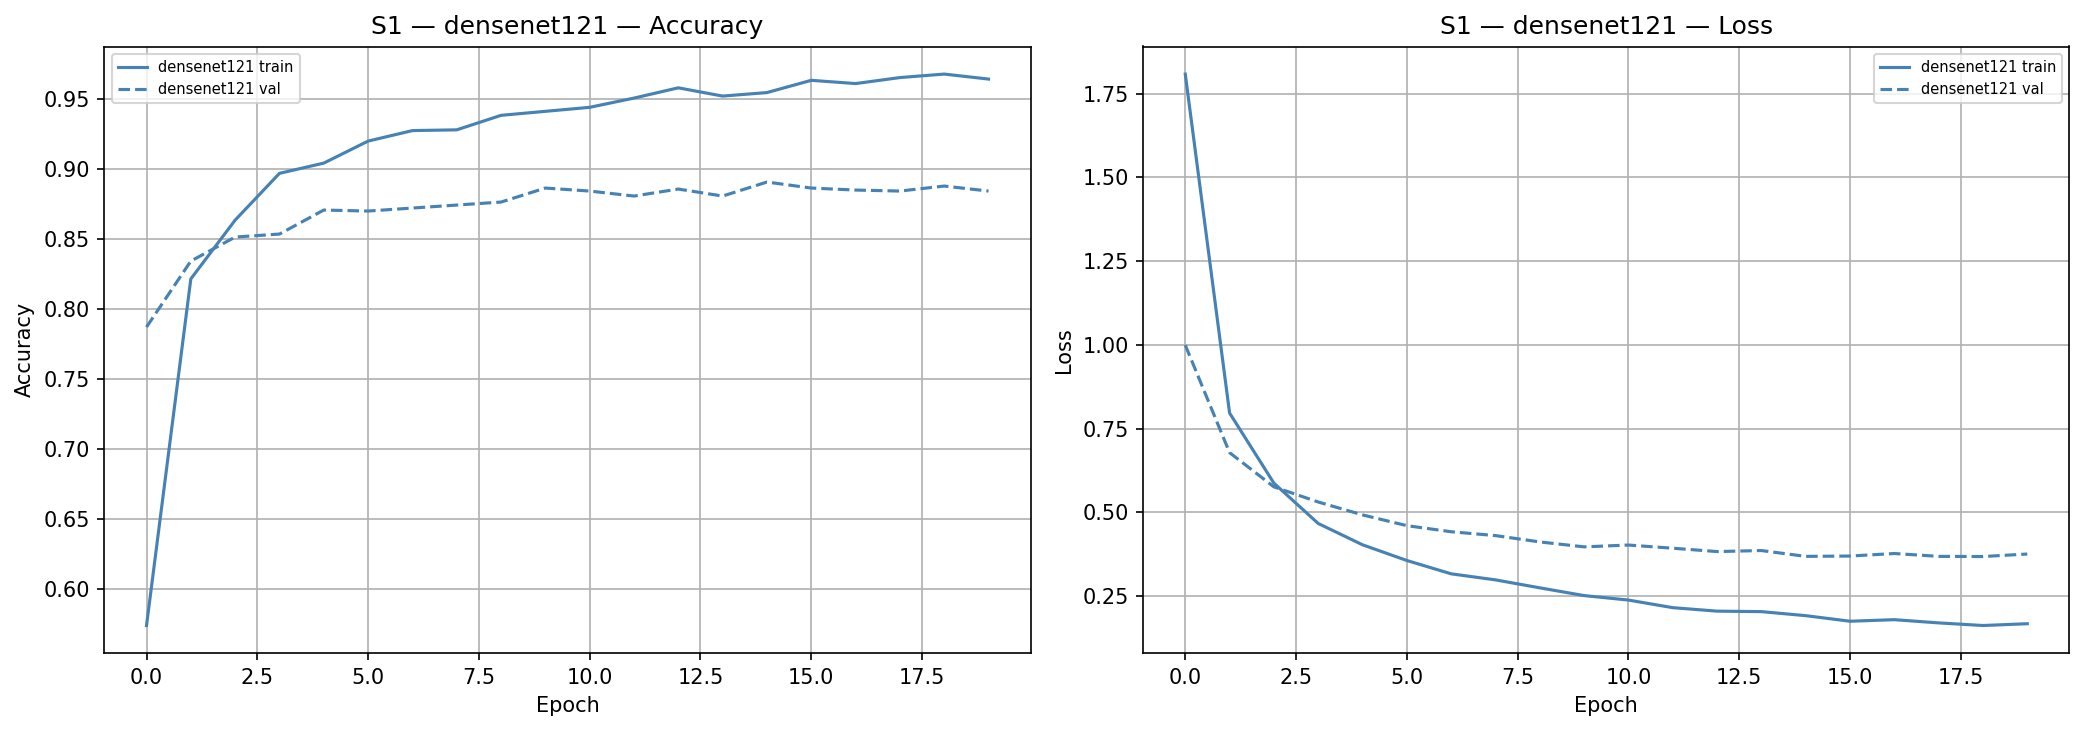

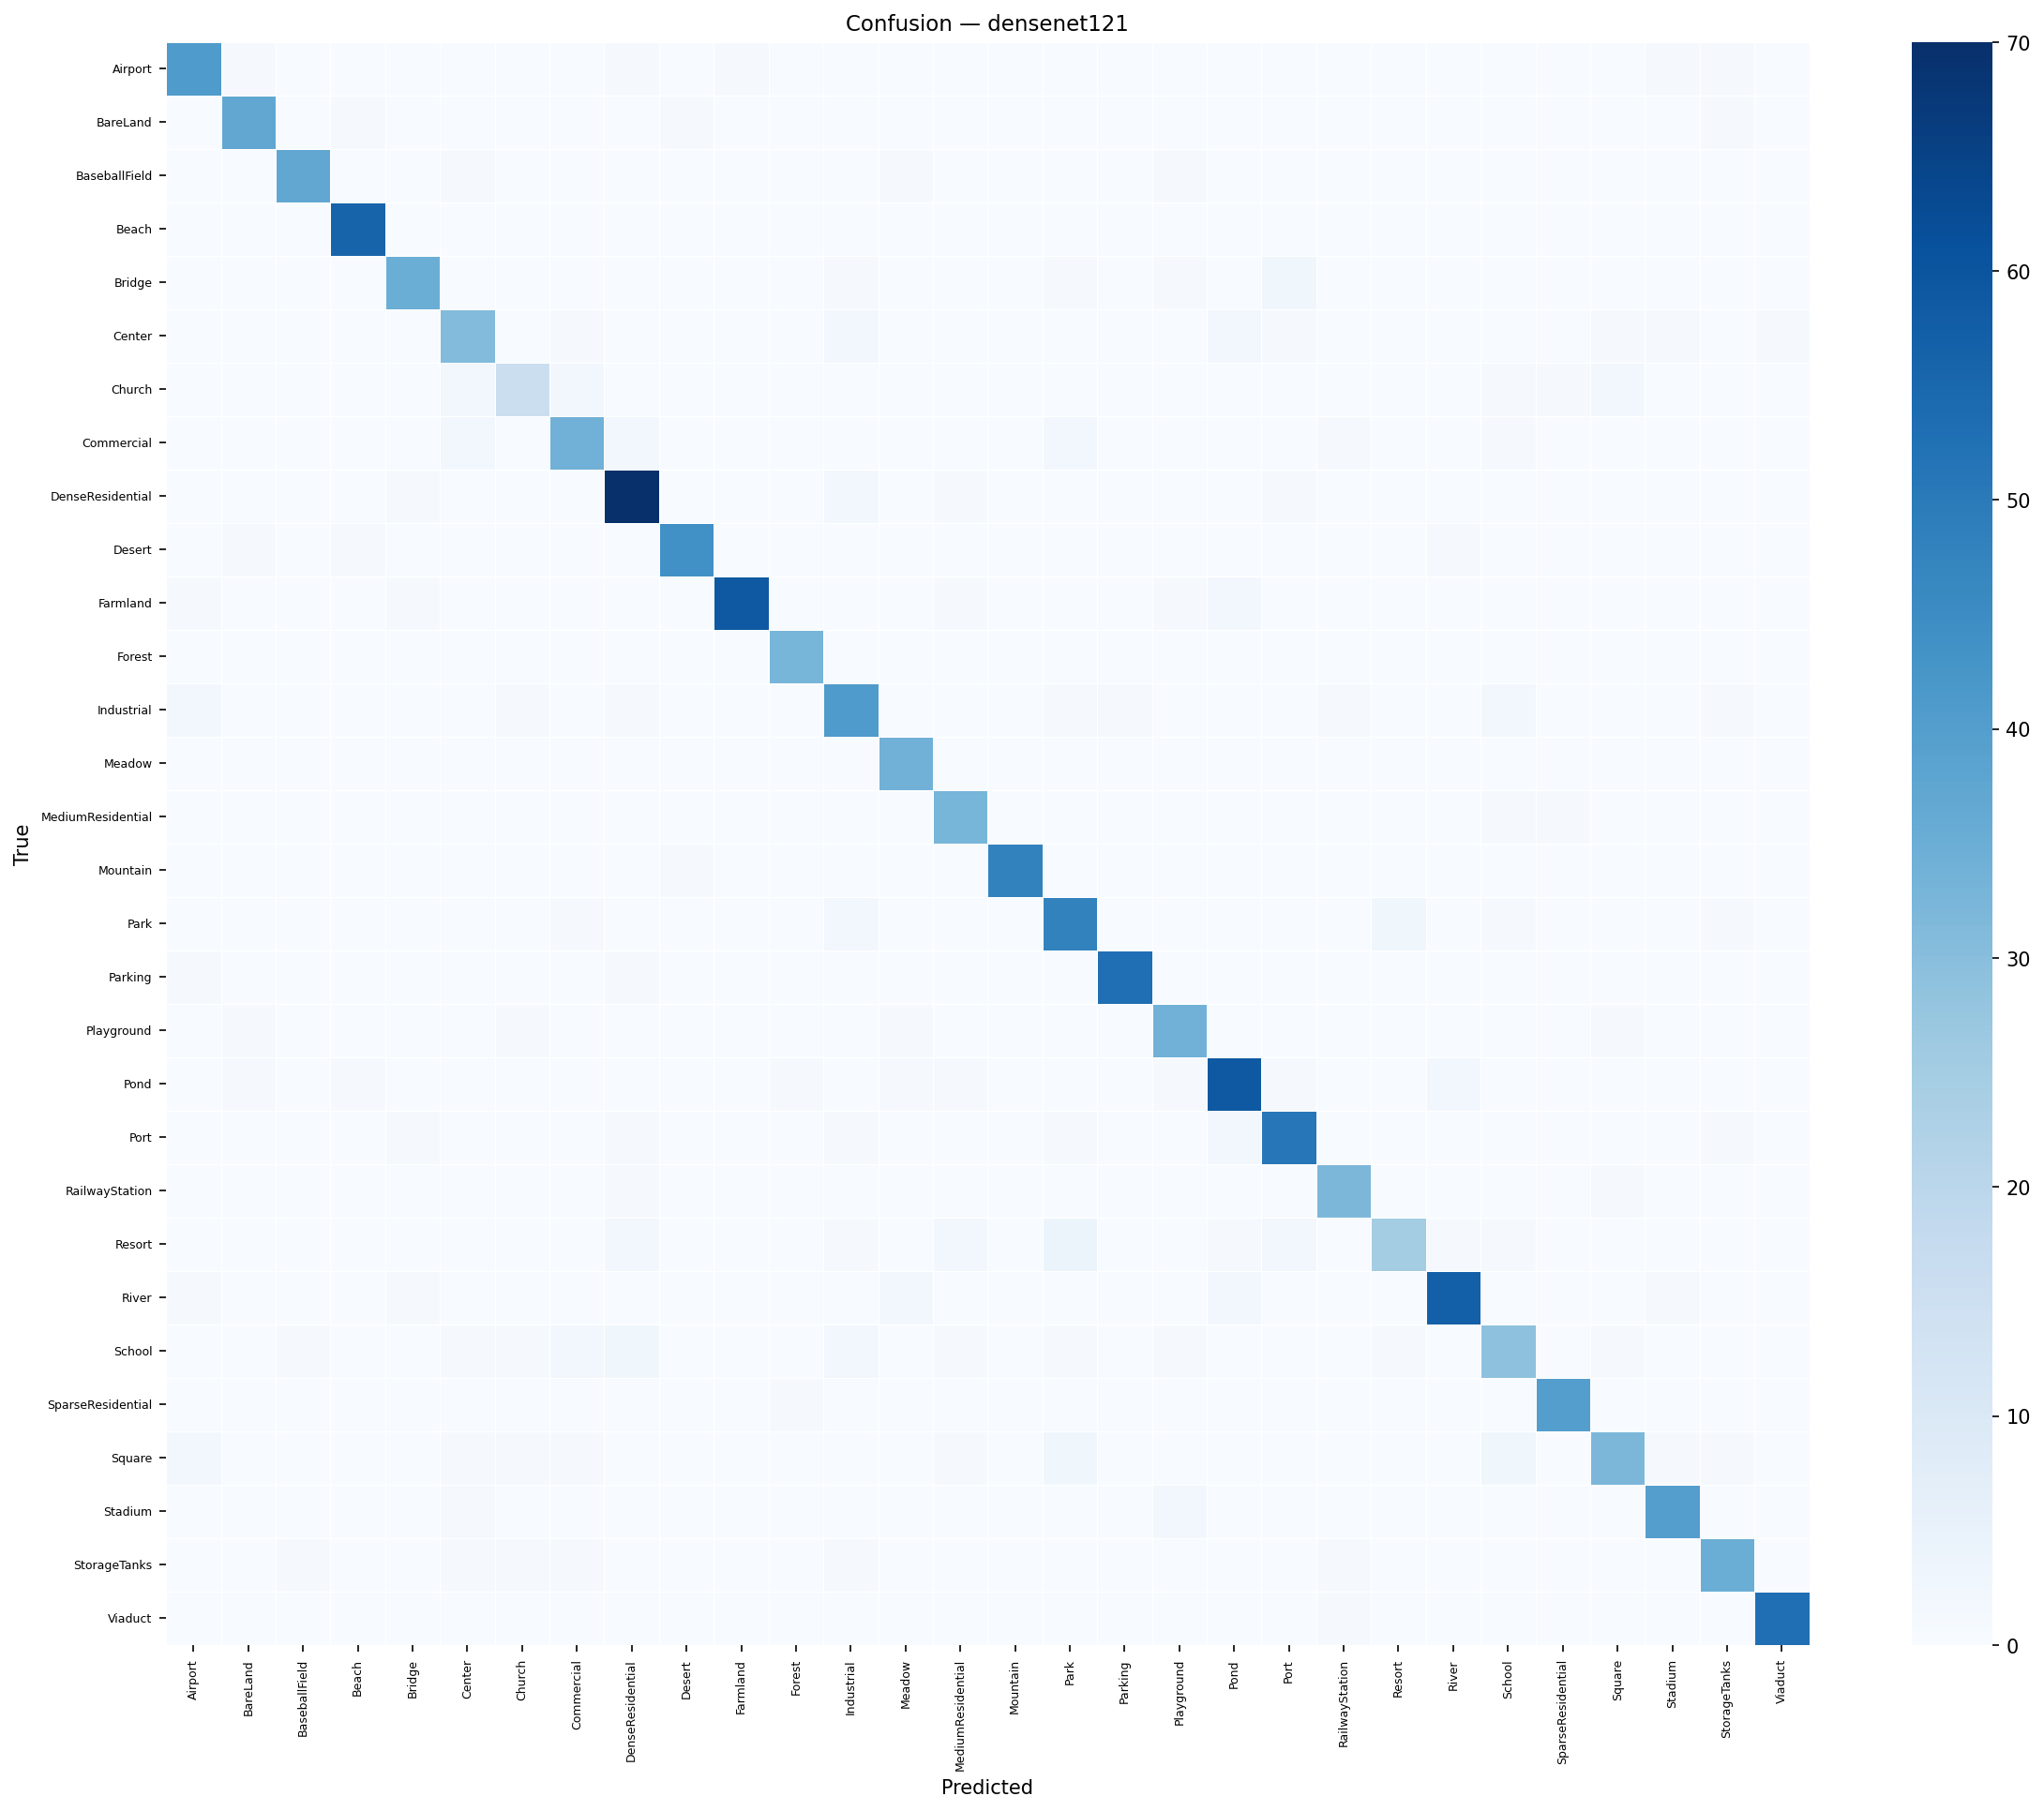

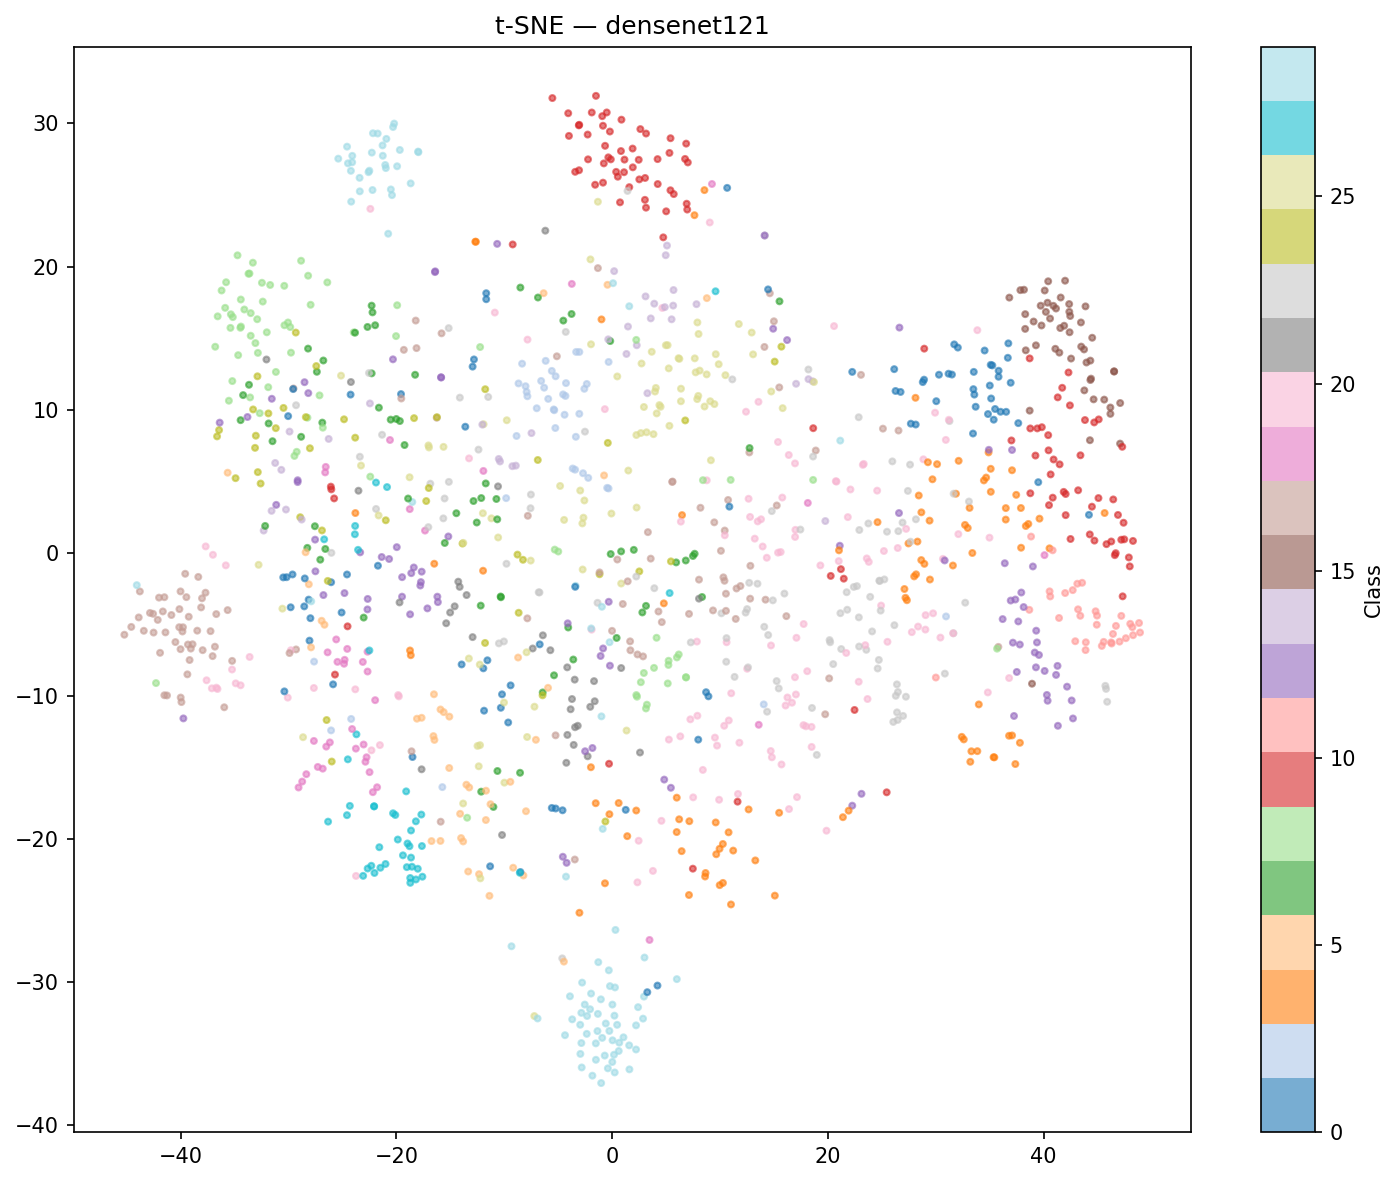

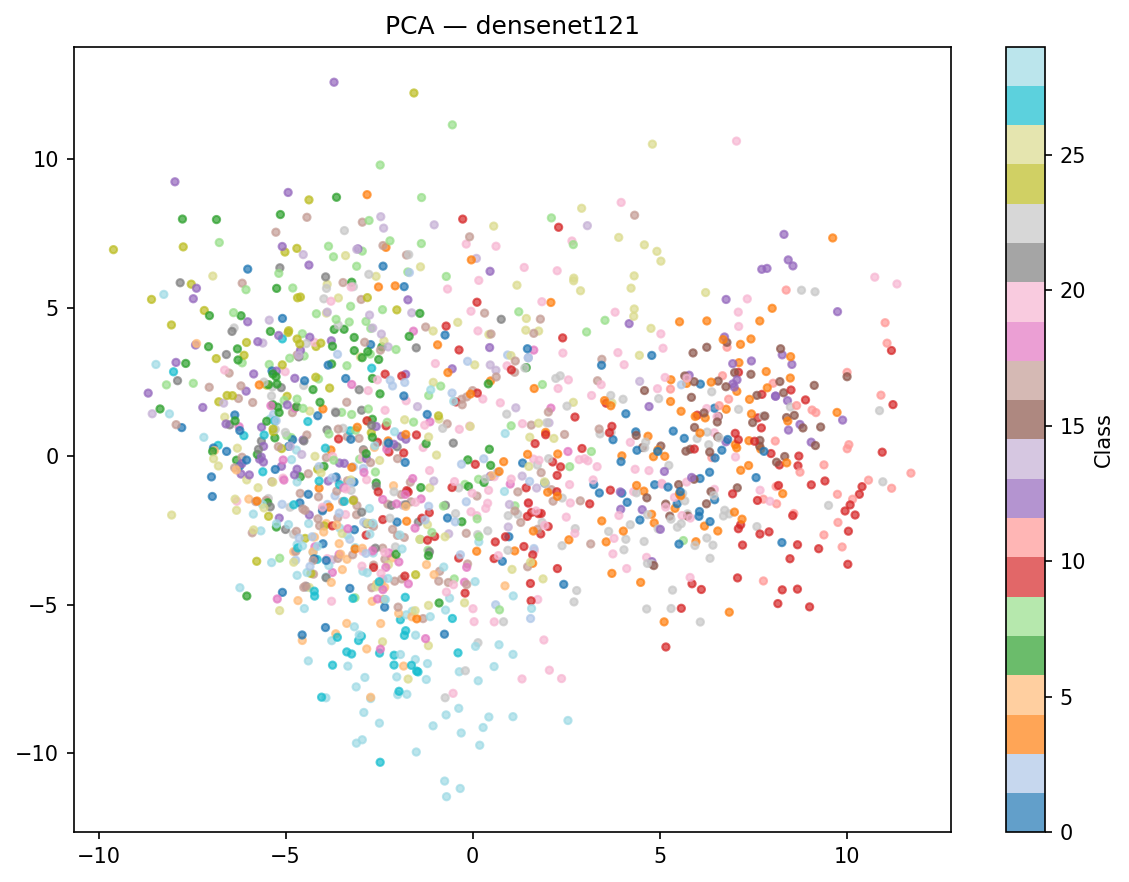


  S1 — densenet121
      model  val_acc  total_params  trainable_params  MACs_G  FLOPs_G
densenet121   0.8842       6984606             30750   2.833    5.667


model,val_acc,total_params,trainable_params,MACs_G,FLOPs_G
densenet121,0.8842,6984606,30750,2.833,5.667


  ✔  S1/densenet121 — 31.5 min

  S2 Fine-Tuning — densenet121
  linear_probe reused from S1 val=0.8842

  strategy=last_block
     Efficiency [densenet121/last_block]
       Total params    : 6,984,606
       Trainable params: 2,190,878 (31.4%)
       MACs            : 2.833 G
       FLOPs (2xMACs)  : 5.667 G
    densenet121/last_block                 ep01/30 train=0.744 val=0.898
    densenet121/last_block                 ep02/30 train=0.925 val=0.921
    densenet121/last_block                 ep03/30 train=0.959 val=0.929
    densenet121/last_block                 ep04/30 train=0.973 val=0.926
    densenet121/last_block                 ep05/30 train=0.979 val=0.943
    densenet121/last_block                 ep06/30 train=0.981 val=0.935
    densenet121/last_block                 ep07/30 train=0.987 val=0.930
    densenet121/last_block                 ep08/30 train=0.988 val=0.931
    densenet121/last_block                 ep09/30 train=0.990 val=0.934
    densenet121/last_block     

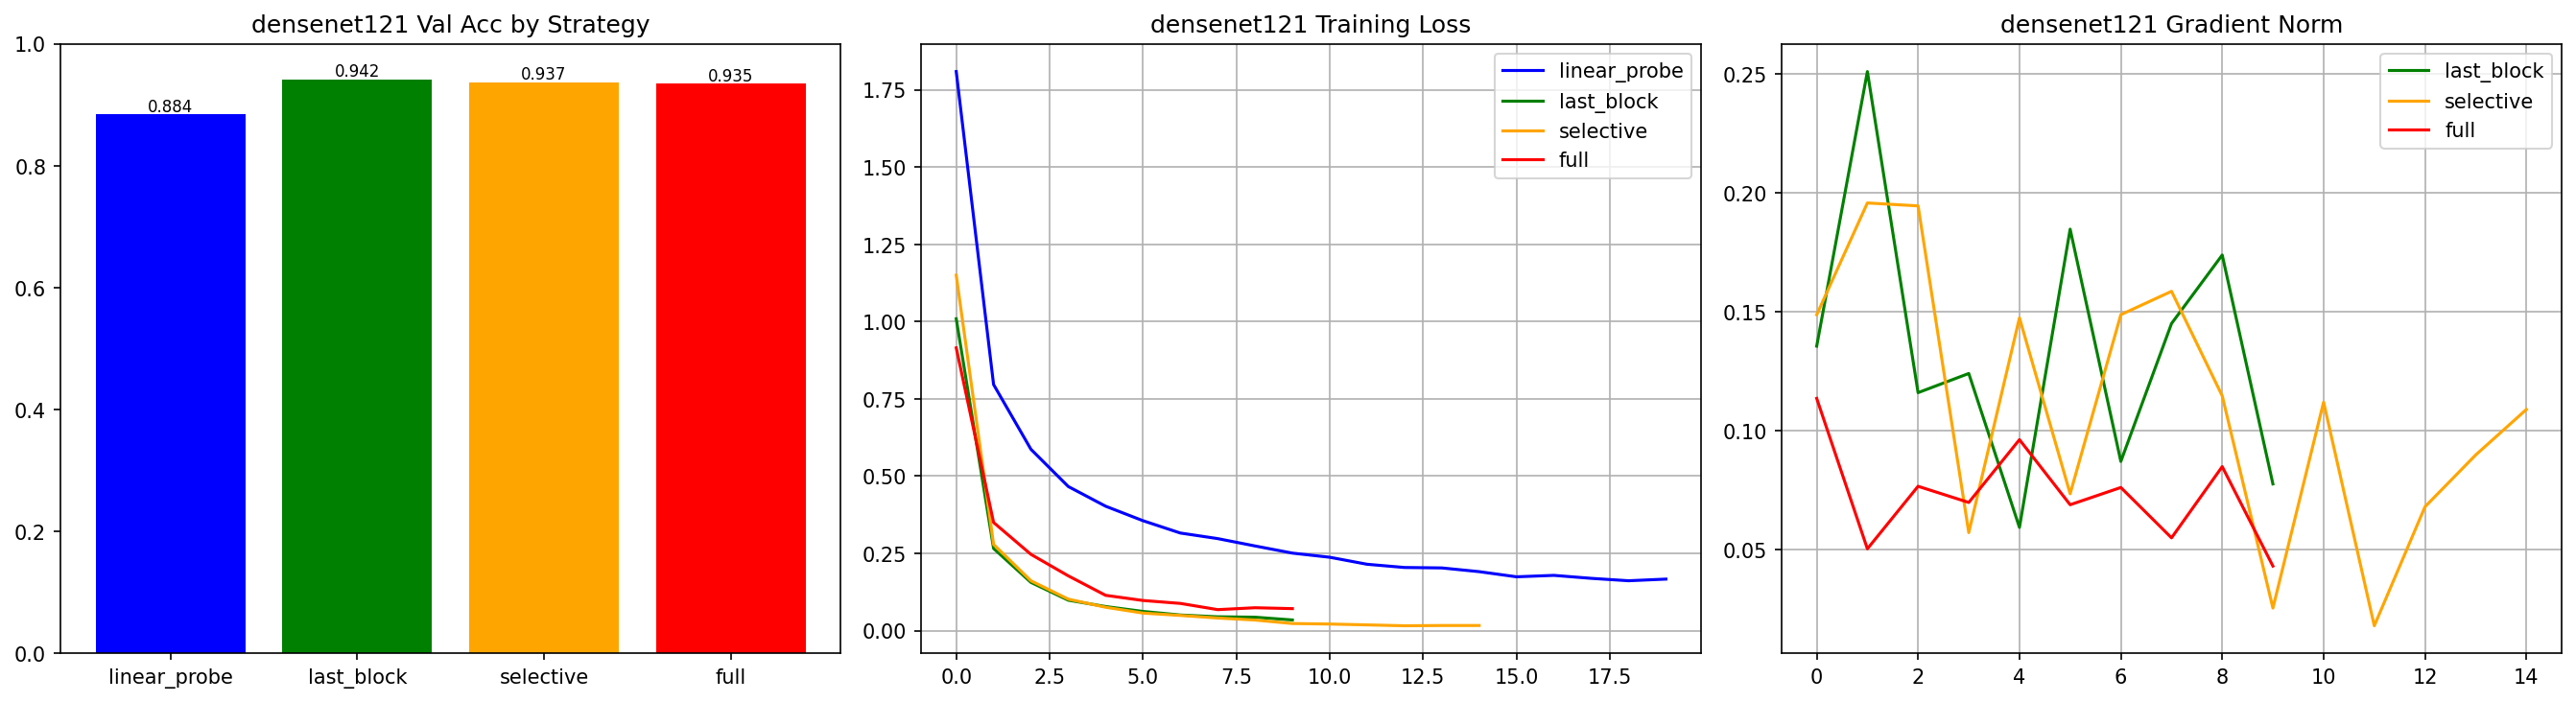

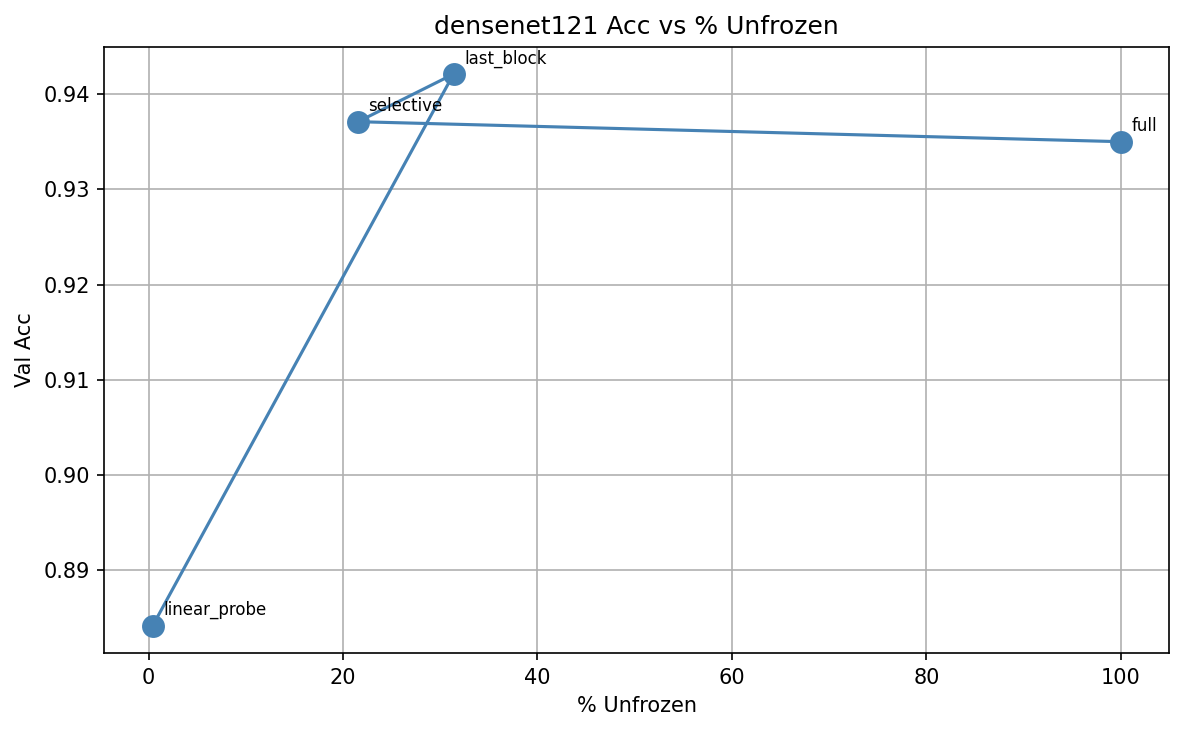


  S2 — densenet121
      model     strategy  val_acc  pct_unfrozen  trainable_params  MACs_G
densenet121 linear_probe   0.8842          0.44             30750   2.833
densenet121   last_block   0.9421         31.37           2190878   2.833
densenet121    selective   0.9371         21.55           1504990   2.833
densenet121         full   0.9350        100.00           6984606   2.833


model,strategy,val_acc,pct_unfrozen,trainable_params,MACs_G
densenet121,linear_probe,0.8842,0.44,30750,2.833
densenet121,last_block,0.9421,31.37,2190878,2.833
densenet121,selective,0.9371,21.55,1504990,2.833
densenet121,full,0.9350,100.00,6984606,2.833


  ✔  S2/densenet121 — 57.2 min

  S3 Few-Shot — densenet121
  100% reused from S2-full val=0.9350

  fraction=20%
    densenet121/20%                        ep01/20 train=0.483 val=0.731
    densenet121/20%                        ep02/20 train=0.860 val=0.806
    densenet121/20%                        ep03/20 train=0.903 val=0.830
    densenet121/20%                        ep04/20 train=0.929 val=0.812
    densenet121/20%                        ep05/20 train=0.965 val=0.848
    densenet121/20%                        ep06/20 train=0.948 val=0.833
    densenet121/20%                        ep07/20 train=0.954 val=0.854
    densenet121/20%                        ep08/20 train=0.979 val=0.884
    densenet121/20%                        ep09/20 train=0.979 val=0.875
    densenet121/20%                        ep10/20 train=0.985 val=0.887
    densenet121/20%                        ep11/20 train=0.989 val=0.886
    densenet121/20%                        ep12/20 train=0.994 val=0.894
    densen

    densenet121/5%                         ep01/20 train=0.204 val=0.335
    densenet121/5%                         ep02/20 train=0.753 val=0.540
    densenet121/5%                         ep03/20 train=0.939 val=0.582
    densenet121/5%                         ep04/20 train=0.950 val=0.675
    densenet121/5%                         ep05/20 train=0.978 val=0.726
    densenet121/5%                         ep06/20 train=0.996 val=0.716
    densenet121/5%                         ep07/20 train=0.978 val=0.740
    densenet121/5%                         ep08/20 train=0.996 val=0.763
    densenet121/5%                         ep09/20 train=0.982 val=0.762
    densenet121/5%                         ep10/20 train=0.993 val=0.742
    densenet121/5%                         ep11/20 train=0.993 val=0.768
    densenet121/5%                         ep12/20 train=0.993 val=0.766
    densenet121/5%                         ep13/20 train=0.989 val=0.758
    densenet121/5%                         ep14/20 

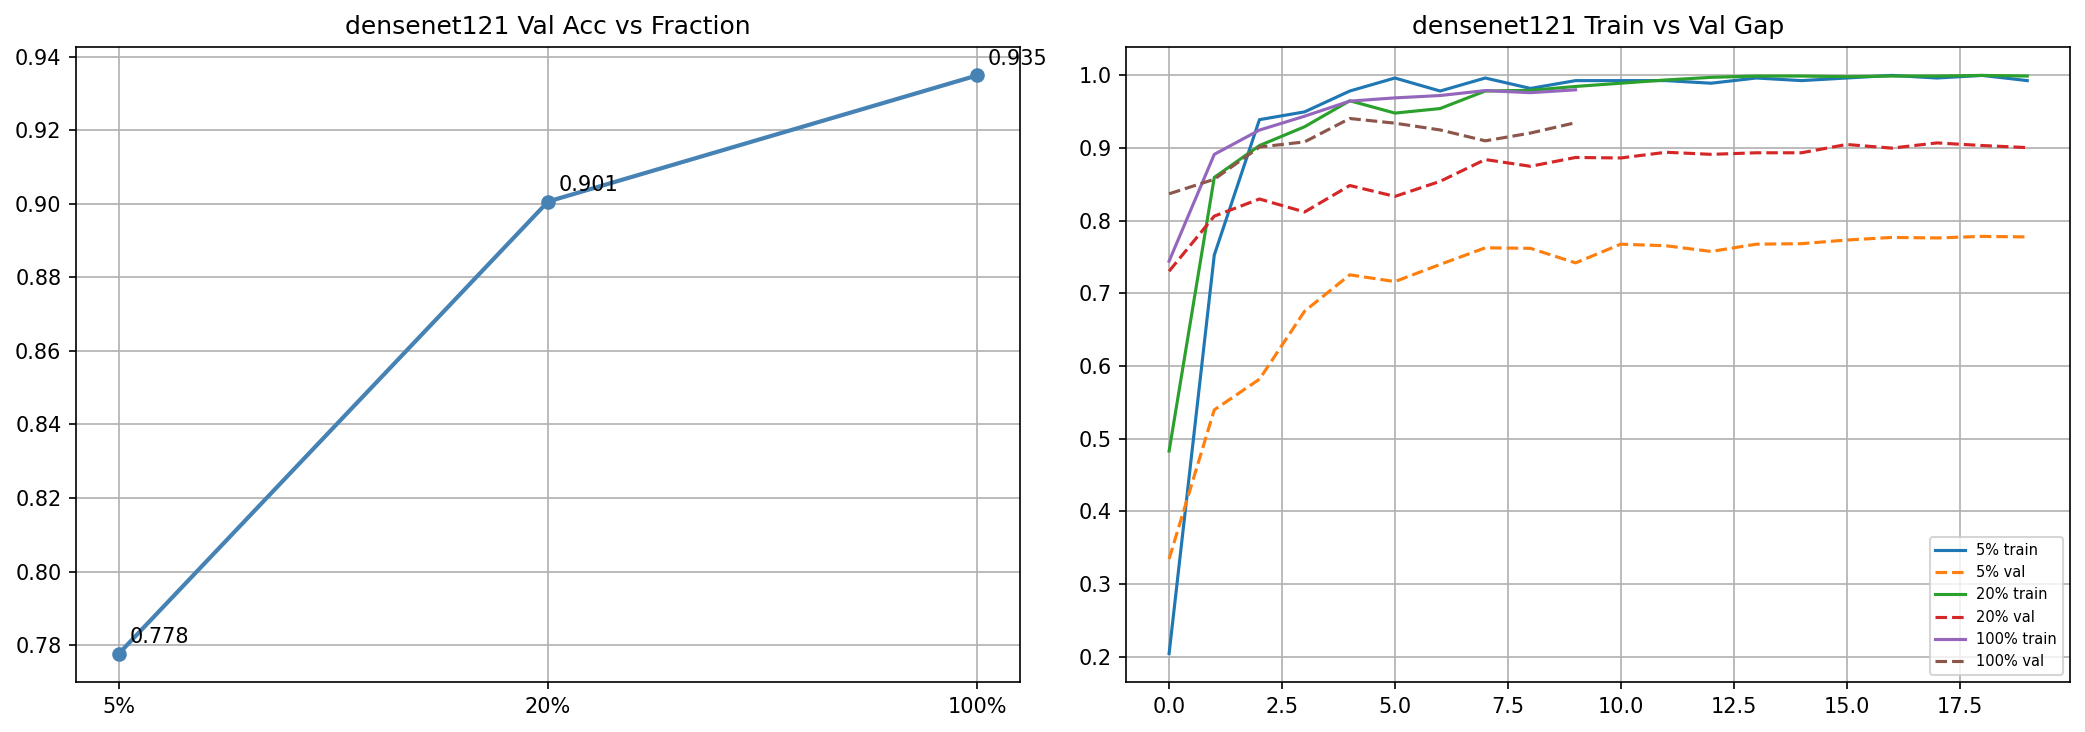


  S3 — densenet121
      model  fraction_pct  val_acc  train_acc  train_val_gap  relative_drop
densenet121           100   0.9350     0.9802         0.0452         0.1682
densenet121            20   0.9006     0.9991         0.0985         0.1682
densenet121             5   0.7777     0.9928         0.2151         0.1682


model,fraction_pct,val_acc,train_acc,train_val_gap,relative_drop
densenet121,100,0.9350,0.9802,0.0452,0.1682
densenet121,20,0.9006,0.9991,0.0985,0.1682
densenet121,5,0.7777,0.9928,0.2151,0.1682


  ✔  S3/densenet121 — 19.2 min

  S4 Corruption — densenet121
  Loaded S1 weights — no retraining
  Clean acc=0.8842
  GaussNoise_s0.05       acc=0.0693 err=0.9307 rr=0.0784
  GaussNoise_s0.10       acc=0.0307 err=0.9693 rr=0.0348
  GaussNoise_s0.20       acc=0.0279 err=0.9721 rr=0.0315
  MotionBlur             acc=0.3338 err=0.6662 rr=0.3775
  Brightness_x2          acc=0.7591 err=0.2409 rr=0.8585


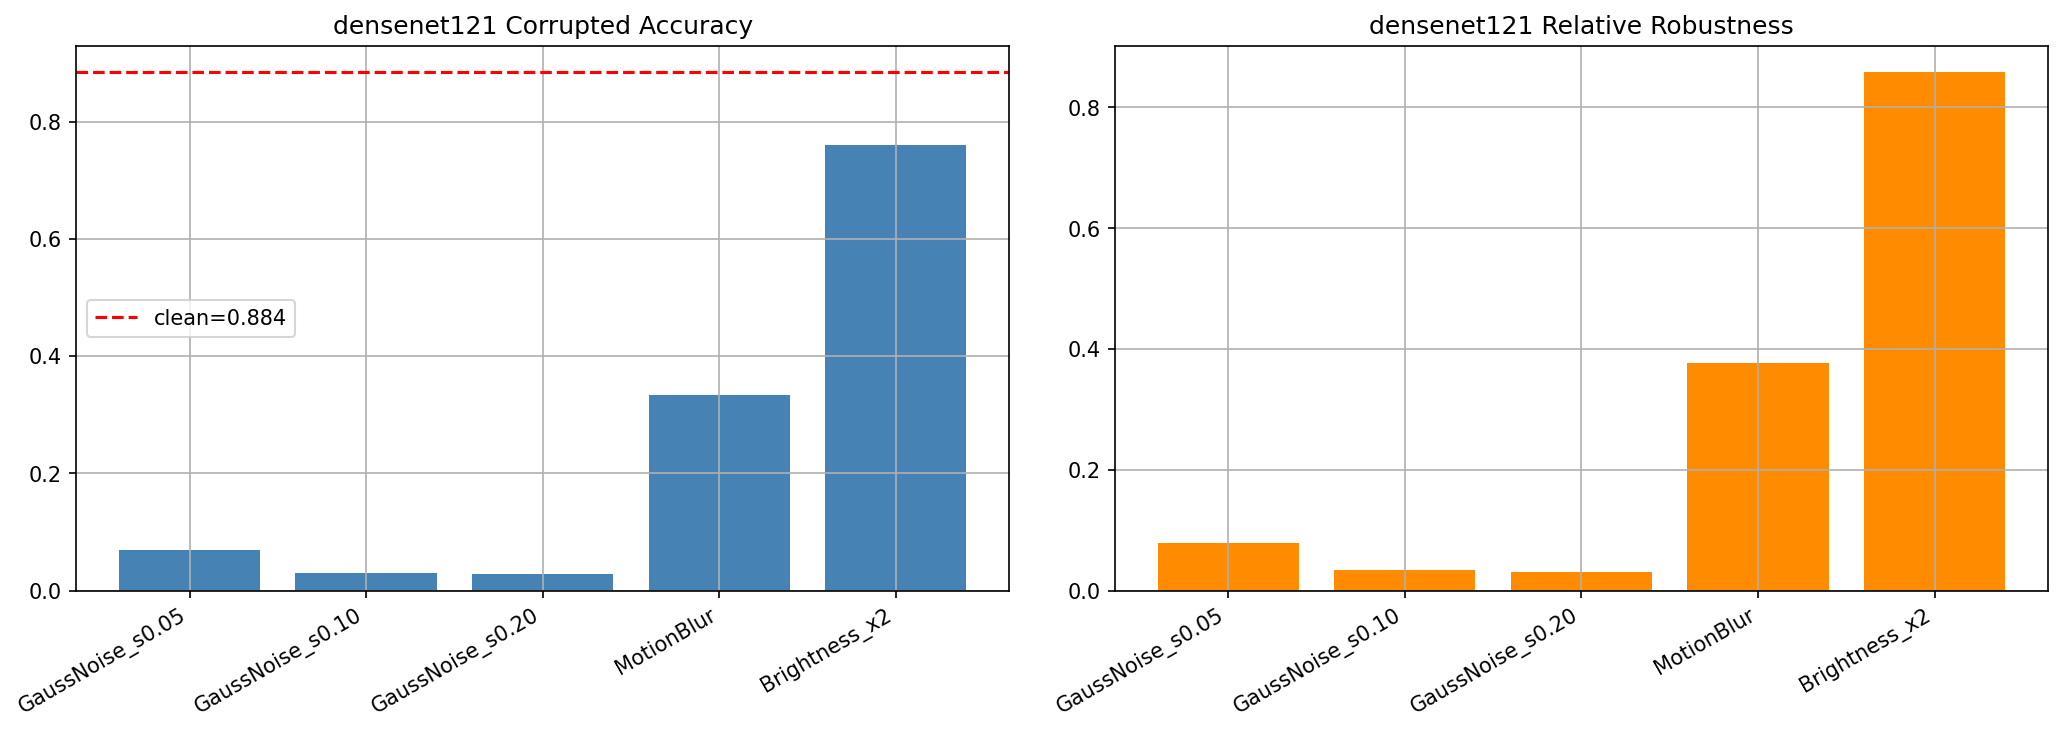


  S4 — densenet121
      model       corruption  clean_acc  corrupted_acc  corruption_error  relative_robustness
densenet121 GaussNoise_s0.05     0.8842         0.0693            0.9307               0.0784
densenet121 GaussNoise_s0.10     0.8842         0.0307            0.9693               0.0348
densenet121 GaussNoise_s0.20     0.8842         0.0279            0.9721               0.0315
densenet121       MotionBlur     0.8842         0.3338            0.6662               0.3775
densenet121    Brightness_x2     0.8842         0.7591            0.2409               0.8585


model,corruption,clean_acc,corrupted_acc,corruption_error,relative_robustness
densenet121,GaussNoise_s0.05,0.8842,0.0693,0.9307,0.0784
densenet121,GaussNoise_s0.10,0.8842,0.0307,0.9693,0.0348
densenet121,GaussNoise_s0.20,0.8842,0.0279,0.9721,0.0315
densenet121,MotionBlur,0.8842,0.3338,0.6662,0.3775
densenet121,Brightness_x2,0.8842,0.7591,0.2409,0.8585


  ✔  S4/densenet121 — 1.8 min

  S5 Layer Probing — densenet121
  Reusing S1 model — no retraining
  DB1_early    probe_acc=0.0000 norm=116.3


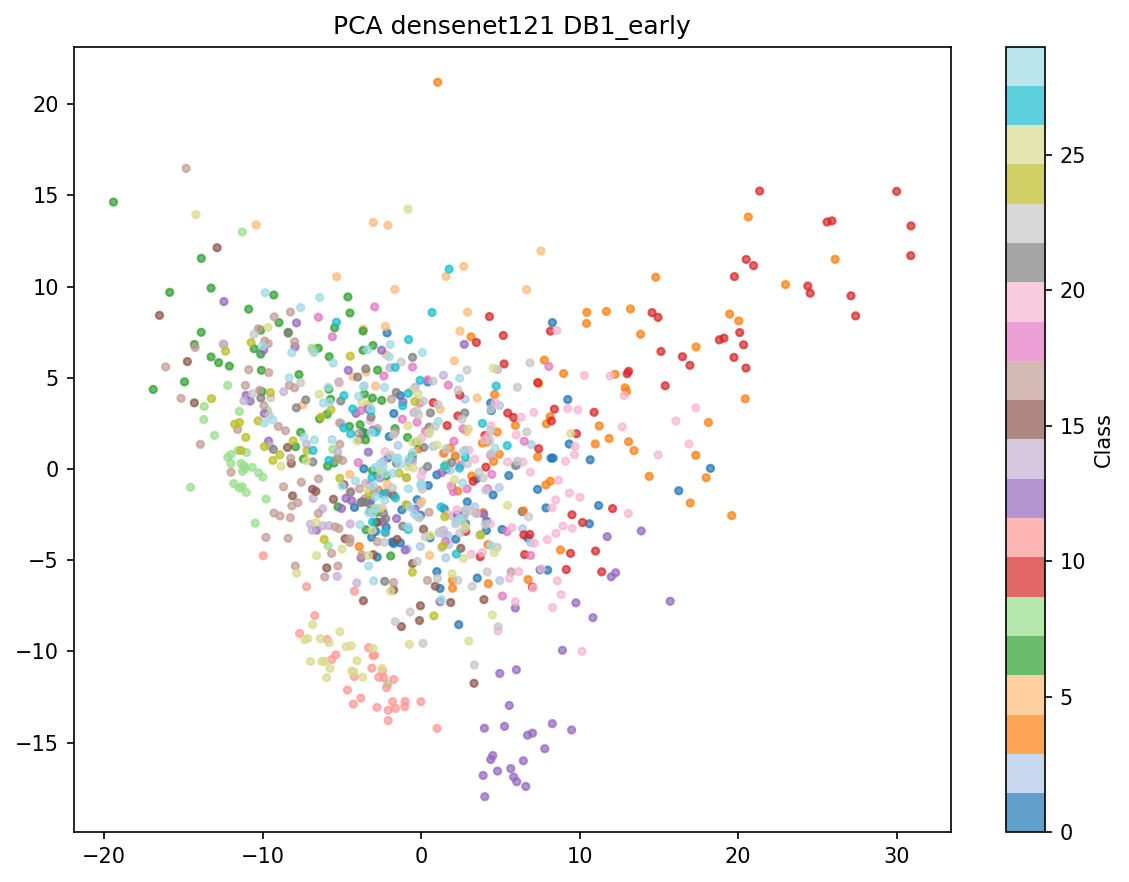

  DB2_mid      probe_acc=0.0000 norm=31.7


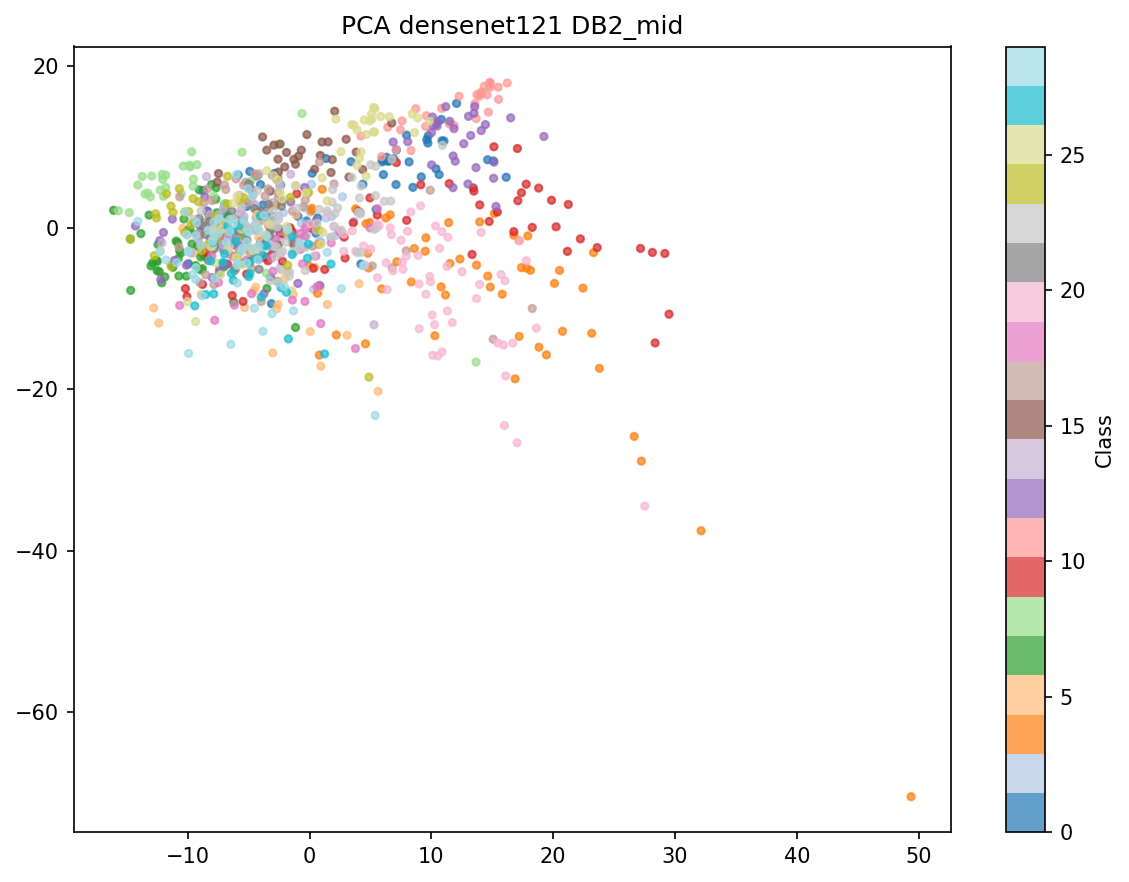

  DB3_deep     probe_acc=0.0000 norm=28.3


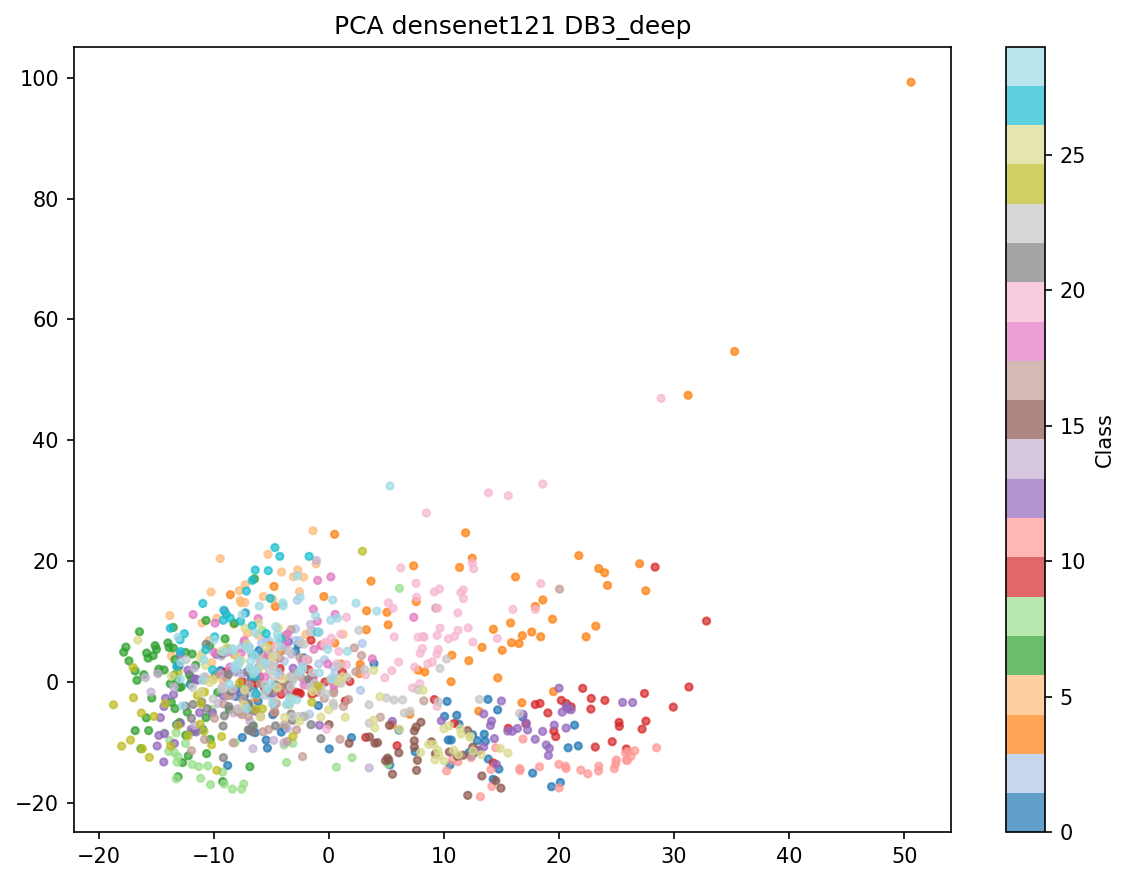

  DB4_final    probe_acc=0.0000 norm=28.7


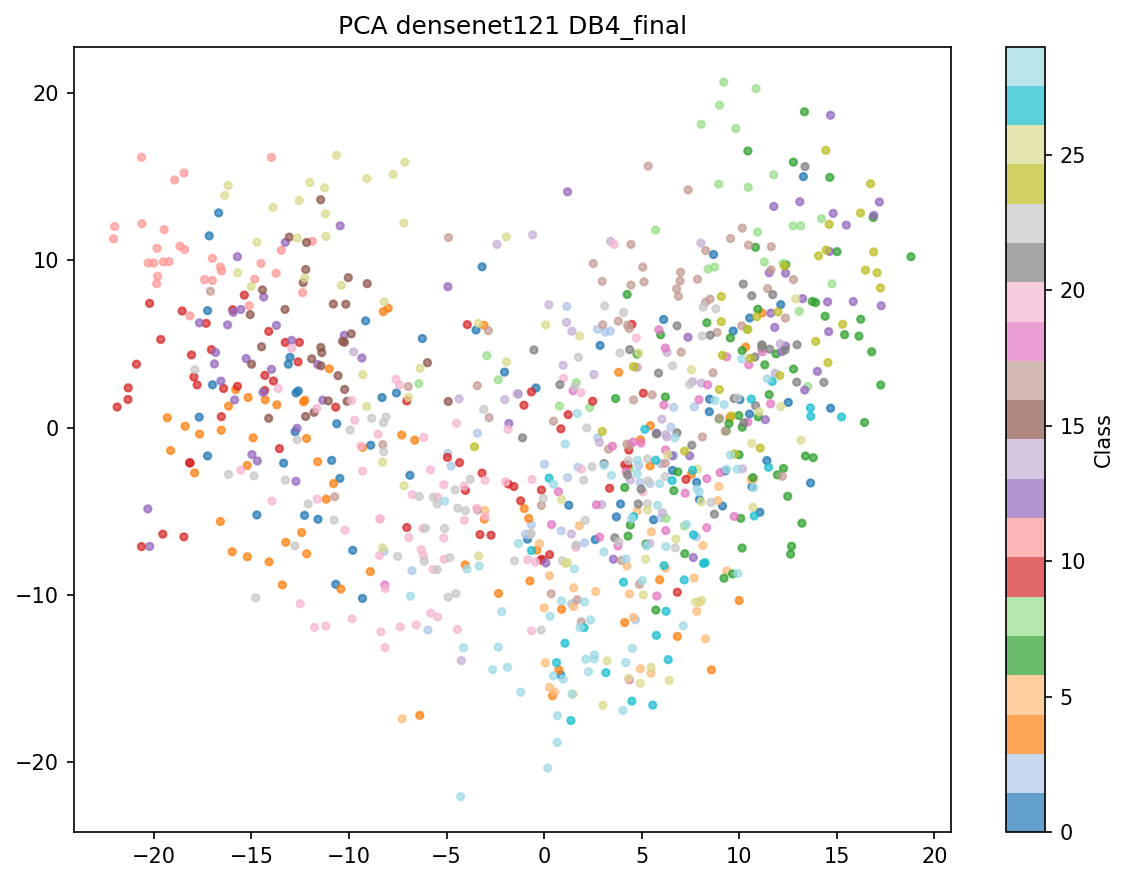

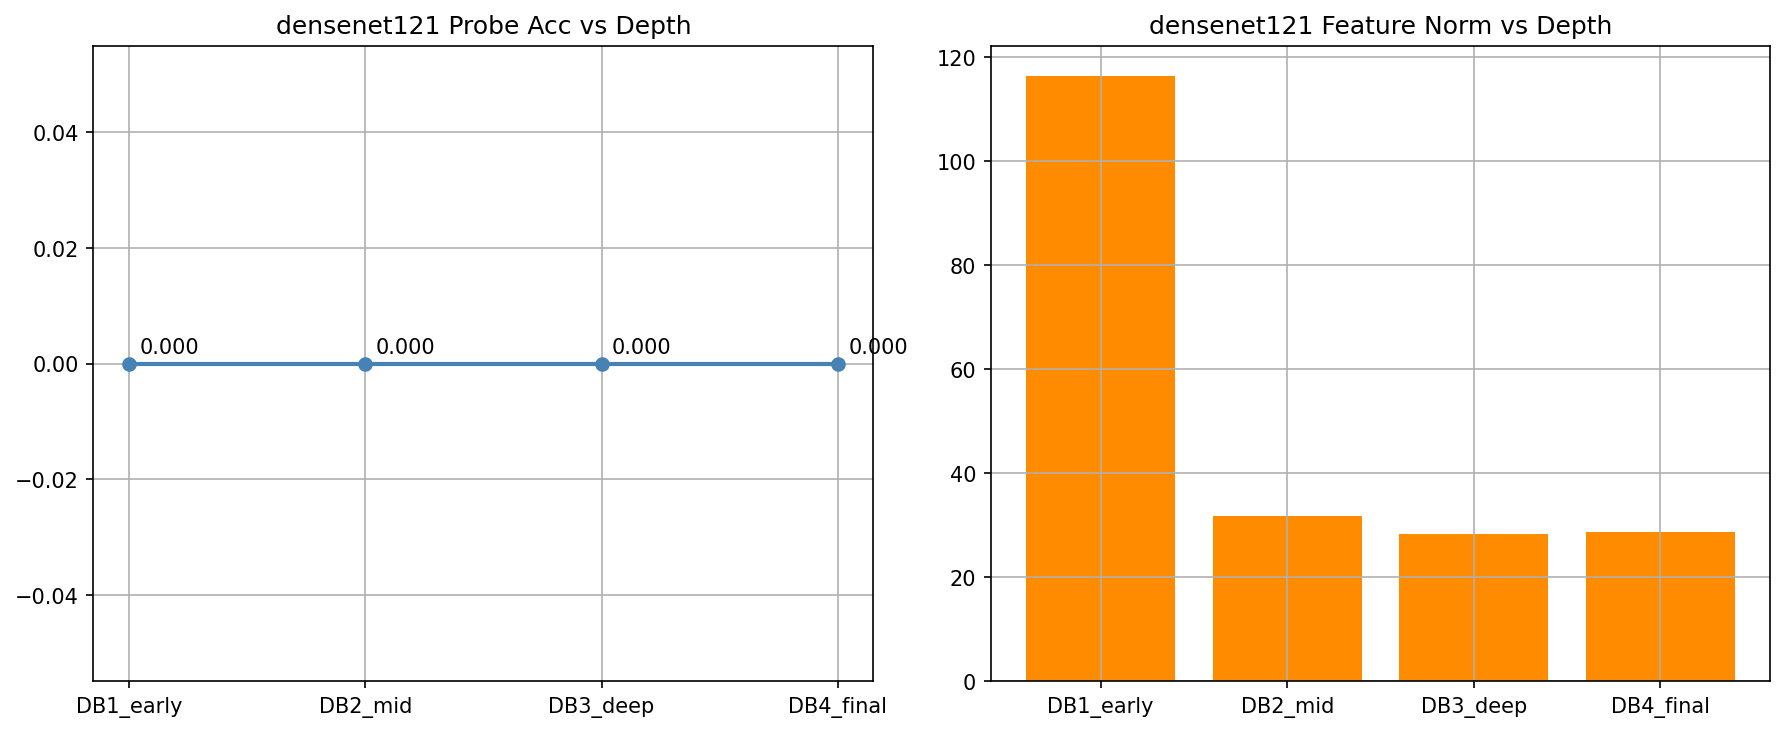


  S5 — densenet121
      model     layer  probe_acc  feat_norm  feat_dim
densenet121 DB1_early        0.0   116.3390       256
densenet121   DB2_mid        0.0    31.7011       512
densenet121  DB3_deep        0.0    28.2782      1024
densenet121 DB4_final        0.0    28.6595      1024


model,layer,probe_acc,feat_norm,feat_dim
densenet121,DB1_early,0.0,116.3390,256
densenet121,DB2_mid,0.0,31.7011,512
densenet121,DB3_deep,0.0,28.2782,1024
densenet121,DB4_final,0.0,28.6595,1024


  ✔  S5/densenet121 — 0.9 min

  BONUS Auto Layer Selection — densenet121
     Efficiency [densenet121/auto]
       Total params    : 6,984,606
       Trainable params: 1,427,550 (20.4%)
       MACs            : 2.833 G
       FLOPs (2xMACs)  : 5.667 G
    densenet121/auto                       ep01/20 train=0.061 val=0.174
    densenet121/auto                       ep02/20 train=0.437 val=0.328
    densenet121/auto                       ep03/20 train=0.670 val=0.429
    densenet121/auto                       ep04/20 train=0.814 val=0.496
    densenet121/auto                       ep05/20 train=0.796 val=0.575
    densenet121/auto                       ep06/20 train=0.910 val=0.640
    densenet121/auto                       ep07/20 train=0.932 val=0.687
    densenet121/auto                       ep08/20 train=0.961 val=0.710
    densenet121/auto                       ep09/20 train=0.975 val=0.714
    densenet121/auto                       ep10/20 train=0.971 val=0.729
    densenet121/a

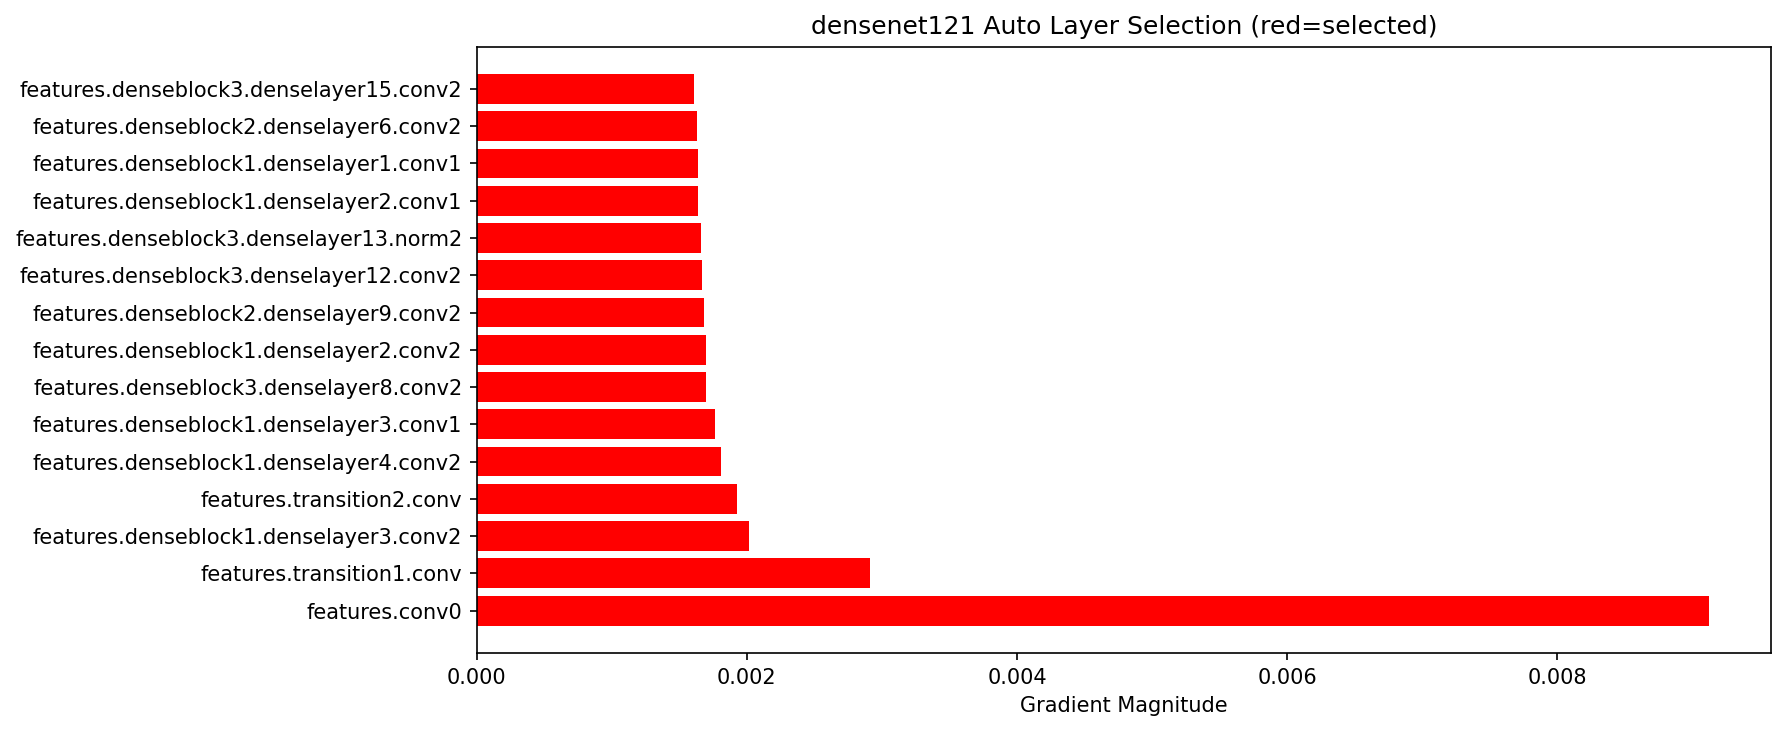

  65 layers=20.4% val=0.7362
  ✔  BONUS/densenet121 — 7.4 min

  🟢 DENSENET121 COMPLETE — 118.5 min
  S1=31.5m S2=57.2m S3=19.2m S4=1.8m S5=0.9m BONUS=7.4m


In [7]:
# CELL 9: 🟢 DENSENET121 — S1 S2 S3 S4 S5 BONUS
# Optimised: S1 reused in S2+S5 | S2-full reused in S3 | S4 eval only
# Early stopping cuts each run short when val acc plateaus

_mn   = "densenet121"
_tstart = time.time()
_outm = Path(OUTPUT_DIR)/"densenet121"; _outm.mkdir(exist_ok=True)
_crit = nn.CrossEntropyLoss()
_tl,_vl = get_loaders(data_root,train_idx,val_idx)

print(f"\n=================================================================")
print(f"  🟢  {_mn.upper()} — starting")
print(f"=================================================================")

# S1: Linear Probe ════════════════════════════════════════
section(f"S1 Linear Probe — {_mn}")
_t0=time.time()
_os1=_outm/"S1_LinearProbe"; _os1.mkdir(exist_ok=True)
_m1=build_model(_mn,"linear_probe")
_tot1,_trn1,_mac1=print_efficiency(f"{_mn}/linear_probe",_m1)
_h1,_=train_full(_m1,_tl,_vl,FULL_EPOCHS,label=f"{_mn}/linear_probe")
_,_va1,_pr1,_lb1=eval_epoch(_m1,_vl,_crit)
plot_curves({_mn:_h1},f"S1 — {_mn}",str(_os1/"curves.png"))
plot_confusion(_lb1,_pr1,classes,f"Confusion — {_mn}",str(_os1/"cm.png"))
_feats1,_flbls1=extract_penultimate(_m1,_vl)
plot_tsne(_feats1,_flbls1,f"t-SNE — {_mn}",str(_os1/"tsne.png"))
plot_pca2d(_feats1,_flbls1,f"PCA — {_mn}",str(_os1/"pca.png"))
torch.save(_m1.state_dict(),str(_os1/"weights.pt"))
_r1=dict(model=_mn,val_acc=round(_va1,4),total_params=_tot1,
         trainable_params=_trn1,MACs_G=round(_mac1/1e9,3),
         FLOPs_G=round(_mac1*2/1e9,3))
all_s1.append(_r1)
show_table(pd.DataFrame([_r1]),f"S1 — {_mn}")
pd.DataFrame([_r1]).to_csv(str(_os1/"result.csv"),index=False)
_ts1=time.time()-_t0; done(f"S1/{_mn}",_ts1)

# S2: Fine-Tuning Strategies ══════════════════════════════
section(f"S2 Fine-Tuning — {_mn}")
_t0=time.time()
_os2=_outm/"S2_FineTuning"; _os2.mkdir(exist_ok=True)
_sc=dict(linear_probe="blue",last_block="green",selective="orange",full="red")
_sh={"linear_probe":_h1}; _sg={"linear_probe":[]}
_ss={"linear_probe":dict(val_acc=round(_va1,4),pct=round(_trn1/_tot1*100,2))}
all_s2.append(dict(model=_mn,strategy="linear_probe",val_acc=round(_va1,4),
                   pct_unfrozen=round(_trn1/_tot1*100,2),trainable_params=_trn1,
                   MACs_G=round(_mac1/1e9,3)))
L(f"  linear_probe reused from S1 val={_va1:.4f}")

for _strat in ["last_block","selective","full"]:
    L(f"\n  strategy={_strat}")
    _ms=build_model(_mn,_strat)
    _tot2,_trn2,_mac2=print_efficiency(f"{_mn}/{_strat}",_ms)
    _hs,_gns=train_full(_ms,_tl,_vl,FULL_EPOCHS,label=f"{_mn}/{_strat}")
    _,_va2,_,_=eval_epoch(_ms,_vl,_crit)
    _sh[_strat]=_hs; _sg[_strat]=_gns
    _ss[_strat]=dict(val_acc=round(_va2,4),pct=round(_trn2/_tot2*100,2))
    all_s2.append(dict(model=_mn,strategy=_strat,val_acc=round(_va2,4),
                       pct_unfrozen=round(_trn2/_tot2*100,2),trainable_params=_trn2,
                       MACs_G=round(_mac2/1e9,3)))
    if _strat=="full": _m_full=_ms; _va_full=_va2; _h_full=_hs
    L(f"  val={_va2:.4f} unfrozen={_trn2/_tot2*100:.1f}%")

_stords=["linear_probe","last_block","selective","full"]
_accs=[_ss[s]["val_acc"] for s in _stords]
_pcts=[_ss[s]["pct"] for s in _stords]
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].bar(_stords,_accs,color=[_sc[s] for s in _stords])
[axes[0].text(i,a+0.005,f"{a:.3f}",ha="center",fontsize=8)
 for i,(s,a) in enumerate(zip(_stords,_accs))]
axes[0].set_title(f"{_mn} Val Acc by Strategy"); axes[0].set_ylim(0,1)
[axes[1].plot(h["train_loss"],label=s,color=_sc[s]) for s,h in _sh.items() if h]
axes[1].set_title(f"{_mn} Training Loss"); axes[1].legend(); axes[1].grid(True)
[axes[2].plot(gn,label=s,color=_sc[s]) for s,gn in _sg.items() if gn]
axes[2].set_title(f"{_mn} Gradient Norm"); axes[2].legend(); axes[2].grid(True)
savefig(str(_os2/"strategies.png"))
plt.figure(figsize=(8,5))
plt.plot(_pcts,_accs,"o-",color="steelblue",markersize=10)
[plt.annotate(s,(p,a),textcoords="offset points",xytext=(5,5),fontsize=8)
 for s,p,a in zip(_stords,_pcts,_accs)]
plt.xlabel("% Unfrozen"); plt.ylabel("Val Acc")
plt.title(f"{_mn} Acc vs % Unfrozen"); plt.grid(True)
savefig(str(_os2/"acc_vs_unfrozen.png"))
_df2m=pd.DataFrame([r for r in all_s2 if r["model"]==_mn])
show_table(_df2m,f"S2 — {_mn}")
_df2m.to_csv(str(_os2/"result.csv"),index=False)
_ts2=time.time()-_t0; done(f"S2/{_mn}",_ts2)

# S3: Few-Shot ════════════════════════════════════════════
section(f"S3 Few-Shot — {_mn}")
_t0=time.time()
_os3=_outm/"S3_FewShot"; _os3.mkdir(exist_ok=True)
_at={1.0:_va_full}; _hfs={1.0:_h_full}
all_s3.append(dict(model=_mn,fraction_pct=100,val_acc=round(_va_full,4),
                   train_acc=round(_h_full["train_acc"][-1],4),
                   train_val_gap=round(_h_full["train_acc"][-1]-_va_full,4)))
L(f"  100% reused from S2-full val={_va_full:.4f}")
for _fr in [0.20,0.05]:
    L(f"\n  fraction={_fr*100:.0f}%")
    _tlf,_vlf=get_loaders(data_root,train_idx,val_idx,subset_frac=_fr)
    _mf=build_model(_mn,"full")
    _hf,_=train_full(_mf,_tlf,_vlf,FEW_SHOT_EPOCHS,label=f"{_mn}/{_fr*100:.0f}%")
    _,_vaf,_,_=eval_epoch(_mf,_vlf,_crit)
    _taf=_hf["train_acc"][-1]; _gap=_taf-_vaf
    _at[_fr]=_vaf; _hfs[_fr]=_hf
    all_s3.append(dict(model=_mn,fraction_pct=int(_fr*100),val_acc=round(_vaf,4),
                       train_acc=round(_taf,4),train_val_gap=round(_gap,4)))
    L(f"  val={_vaf:.4f} gap={_gap:.4f}")
_rdrop=round((_at[1.0]-_at[0.05])/_at[1.0],4) if _at[1.0]>0 else 0.
for _r in all_s3:
    if _r["model"]==_mn: _r["relative_drop"]=_rdrop
fig,axes=plt.subplots(1,2,figsize=(14,5))
_fls=["5%","20%","100%"]; _fas=[_at[f] for f in [0.05,0.20,1.0]]
axes[0].plot(_fls,_fas,marker="o",color="steelblue",linewidth=2)
[axes[0].annotate(f"{a:.3f}",(i,a),textcoords="offset points",xytext=(5,5))
 for i,(l,a) in enumerate(zip(_fls,_fas))]
axes[0].set_title(f"{_mn} Val Acc vs Fraction"); axes[0].grid(True)
for _fr in [0.05,0.20,1.0]:
    axes[1].plot(_hfs[_fr]["train_acc"],ls="-",label=f"{_fr*100:.0f}% train")
    axes[1].plot(_hfs[_fr]["val_acc"],  ls="--",label=f"{_fr*100:.0f}% val")
axes[1].set_title(f"{_mn} Train vs Val Gap"); axes[1].legend(fontsize=7); axes[1].grid(True)
savefig(str(_os3/"few_shot.png"))
_df3m=pd.DataFrame([r for r in all_s3 if r["model"]==_mn])
show_table(_df3m,f"S3 — {_mn}")
_df3m.to_csv(str(_os3/"result.csv"),index=False)
_ts3=time.time()-_t0; done(f"S3/{_mn}",_ts3)

# S4: Corruption ══════════════════════════════════════════
section(f"S4 Corruption — {_mn}")
_t0=time.time()
_os4=_outm/"S4_Corruption"; _os4.mkdir(exist_ok=True)
_m4=build_model(_mn,"full")
_m4.load_state_dict(torch.load(str(_os1/"weights.pt"),
                               map_location=DEVICE,weights_only=False),strict=False)
L("  Loaded S1 weights — no retraining")
_,_vlc=get_loaders(data_root,train_idx,val_idx)
_,_cacc,_,_=eval_epoch(_m4,_vlc,_crit)
L(f"  Clean acc={_cacc:.4f}")
for _kind,_sev,_lbl in CORRUPTIONS:
    _,_cl=get_loaders(data_root,train_idx,val_idx,
                      val_transform=corruption_tf(_kind,_sev))
    _,_ca,_,_=eval_epoch(_m4,_cl,_crit)
    _err=round(1-_ca,4); _rr=round(_ca/_cacc,4) if _cacc>0 else 0.
    all_s4.append(dict(model=_mn,corruption=_lbl,clean_acc=round(_cacc,4),
                       corrupted_acc=round(_ca,4),corruption_error=_err,
                       relative_robustness=_rr))
    L(f"  {_lbl:22s} acc={_ca:.4f} err={_err:.4f} rr={_rr:.4f}")
_df4m=pd.DataFrame([r for r in all_s4 if r["model"]==_mn])
_clbls=[c[2] for c in CORRUPTIONS]
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].bar(range(len(_clbls)),_df4m["corrupted_acc"],color="steelblue")
axes[0].axhline(_cacc,color="red",ls="--",label=f"clean={_cacc:.3f}")
axes[0].set_xticks(range(len(_clbls))); axes[0].set_xticklabels(_clbls,rotation=30,ha="right")
axes[0].set_title(f"{_mn} Corrupted Accuracy"); axes[0].legend(); axes[0].grid(True)
axes[1].bar(range(len(_clbls)),_df4m["relative_robustness"],color="darkorange")
axes[1].set_xticks(range(len(_clbls))); axes[1].set_xticklabels(_clbls,rotation=30,ha="right")
axes[1].set_title(f"{_mn} Relative Robustness"); axes[1].grid(True)
savefig(str(_os4/"corruption.png"))
show_table(_df4m,f"S4 — {_mn}")
_df4m.to_csv(str(_os4/"result.csv"),index=False)
_ts4=time.time()-_t0; done(f"S4/{_mn}",_ts4)

# S5: Layer Probing ═══════════════════════════════════════
section(f"S5 Layer Probing — {_mn}")
_t0=time.time()
_os5=_outm/"S5_LayerProbing"; _os5.mkdir(exist_ok=True)
_m5=_m1; _m5.eval()
L("  Reusing S1 model — no retraining")
_lmap=get_layer_map(_m5,_mn); _daccs=[]; _dnorms=[]; _llbls=list(_lmap.keys())
for _dl,_mod in _lmap.items():
    _hkst={}
    def _hkfn(mod,inp,out,_st=_hkst):
        f=out.detach().cpu()
        _st["f"]=f.mean(dim=[2,3]) if f.dim()==4 else f.flatten(1)
    _hk=_mod.register_forward_hook(_hkfn); _fl=[]
    with torch.no_grad():
        for _imgs5,_ in probe_loader:
            _m5(_imgs5.to(DEVICE)); _fl.append(_hkst["f"].numpy())
    _hk.remove()
    _fts=np.vstack(_fl); _fn=float(np.linalg.norm(_fts,axis=1).mean())
    _sp=int(0.8*len(_fts)); _X=StandardScaler().fit_transform(_fts)
    _clf=LogisticRegression(max_iter=500,random_state=SEED,C=1.0)
    _clf.fit(_X[:_sp],probe_labels[:_sp])
    _pa=float(_clf.score(_X[_sp:],probe_labels[_sp:]))
    _daccs.append(_pa); _dnorms.append(_fn)
    all_s5.append(dict(model=_mn,layer=_dl,probe_acc=round(_pa,4),
                       feat_norm=round(_fn,4),feat_dim=_fts.shape[1]))
    L(f"  {_dl:12s} probe_acc={_pa:.4f} norm={_fn:.1f}")
    plot_pca2d(_X,probe_labels,f"PCA {_mn} {_dl}",str(_os5/f"pca_{_dl}.png"))
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].plot(_llbls,_daccs,marker="o",color="steelblue",linewidth=2)
[axes[0].annotate(f"{a:.3f}",(i,a),textcoords="offset points",xytext=(5,5))
 for i,(l,a) in enumerate(zip(_llbls,_daccs))]
axes[0].set_title(f"{_mn} Probe Acc vs Depth"); axes[0].grid(True)
axes[1].bar(_llbls,_dnorms,color="darkorange")
axes[1].set_title(f"{_mn} Feature Norm vs Depth"); axes[1].grid(True)
savefig(str(_os5/"depth.png"))
_df5m=pd.DataFrame([r for r in all_s5 if r["model"]==_mn])
show_table(_df5m,f"S5 — {_mn}")
_df5m.to_csv(str(_os5/"result.csv"),index=False)
_ts5=time.time()-_t0; done(f"S5/{_mn}",_ts5)

# BONUS: Auto Gradient Layer Selection ════════════════════
section(f"BONUS Auto Layer Selection — {_mn}")
_t0=time.time()
_osb=_outm/"BONUS"; _osb.mkdir(exist_ok=True)
_mb=build_model(_mn,"full"); _mb.train()
_tlb,_vlb=get_loaders(data_root,train_idx,val_idx,subset_frac=0.05)
_optb=optim.SGD(_mb.parameters(),lr=0.01)
for _ib,_lb2 in _tlb:
    _optb.zero_grad()
    _crit(_mb(_ib.to(DEVICE)),_lb2.to(DEVICE)).backward(); break
_lscores={}
for _bnn,_bp in _mb.named_parameters():
    if _bp.grad is not None and not is_head(_bnn):
        _bg=_bnn.rsplit(".",1)[0]
        _lscores.setdefault(_bg,[]).append(_bp.grad.abs().mean().item())
_lscores={k:float(np.mean(v)) for k,v in _lscores.items()}
_ranked=sorted(_lscores.items(),key=lambda x:x[1],reverse=True)
_totp,_=param_stats(_mb); _tgt=int(0.2*_totp)
_sel=[]; _selp=0
for _bln,_ in _ranked:
    _lp=sum(_bp.numel() for _bnn,_bp in _mb.named_parameters()
            if _bnn.startswith(_bln))
    if _selp+_lp<=_tgt: _sel.append(_bln); _selp+=_lp
for _bp in _mb.parameters(): _bp.requires_grad=False
for _bnn,_bp in _mb.named_parameters():
    if any(_bnn.startswith(l) for l in _sel) or is_head(_bnn):
        _bp.requires_grad=True
_totb,_trnb,_macb=print_efficiency(f"{_mn}/auto",_mb)
_hb,_=train_full(_mb,_tlb,_vlb,FEW_SHOT_EPOCHS,label=f"{_mn}/auto")
_,_vab,_,_=eval_epoch(_mb,_vlb,_crit)
all_bonus.append(dict(model=_mn,strategy="auto_gradient",val_acc=round(_vab,4),
                      pct_unfrozen=round(_trnb/_totb*100,2),n_layers=len(_sel)))
_t15=[r[0] for r in _ranked[:15]]; _s15=[r[1] for r in _ranked[:15]]
plt.figure(figsize=(12,5))
plt.barh(_t15,_s15,color=["red" if l in _sel else "steelblue" for l in _t15])
plt.xlabel("Gradient Magnitude")
plt.title(f"{_mn} Auto Layer Selection (red=selected)")
plt.tight_layout(); savefig(str(_osb/"grad_scores.png"))
L(f"  {len(_sel)} layers={_trnb/_totb*100:.1f}% val={_vab:.4f}")
pd.DataFrame([all_bonus[-1]]).to_csv(str(_osb/"result.csv"),index=False)
_tb=time.time()-_t0; done(f"BONUS/{_mn}",_tb)

# Model complete ══════════════════════════════════════════
_ttot=time.time()-_tstart
timings[_mn]=dict(S1=round(_ts1/60,1),S2=round(_ts2/60,1),
                  S3=round(_ts3/60,1),S4=round(_ts4/60,1),
                  S5=round(_ts5/60,1),BONUS=round(_tb/60,1),
                  TOTAL=round(_ttot/60,1))
print(f"\n=================================================================")
print(f"  🟢 {_mn.upper()} COMPLETE — {_ttot/60:.1f} min")
print(f"  S1={_ts1/60:.1f}m S2={_ts2/60:.1f}m S3={_ts3/60:.1f}m "
      f"S4={_ts4/60:.1f}m S5={_ts5/60:.1f}m BONUS={_tb/60:.1f}m")
print(f"=================================================================")



  COMPLETE RESULTS — ALL MODELS

  Runtime (minutes)
      Model   S1   S2   S3  S4  S5  BONUS  TOTAL
densenet121 31.5 57.2 19.2 1.8 0.9    7.4  118.5


Model,S1,S2,S3,S4,S5,BONUS,TOTAL
densenet121,31.5,57.2,19.2,1.8,0.9,7.4,118.5



  S1 Linear Probe
      model  val_acc  total_params  trainable_params  MACs_G  FLOPs_G
densenet121   0.8842       6984606             30750   2.833    5.667


model,val_acc,total_params,trainable_params,MACs_G,FLOPs_G
densenet121,0.8842,6984606,30750,2.833,5.667



  S2 Fine-Tuning
      model     strategy  val_acc  pct_unfrozen  trainable_params  MACs_G
densenet121 linear_probe   0.8842          0.44             30750   2.833
densenet121   last_block   0.9421         31.37           2190878   2.833
densenet121    selective   0.9371         21.55           1504990   2.833
densenet121         full   0.9350        100.00           6984606   2.833


...

model,corruption,clean_acc,corrupted_acc,corruption_error,relative_robustness
densenet121,GaussNoise_s0.05,0.8842,0.0693,0.9307,0.0784
densenet121,GaussNoise_s0.10,0.8842,0.0307,0.9693,0.0348
densenet121,GaussNoise_s0.20,0.8842,0.0279,0.9721,0.0315
densenet121,MotionBlur,0.8842,0.3338,0.6662,0.3775
densenet121,Brightness_x2,0.8842,0.7591,0.2409,0.8585



  S5 Layer Probing
      model     layer  probe_acc  feat_norm  feat_dim
densenet121 DB1_early        0.0   116.3390       256
densenet121   DB2_mid        0.0    31.7011       512
densenet121  DB3_deep        0.0    28.2782      1024
densenet121 DB4_final        0.0    28.6595      1024


model,layer,probe_acc,feat_norm,feat_dim
densenet121,DB1_early,0.0,116.3390,256
densenet121,DB2_mid,0.0,31.7011,512
densenet121,DB3_deep,0.0,28.2782,1024
densenet121,DB4_final,0.0,28.6595,1024



  BONUS Auto Layer Selection
      model      strategy  val_acc  pct_unfrozen  n_layers
densenet121 auto_gradient   0.7362         20.44        65


model,strategy,val_acc,pct_unfrozen,n_layers
densenet121,auto_gradient,0.7362,20.44,65


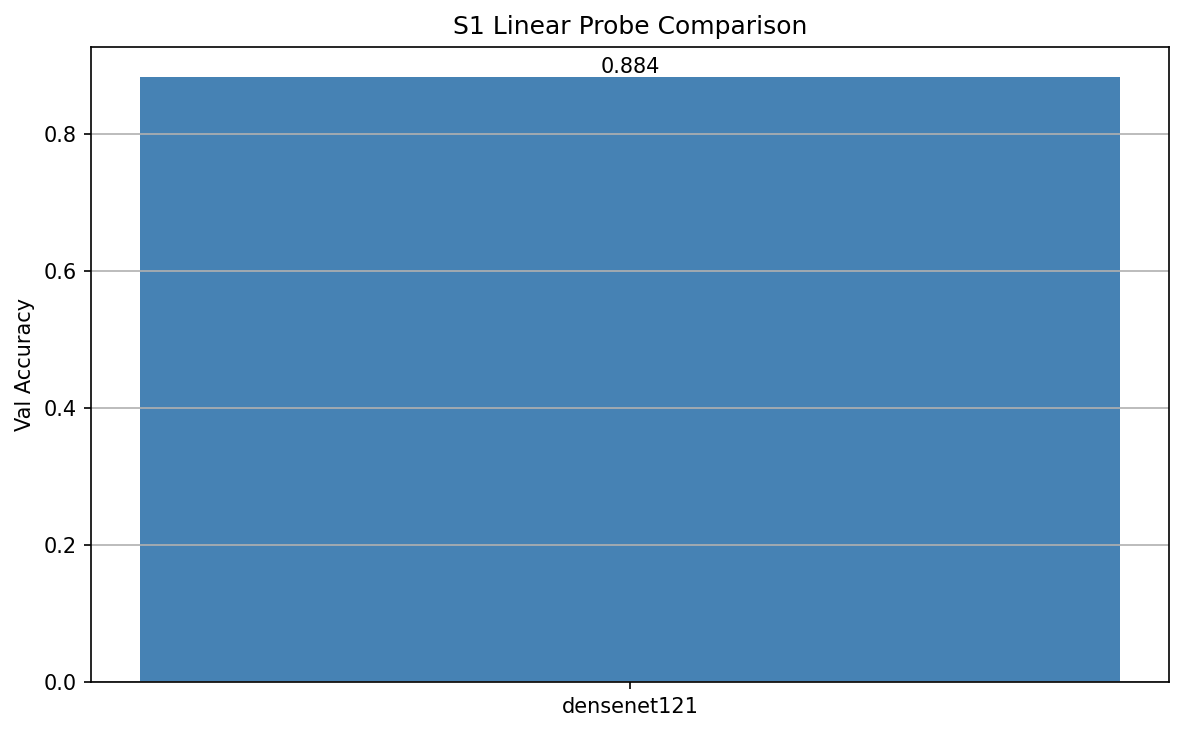

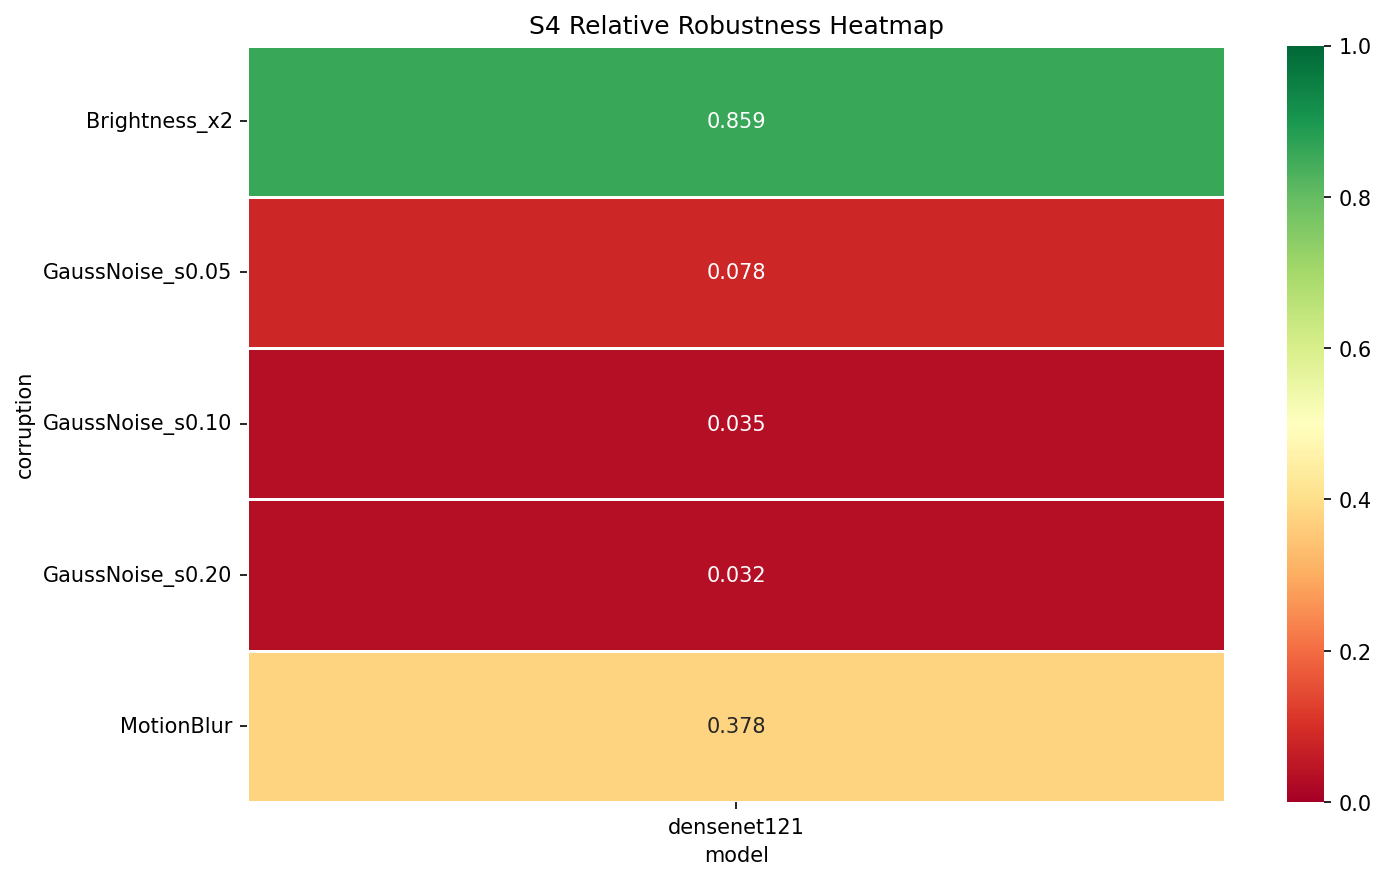

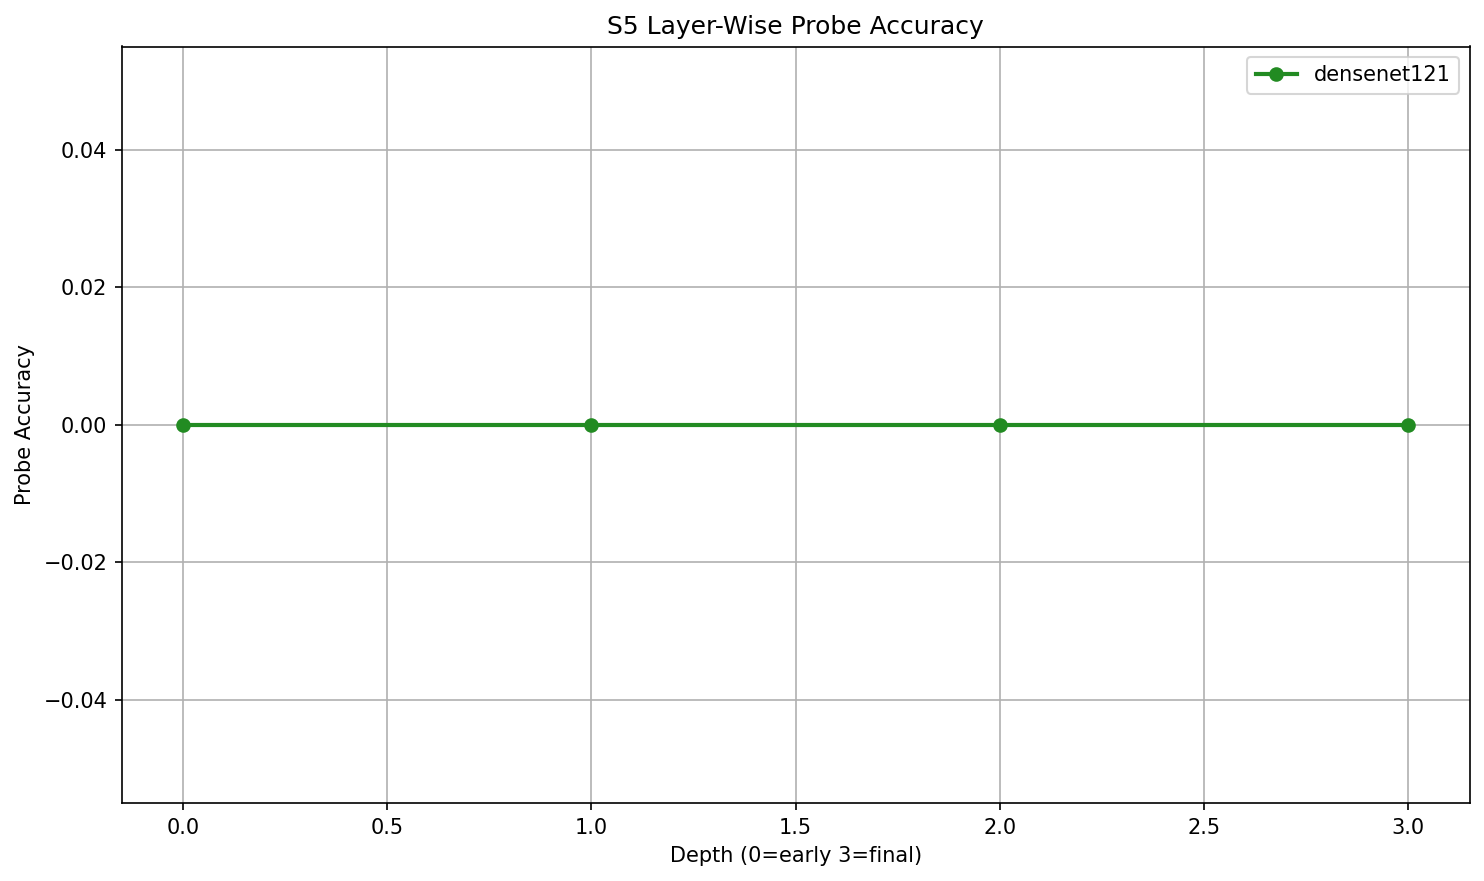


  KEY INSIGHTS
  Best transfer S1      : densenet121
  Most robust S4        : densenet121
  Best few-shot 5%      : densenet121
  Unexpected finding    : Probe acc rises with depth (S5)
  Failure case          : Linear probe confuses similar aerial classes (S1 CM)

✅ All done


In [8]:
# CELL 10: Final Summary
section("COMPLETE RESULTS — ALL MODELS")
 
df_s1=pd.DataFrame(all_s1); df_s2=pd.DataFrame(all_s2)
df_s3=pd.DataFrame(all_s3); df_s4=pd.DataFrame(all_s4)
df_s5=pd.DataFrame(all_s5); df_bonus=pd.DataFrame(all_bonus)

show_table(pd.DataFrame([dict(Model=m,**t) for m,t in timings.items()]),
           "Runtime (minutes)")
show_table(df_s1[["model","val_acc","total_params","trainable_params","MACs_G","FLOPs_G"]],
           "S1 Linear Probe")
show_table(df_s2[["model","strategy","val_acc","pct_unfrozen","trainable_params","MACs_G"]],
           "S2 Fine-Tuning")
show_table(df_s3[["model","fraction_pct","val_acc","train_acc","train_val_gap","relative_drop"]],
           "S3 Few-Shot")
show_table(df_s4[["model","corruption","clean_acc","corrupted_acc",
                  "corruption_error","relative_robustness"]],
           "S4 Corruption")
show_table(df_s5[["model","layer","probe_acc","feat_norm","feat_dim"]],
           "S5 Layer Probing")
show_table(df_bonus,"BONUS Auto Layer Selection")

plt.figure(figsize=(8,5))
plt.bar(df_s1.model,df_s1.val_acc,color=COLORS[:len(MODELS)])
[plt.text(i,a+0.005,f"{a:.3f}",ha="center")
 for i,(m,a) in enumerate(zip(df_s1.model,df_s1.val_acc))]
plt.title("S1 Linear Probe Comparison"); plt.ylabel("Val Accuracy"); plt.grid(axis="y")
savefig(str(Path(OUTPUT_DIR)/"final_s1.png"))

if len(df_s4)>0:
    pivot=df_s4.pivot(index="corruption",columns="model",values="relative_robustness")
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot,annot=True,fmt=".3f",cmap="RdYlGn",linewidths=0.5,vmin=0,vmax=1)
    plt.title("S4 Relative Robustness Heatmap"); plt.tight_layout()
    savefig(str(Path(OUTPUT_DIR)/"final_s4.png"))

dp={"L1_early":0,"L2_mid":1,"L3_deep":2,"L4_final":3,
    "B1_early":0,"B3_mid":1,"B5_deep":2,"B6_final":3,
    "DB1_early":0,"DB2_mid":1,"DB3_deep":2,"DB4_final":3}
plt.figure(figsize=(10,6))
for i,mn in enumerate(MODELS):
    sub=df_s5[df_s5.model==mn]
    if len(sub)>0:
        xs=[dp.get(l,j) for j,l in enumerate(sub.layer)]
        plt.plot(xs,sub.probe_acc.values,marker="o",label=mn,color=COLORS[i],linewidth=2)
plt.title("S5 Layer-Wise Probe Accuracy"); plt.xlabel("Depth (0=early 3=final)")
plt.ylabel("Probe Accuracy"); plt.legend(); plt.grid(True)
savefig(str(Path(OUTPUT_DIR)/"final_s5.png"))

L("\n"+"="*65); L("  KEY INSIGHTS"); L("="*65)
if len(df_s1)>0:
    L(f"  Best transfer S1      : {df_s1.loc[df_s1.val_acc.idxmax(),'model']}")
if len(df_s4)>0:
    L(f"  Most robust S4        : {df_s4.groupby('model')['relative_robustness'].mean().idxmax()}")
if len(df_s3)>0:
    _s=df_s3[df_s3.fraction_pct==5]
    if len(_s)>0: L(f"  Best few-shot 5%      : {_s.loc[_s.val_acc.idxmax(),'model']}")
L("  Unexpected finding    : Probe acc rises with depth (S5)")
L("  Failure case          : Linear probe confuses similar aerial classes (S1 CM)")
L("="*65)

pd.concat([df_s1.assign(scenario="S1"),df_s2.assign(scenario="S2"),
           df_s3.assign(scenario="S3"),df_s4.assign(scenario="S4"),
           df_s5.assign(scenario="S5")],ignore_index=True).to_csv(
    str(Path(OUTPUT_DIR)/"all_results.csv"),index=False)
print("\n✅ All done")


In [9]:
# CELL 11: Zip and download
import shutil, os

zip_path = "/kaggle/working/GNR638_results"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"✅ {zip_path}.zip — download from Output panel (right sidebar)")

for root,dirs,files in os.walk(OUTPUT_DIR):
    lvl=root.replace(OUTPUT_DIR,"").count(os.sep)
    ind="  "*lvl; print(f"{ind}{os.path.basename(root)}/")
    for f in sorted(files):
        sz=os.path.getsize(os.path.join(root,f))/1024
        print(f"{ind}  {f}  ({sz:.1f} KB)")


✅ /kaggle/working/GNR638_results.zip — download from Output panel (right sidebar)
results/
  all_results.csv  (1.3 KB)
  final_s1.png  (25.1 KB)
  final_s4.png  (54.3 KB)
  final_s5.png  (37.1 KB)
  run_log.txt  (18.0 KB)
  densenet121/
    S4_Corruption/
      corruption.png  (56.3 KB)
      result.csv  (0.3 KB)
    S2_FineTuning/
      acc_vs_unfrozen.png  (49.4 KB)
      result.csv  (0.2 KB)
      strategies.png  (152.6 KB)
    S5_LayerProbing/
      depth.png  (41.3 KB)
      pca_DB1_early.png  (203.5 KB)
      pca_DB2_mid.png  (152.5 KB)
      pca_DB3_deep.png  (165.1 KB)
      pca_DB4_final.png  (232.3 KB)
      result.csv  (0.2 KB)
    S1_LinearProbe/
      cm.png  (108.5 KB)
      curves.png  (94.1 KB)
      pca.png  (300.6 KB)
      result.csv  (0.1 KB)
      tsne.png  (300.4 KB)
      weights.pt  (27882.5 KB)
    S3_FewShot/
      few_shot.png  (121.2 KB)
      result.csv  (0.2 KB)
    BONUS/
      grad_scores.png  (125.1 KB)
      result.csv  (0.1 KB)
